In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np, os
import matplotlib.pyplot as plt

from pathlib import Path
import yaml
import re

import pyarrow as pa
import pyarrow.parquet as pq

import gbd_mapping as gm
from vivarium import Artifact

# from db_queries import get_ids, get_outputs, get_population, get_covariate_estimates
# from get_draws.api import get_draws

import vivarium_helpers as vh
# import vivarium_helpers.id_helper as idh
from vivarium_helpers.vph_output.operations import VPHOperator
from vivarium_helpers.vph_output import cleaning

!date
!whoami
!uname -a
!pwd

Thu Feb 19 16:26:04 PST 2026
ndbs
/mnt/share/code/ndbs/vivarium_research_alzheimers/verification_and_validation


Linux long-slurm-sarchive-p0061 5.4.0-216-generic #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux


# Record versions of Vivarium libraries

In [3]:
!pip list | grep vivarium

vivarium                                 3.4.12
vivarium_build_utils                     2.0.4
vivarium_cluster_tools                   2.1.17
vivarium_csu_alzheimers                  0.1.dev18+g43e997c.d20250808 /mnt/share/code/ndbs/vivarium_csu_alzheimers
vivarium_dependencies                    1.0.1
vivarium_gbd_access                      4.2.4
vivarium_helpers                         0.2.0                        /mnt/share/code/ndbs/vivarium_helpers/src
vivarium_inputs                          6.0.4
vivarium_public_health                   4.3.5


In [4]:
!pip freeze | grep vivarium

vivarium==3.4.12
vivarium_build_utils==2.0.4
vivarium_cluster_tools==2.1.17
-e git+https://github.com/ihmeuw/vivarium_csu_alzheimers.git@263eb3d9b80b13735a7380bb892430eaba92603a#egg=vivarium_csu_alzheimers
vivarium_dependencies==1.0.1
vivarium_gbd_access==4.2.4
-e git+https://github.com/ihmeuw/vivarium_helpers.git@28099970c4ff3efbb9ecfb68d9ffa33a6108cc82#egg=vivarium_helpers
vivarium_inputs==6.0.4
vivarium_public_health==4.3.5


# V&V List


1. Positive BBBM tests result in treatment initiation rates that match
    the year/location specific rates from in the [treatment intervention
    data table](https://vivarium-research.readthedocs.io/en/latest/models/intervention_models/alzheimers/hypothetical_treatment.html#alzheimers-intervention-treatment-data-table)

1. 10% of transitions to Full treatment effect status are by simulants who discontinue treatment

1. Full/Waning durations are accurate (use person-time ratios between states?)

1. “In treatment/waiting for treatment” duration is accurate (use person-time ratios between states?)

1.  Interactive sim verification spot checking a simulant’s durations in
    treatment statuses as they move through BBBM test negative, Full
    treatment effect, Waning treatment effect, No treatment effect
    statuses (for both completed and discontinued treatments)

1.  Check hazard ratios for simulants who begin treatment and those who
    transition to *No treatment effect* (Check hazard ratio of treated to
    not treated for hazard rate from BBBM to MCI)

Time- and location-specific treatment initiation rate from treatment
intervention data table:

> Lilly: “The percent of patients with a positive BBBM test who initiate treatment will vary by location and over time – but will not vary by age or sex. In the US: 30% of eligible patients initiate (constant 2030-2100); Japan: 80% of eligible patients initiate (constant 2030-2100); all other countries: 40% of eligible patients initiate in 2030, increasing linearly to 70% by 2035, remaining constant at 70% until 2100.””

# Find data

```
/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.1/model_spec/2026_02_04_10_16_58/
```

Artifact:

```
/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0
```

In [5]:
# Project directory on the cluster
project_dir = '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/'

if os.sys.platform == 'darwin':
    # Notebook is running on Nathaniel's MacBook
    local_project_dir = "/Users/ndbs/project_data/vivarium_csu_alzheimers/"
else:
    # Assume we're running on the cluster
    local_project_dir = project_dir

In [6]:
# Project directory
%cd $local_project_dir

/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers


In [7]:
# Results directory containing model 11.1 results for two locations
model_run_subdir = 'results/model12.1/model_spec/2026_02_04_10_16_58/'
!ls -halt $model_run_subdir/results

total 64K
drwxrwsr-x  5 albrja IHME-Simulationscience 4.5K Feb  5 09:57 ..
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:57 counts_newly_eligible_for_bbbm_testing
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:56 person_time_treatment
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:56 ylds
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:56 transition_count_treatment
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:55 counts_baseline_tests_among_eligible
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:55 deaths
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:55 transition_count_alzheimers_disease_and_other_dementias
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:54 person_time_ever_eligible_for_bbbm_testing
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:53 counts_new_simulants
drwxrwsr-x  2 albrja IHME-Simulationscience  512 Feb  5 09:53 person_time_alzheimers_disease_and_other_dementi

In [8]:
!ls $model_run_subdir

__pycache__		   keyspace.yaml	     requirements.txt
branches.yaml		   logs			     results
finished_sim_metadata.csv  model_specification.yaml  settings.py


In [9]:
!cat $model_run_subdir/model_specification.yaml | grep -e artifact -e results

      controller: vivarium.framework.artifact.ArtifactManager
      builder_interface: vivarium.framework.artifact.ArtifactInterface
    results:
      controller: vivarium.framework.results.ResultsManager
      builder_interface: vivarium.framework.results.ResultsInterface
    results:
      - bbbm_test_results
    results_directory: /mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.1/model_spec/2026_02_04_10_16_58


In [10]:
locations = [
    'United States of America',
    'Brazil',
    'China',
    # 'Germany',
    # 'Israel',
    # 'Japan',
    # 'Spain',
    # 'Sweden',
    # 'Taiwan (Province of China)',
    # 'United Kingdom',
]

# Define some shorter names to use for plotting
location_to_short_name = ({loc: loc for loc in locations} | {
    'Taiwan (Province of China)': 'Taiwan',
    'United Kingdom': 'UK',
    'United States of America': 'USA',
})

# # Select a subset of locations to draw plots for
# locations_to_plot = locations[:2]

# project_dir = '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/'

artifact_model_number = '10.0' # Artifacts are stored here
run_subdirectories = [
    model_run_subdir,
]
# Where results are stored locally
run_dirs = [local_project_dir + run_subdir for run_subdir in run_subdirectories]
results_dirs = [run_dir + 'results/' for run_dir in run_dirs]

# # Option 1: One results directory per location
# location_to_results_dir = {
#     loc: path for loc, path in zip(locations, results_dirs)}

# Option 2: All locations in one results directory
location_to_results_dir = {'all': results_dirs[0]}

location_to_artifact_subdir = {loc: loc.lower().replace(' ', '_') for loc in locations}
artifact_subpaths = [f'artifacts/model{artifact_model_number}/' + subdir + '.hdf' for subdir in location_to_artifact_subdir.values()]
# Map locations to where artifacts are stored locally (for reading artifact data)
location_to_local_artifact_path = {
    loc: local_project_dir + subpath for loc, subpath in zip(locations, artifact_subpaths)}
# Map locations to where artifacts are stored on the cluster (for adding locations to sim results)
location_to_artifact_path = {loc: project_dir + subpath for loc, subpath in zip(locations, artifact_subpaths)}
location_to_artifact_path

{'United States of America': '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf',
 'Brazil': '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf',
 'China': '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'}

In [11]:
location_to_results_dir

{'all': '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.1/model_spec/2026_02_04_10_16_58/results/'}

# Define some ordered Categorical dtypes, and convert years to ints

In [12]:
# # Instead of creating this dtype here, create an appropriate dtype in
# # the load_sim_output function.
# # Order locations lexicographically
# all_locations = [
#     'United States of America',
#     'Brazil',
#     'China',
#     'Germany',
#     'Israel',
#     'Japan',
#     'Spain',
#     'Sweden',
#     'Taiwan (Province of China)',
#     'United Kingdom',
# ]
# location_dtype = pd.CategoricalDtype(sorted(all_locations), ordered=True)

# Order years chronologically (for some reason years are strings in the output)
# years = [str(year) for year in range(2025, 2101)]
# year_dtype = pd.CategoricalDtype(years, ordered=True)
# int16 ranges from -32768 to 32767 (I think), which is sufficient to
# represent all years 2025-2100. uint8 only goes from 0 to 255, which is
# too small.
year_dtype = 'int16'

# Order age groups chronologically
age_groups = [f'{age}_to_{age + 4}' for age in range(25, 95, 5)] + ['95_plus']
age_group_dtype = pd.CategoricalDtype(age_groups, ordered=True)

# Order scenarios by complexity
scenarios = ['baseline', 'bbbm_testing', 'bbbm_testing_and_treatment']
scenario_dtype = pd.CategoricalDtype(scenarios, ordered=True)

colname_to_dtype = {
    # 'location': location_dtype,
    'event_year': year_dtype,
    'age_group': age_group_dtype,
    'scenario': scenario_dtype,
}

# Load one artifact and define age bins

In [13]:
artifact_path = location_to_local_artifact_path[locations[0]]
art = Artifact(artifact_path)
print(art.load('metadata.locations'))
print(art)

['United States of America']
Artifact containing the following keys:
metadata
	keyspace
	locations
population
	location
	structure
	age_bins
	demographic_dimensions
	theoretical_minimum_risk_life_expectancy
	scaling_factor
cause
	all_causes
		cause_specific_mortality_rate
	alzheimers
		prevalence
		bbbm_conditional_prevalence
		mci_conditional_prevalence
		mci_to_dementia_transition_rate
		susceptible_to_bbbm_transition_count
		population_incidence_rate
		excess_mortality_rate
		mci_disability_weight
	alzheimers_disease_and_other_dementias
		disability_weight
		restrictions
		cause_specific_mortality_rate
	alzheimers_consistent
		population_incidence_any
		prevalence_any
		population_incidence_dementia
		excess_mortality_rate
		bbbm_conditional_prevalence
		mci_conditional_prevalence
		ode_errors
		susceptible_to_bbbm_transition_count
		dementia_conditional_prevalence
covariate
	live_births_by_sex
		estimate
testing_rates
	csf
	pet
treatment
	relative_risk



In [14]:
# age_bins is an empty DataFrame with a MultiIndex storing age group data
age_bins = art.load('population.age_bins')
age_dictionary = (
    age_bins
    .reset_index()
    .assign(age_group=lambda df: df['age_group_name'].str.replace(' ', '_'))
    # Filter to ages that actually appear in our sim
    .query("age_start >= 25")
)
age_dictionary

,age_group_id,age_group_name,age_start,age_end,age_group
4,10,25 to 29,25.0,30.0,25_to_29
5,11,30 to 34,30.0,35.0,30_to_34
6,12,35 to 39,35.0,40.0,35_to_39
7,13,40 to 44,40.0,45.0,40_to_44
8,14,45 to 49,45.0,50.0,45_to_49
9,15,50 to 54,50.0,55.0,50_to_54
10,16,55 to 59,55.0,60.0,55_to_59
11,17,60 to 64,60.0,65.0,60_to_64
12,18,65 to 69,65.0,70.0,65_to_69
13,19,70 to 74,70.0,75.0,70_to_74


# See what the treatment relative risk looks like

Draws should be uniformly distributed in $[0.4, 0.6]$.

In [15]:
treatment_rr = art.load('treatment.relative_risk')
treatment_rr

,draw_0,draw_1,draw_2,draw_3,draw_4,draw_5,draw_6,draw_7,draw_8,draw_9,...,draw_490,draw_491,draw_492,draw_493,draw_494,draw_495,draw_496,draw_497,draw_498,draw_499
0,0.527516,0.495529,0.464333,0.576056,0.478925,0.458396,0.541982,0.520483,0.53923,0.514836,...,0.485136,0.498684,0.503797,0.432717,0.462276,0.481699,0.569136,0.502568,0.4362,0.512734


# Define functions to load and merge Artifact data from all locations, and to summarize Artifact data for plotting

In [16]:
def load_artifact_data(
    key,
    filter_terms=None,
    location_to_artifact_path=location_to_artifact_path,
):
    dfs = {} # dict to map locations to artifact data
    for location, path in location_to_artifact_path.items():
        art = Artifact(path, filter_terms)
        # Check to make sure location matches artifact
        art_locations = art.load('metadata.locations')
        assert len(art_locations) == 1 and art_locations[0] == location, \
            f'Unexpected locations in artifact: {location=}, {art_locations=}'
        df = art.load(key)
        dfs[location] = df
    data = pd.concat(dfs, names=['location', *df.index.names])
    return data

def lower(x):
    return x.quantile(0.025)

def upper(x):
    return x.quantile(0.975)

def summarize_artifact_data(df):
    summary = df.agg(['mean', lower, upper], axis='columns')
    return summary

# Define functions to load simulation output and summarize it for plotting

With the `pyarrow` engine, `pandas.read_parquet()` calls `pyarrow.parquet.read_table()` and
`pyarrow.Table.to_pandas()`. Additional keyword arguments passed to
`pandas.read_parquet()` are passed to `pyarrow.parquet.read_table()`.

https://arrow.apache.org/docs/python/generated/pyarrow.parquet.read_table.html#pyarrow.parquet.read_table

https://arrow.apache.org/docs/python/generated/pyarrow.Table.html#pyarrow.Table.to_pandas

Pyarrow Dictionary arrays are analogous to pandas Categoricals:

https://arrow.apache.org/docs/python/data.html#data-dictionary

Pyarrow data types:

https://arrow.apache.org/docs/python/api/datatypes.html

https://arrow.apache.org/docs/python/generated/pyarrow.types.is_floating.html


Google AI results for "find column names in parquet file":

```python
import pyarrow.parquet as pq

# Replace 'your_file.parquet' with the actual path to your Parquet file
parquet_file_path = 'your_file.parquet'

# Read the Parquet file's schema
parquet_schema = pq.read_schema(parquet_file_path)

# Extract column names
column_names = parquet_schema.names

print(f"Column names in '{parquet_file_path}':")
for name in column_names:
    print(name)
```

In [17]:
# Create an operator object - treat each random seed as a separate draw,
# and add location to the index
ops = VPHOperator(location_col=True)
# ops.index_cols.extend(['location', 'random_seed'])

def load_sim_output(
        measure,
        results_dict=location_to_results_dir,
        # Pass None to skip filtering locations (when None, must also
        # pass assign_location=False or raw=True)
        location_to_artifact_path=location_to_artifact_path,
        # specify dtypes of certain columns
        colname_to_dtype=colname_to_dtype,
        drop_superfluous_cols=True, # drop redundant or empty columns
        # Sets the 'read_dictionary' key of kwargs, which is passed to
        # pyarrow.parquet.read_table()
        force_parquet_dictionaries=True,
        force_pandas_categoricals=True,
        aggregate_seeds=True,
        assign_location=True,
        raw=False, # Overrides other parameters if True
        **kwargs, # keyword args to pass to .read_parquet
    ):
    """Load simulation output from .parquet files for all locations,
    optionally reducing the size of the data when possible. Returns
    concatenated outputs with a 'location' column added.
    """
    # Override optional transformations if raw=True
    if raw:
        drop_superfluous_cols = False
        force_parquet_dictionaries = False
        force_pandas_categoricals = False
        aggregate_seeds = False
        assign_location = False

    # Determine whether results for all locations are stored in same
    # directory, or if different locations have different results
    # directories
    match location_to_results_dir:
        case {'all': _}:
            all_locations_together = True
        case _:
            all_locations_together = False
    
    if all_locations_together and assign_location and location_to_artifact_path is None:
        raise ValueError(
            "Must provide mapping of artifacts to locations  when" \
            " assign_location=True and all locations are concatenated" \
            " in the simulation outputs."
        )

    dfs = []
    for location, directory in results_dict.items():

        # NOTE: New Vivarium version stores each measure in a folder
        # instead of a single .parquet file
        parquet_file_path = Path(directory) / measure #f'{measure}.parquet'
        # The ParquetDataset object has a .schema attribute we can use
        # to get its column names and data types 
        parquet_dataset = pa.parquet.ParquetDataset(parquet_file_path)
        # # NOTE: This code no longer works with datasets stored in
        # # directories instead of single parquet files:
        # # Read the Parquet file's schema to get column names and data types
        # parquet_schema = pq.read_schema(parquet_file_path)

        if (
            all_locations_together
            and location_to_artifact_path is not None
        ):
            if 'artifact_path' in parquet_dataset.schema.names:
                # Filter to locations in list
                location_filter = (
                    'artifact_path',
                    'in',
                    list(location_to_artifact_path.values()),
                )
                user_filters = kwargs.get('filters') # Defaults to None
                kwargs['filters'] = add_parquet_AND_filter(
                    location_filter, user_filters)
                # TODO: Use logging not printing
                print(location_filter)
            else:
                print("'artifact_path' column missing from parquet file."
                      " Not filtering locations.")

        if force_parquet_dictionaries:
            # Read all columns as dictionaries except those containing 
            # floating point values
            kwargs['read_dictionary'] = [
                col.name for col in parquet_dataset.schema
                if not pa.types.is_floating(col.type)]

        # Read the parquet file
        df = pd.read_parquet(parquet_file_path, **kwargs)
        # df = parquet_dataset.read(**kwargs).to_pandas()

        if drop_superfluous_cols:
            # Drop redundant columns
            for col1, col2 in [
                ('input_draw', 'input_draw_number'),
                ('entity', 'sub_entity'),
            ]:
                if (col1 in df and col2 in df and df[col1].equals(df[col2])):
                    df.drop(columns=col2, inplace=True)
            # Drop empty columns (e.g., sub-entity)
            for col in df:
                if df[col].isna().all():
                    df.drop(columns=col, inplace=True)
        if colname_to_dtype is not None:
            # NOTE: If copy-on-write is enabled, copy keyword is ignored
            df = df.astype(
                # Must filter to avoid KeyError
                {c: dtype for c, dtype in colname_to_dtype.items() if c in df},
                copy=False
            )
        if force_pandas_categoricals:
            convert_to_categorical(
                df, exclude_cols=colname_to_dtype or (), inplace=True)
        if aggregate_seeds:
            # Use default index and value columns when aggregating
            df = vh.vph_output.operations.marginalize(df, 'random_seed')
        if assign_location:
            if all_locations_together:
                # NOTE: location_to_artifact_path is guaranteed not to
                # be None because assign_location and
                # all_locations_together are both True

                # Create a Categorical dtype with all locations
                location_dtype = pd.CategoricalDtype(
                    sorted(location_to_artifact_path.keys()), ordered=True)
                # Invert the dictionary so we can map artifact paths to
                # locations
                artifact_path_to_location = {
                    path: loc for loc, path
                    in location_to_artifact_path.items()}
                if 'artifact_path' in df:
                    df['location'] = df['artifact_path'].map(
                        artifact_path_to_location).astype(location_dtype)
                else:
                    # In case the engineers change the DataFrame format
                    # on us...
                    print("'artifact_path' column missing from DataFrame."
                          " Not assigning locations.")
            else:
                # NOTE: location_to_results_dir contains actual
                # locations as keys (not 'all') since
                # all_locations_together is False

                # Create a Categorical dtype with all locations to avoid
                # converting back to object dtype.
                location_dtype = pd.CategoricalDtype(
                    sorted(location_to_results_dir.keys()), ordered=True)
                df['location'] = location
                df['location'] = df['location'].astype(location_dtype)
        dfs.append(df)
    # TODO: Maybe if assign_location is False and all_locations_together
    # is also False (and there is more than one location?), we should
    # return a dict mapping locations to dataframes (or just a list of
    # dataframes?) instead of concatenating, since it won't be possible
    # to filter the resulting concatenated dataframe by location...
    df = pd.concat(dfs)
    return df

# # NOTE: This function is unnecessary because it does the same thing as
# # DataFrame.astype
# def convert_dtypes(df, colname_to_dtype, inplace=False):
#     if not inplace:
#         df = df.copy()
#     for colname, dtype in colname_to_dtype.items():
#         if colname in df:
#             df[colname] = df[colname].astype(dtype)

#     if not inplace:
#         return df
#     else:
#         return None

def convert_to_categorical(
        df,
        include_cols=(),
        exclude_cols=(),
        exclude_dtypes=(pd.api.types.is_numeric_dtype,
                        # TODO: For some reason,
                        # pd.api.types.is_categorical_dtype is deprecated, and
                        # they recommend using isinstance instead. So I don't
                        # know if there's a simpler way to make checking for a
                        # categorical dtype more parallel with checking for a
                        # numeric dtype.
                        lambda dtype: isinstance(dtype, pd.CategoricalDtype)),
        inplace=False
    ):
    """Convert all columns except numerical columns to categorical. This
    saves lots of memory, allowing us to load and manipulate larger
    DataFrames.
    """
    if  len(set(include_cols).intersection(exclude_cols)) != 0:
        raise ValueError("A column can't be both included and excluded!")
    if not inplace:
        df = df.copy()
    for col in df:
        if (
            col in include_cols
            or (col not in exclude_cols
                and not any(excluded_dtype(df[col].dtype)
                            for excluded_dtype in exclude_dtypes))
                # and df[col].dtype not in exclude_dtypes)
        ):
            df[col] = df[col].astype('category')
    if not inplace:
        return df
    else:
        return None
    
def add_parquet_AND_filter(new_filter, existing_filters):
    match existing_filters:
        case None:
            # No existing filters -- create a single AND group
            filters = [new_filter]
        case list([tuple((_, _, _)), *_]):
            # Existing filters consist of one AND group -- add the new filter
            filters = [new_filter, *existing_filters]
        case list([list([tuple((_, _, _)), *_]), *_]):
            # Add the filter to each AND group in the outer OR group
            filters = [[new_filter, *and_group] for and_group in existing_filters]
        case _:
            raise ValueError(f"Malformed parquet filter: {existing_filters}")
    # # Alternate version using isinstance()
    # if existing_filters is None:
    #     # No existing filters -- create a single AND group
    #     filters = [new_filter]
    # elif isinstance(existing_filters[0], tuple):
    #     # Existing filters consist of one AND group -- add the new filter
    #     filters = [new_filter, *existing_filters]
    # elif isinstance(existing_filters[0], list):
    #     # Add the filter to each AND group in the outer OR group
    #     filters = [[new_filter, *and_group] for and_group in existing_filters]
    # else:
    #     raise ValueError(f"Malformed parquet filter: {existing_filters}")
    return filters

# NOTE: Need to create ops before defining this function
def summarize_sim_data(df, age_dictionary=age_dictionary):
    """Summarize simulation data for plotting."""
    # Merge to get an age_start column for plotting
    if 'age_group' in df:
        df = df.merge(age_dictionary, on='age_group')
    # Summarize, and rename percentiles to match artifact
    summary = ops.describe(df).rename(
        columns={'2.5%': 'lower', '97.5%': 'upper'})
    return summary

def print_memory_usage(df):
    print(df.memory_usage(deep=True).sum() / 1e6, 'MB')


# Filter seeds by monkey-patching the above data loading function

In [18]:
# # Model 10.0 was run with 100 seeds instead of 5, so let's just filter
# # everything to 5 seeds to make it all run faster
# # seeds = [338, 6520, 3585, 7745, 539]
# seeds = [7179, 2599, 1534, 386, 1935]
# seed_filter = ('random_seed', 'in', seeds)

# def add_filter(load_func, new_filter):
#     """Return load_func, but with `new_filter` added to its list of
#     parquet filters in the 'filters' key of kwargs.
#     """
#     def new_load_func(*args, **kwargs):
#         user_filters = kwargs.get('filters') # Defaults to None
#         kwargs['filters'] = add_parquet_AND_filter(
#             new_filter, user_filters)
#         return load_func(*args, **kwargs)
#     return new_load_func

# # Monkey-patch!
# load_sim_output = add_filter(load_sim_output, seed_filter)

# Test code for loading sim output

In [19]:
dataset_path = Path(location_to_results_dir['all']) / 'counts_new_simulants'
dataset_path

PosixPath('/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.1/model_spec/2026_02_04_10_16_58/results/counts_new_simulants')

In [20]:
!ls $dataset_path

0000.parquet


In [21]:
dataset = pa.parquet.ParquetDataset(dataset_path)
dataset.schema

age_group: dictionary<values=string, indices=int8, ordered=0>
event_year: dictionary<values=string, indices=int8, ordered=0>
sex: dictionary<values=string, indices=int8, ordered=0>
artifact_path: string
scenario: string
input_draw: int64
random_seed: int64
value: double
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1311

In [22]:
new_sims = load_sim_output(
    'counts_new_simulants',
    # colname_to_dtype=None,
    raw=True,
    engine='pyarrow',
    # read_dictionary=['input_draw', 'scenario'],
    # filters=[('event_year', '==', '2025')],
    # assign_location=False,
    # aggregate_seeds=False,
)
new_sims

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])


,age_group,event_year,sex,artifact_path,scenario,input_draw,random_seed,value
0,25_to_29,2022,Female,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2284,0.0
1,25_to_29,2022,Male,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2284,0.0
2,25_to_29,2023,Female,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2284,0.0
3,25_to_29,2023,Male,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2284,0.0
4,25_to_29,2024,Female,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2284,0.0
...,...,...,...,...,...,...,...,...
2666245,95_plus,2098,Male,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2787,0.0
2666246,95_plus,2099,Female,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2787,0.0
2666247,95_plus,2099,Male,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2787,0.0
2666248,95_plus,2100,Female,/mnt/team/simulation_science/pub/models/vivari...,baseline,236,2787,0.0


In [23]:
new_sims.random_seed.nunique()

5

In [24]:
print(
    new_sims.artifact_path.unique(),
    new_sims.input_draw.unique(),
    # new_sims.random_seed.nunique(),
    new_sims.scenario.unique(),
    new_sims.event_year.unique(),
    sep='\n'
)
if 'location' in new_sims:
    print(new_sims.location.unique())

['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf'
 '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'
 '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf']
[236 161  41   1 187 199  69 219  63 103 249 183   6  35 123 122 248 245
 204 172 211  24  50   7 235]
['baseline', 'bbbm_testing_and_treatment', 'bbbm_testing']
Categories (3, object): ['baseline' < 'bbbm_testing' < 'bbbm_testing_and_treatment']
[2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035
 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049
 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059 2060 2061 2062 2063
 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077
 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2091
 2092 2093 2094 2095 2096 2097 2098 2099 2100]


In [25]:
new_sims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666250 entries, 0 to 2666249
Data columns (total 8 columns):
 #   Column         Dtype   
---  ------         -----   
 0   age_group      category
 1   event_year     int16   
 2   sex            category
 3   artifact_path  object  
 4   scenario       category
 5   input_draw     int64   
 6   random_seed    int64   
 7   value          float64 
dtypes: category(3), float64(1), int16(1), int64(2), object(1)
memory usage: 94.1+ MB


In [26]:
new_sims['scenario'].unique()

['baseline', 'bbbm_testing_and_treatment', 'bbbm_testing']
Categories (3, object): ['baseline' < 'bbbm_testing' < 'bbbm_testing_and_treatment']

In [27]:
new_sims['input_draw'].dtype

dtype('int64')

In [28]:
print(new_sims.input_draw.dtype == 'int') # int64 counts as int
print(new_sims.event_year.dtype == 'int') # int16 does NOT count as int
pd.api.types.is_numeric_dtype(new_sims.event_year)

True
False


True

# Define plotting functions

In [29]:
def plot_over_time_by_column(
        df,
        colname,
        ylabel='',
        title='',
        uncertainty=True,
        ax=None,
        plot_func='plot',
        **kwargs, # Keyword args to pass to plotting function
    ):
    """Plot mean value vs. year for each value in the column `colname`,
    optionally with (lower, upper) uncertainty band.
    """
    if ax is None:
        ax = plt.gca()
#     df = cs.age_to_ordered_categorical(df) # Order the age groups chronologically
    # df = csr.to_ordered_categoricals(df)
    
    # TODO: Add a warning if there are unexpected stratifications still present,
    # like scenario (e.g., warn if scenario column is present and contains more
    # than one value, because then we'll be aggregating over scenarios, which is
    # probably not what we want).

    # agg = df.groupby([colname, 'event_year'])['value'].describe(percentiles=[.025, .975])
    # agg = vh.vph_output.operations.stratify(df, [colname, 'event_year'], func=['mean', lower, upper])['value']
    agg = df.groupby([colname, 'event_year'], observed=True)['value'].agg(['mean', lower, upper])
    col_vals = agg.index.unique(colname)
    for col_val in col_vals:
        values = agg.xs(col_val)
        years = values.index
        ax_plotter = getattr(ax, plot_func)
        ax_plotter(years, values['mean'], label=f"{colname}={col_val}", **kwargs)
        if uncertainty:
            # ax.fill_between(years, values['2.5%'], values['97.5%'], alpha=.1)
            ax.fill_between(years, values['lower'], values['upper'], alpha=.1)

    ax.set_xlabel('year')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    return ax

def plot_over_time_by_column_for_row_x_1(
        df, colname, row_variable, ylabel='', suptitle='', uncertainty=True,
        axes_width=12, axes_height=6,
        plot_func='plot',
        **kwargs,
    ):
    """Draw a nx1 figure with rows indexed by location, calling plot_over_time_by_column()
    for each subplot.
    """
    # Get ordered list of locations in the dataframe
    # df = csr.to_ordered_categoricals(df)
    df = convert_to_categorical(df)
    row_values = df[row_variable].unique().sort_values()
    fig, _ = plt.subplots(
        len(row_values), 1,
        figsize=(axes_width, 1 + axes_height * len(row_values)))
    for row_num, row_value in enumerate(row_values):
        plot_over_time_by_column(
            df.query(f"{row_variable}==@row_value"),
            colname,
            ylabel,
            f"{row_variable}={row_value}",
            uncertainty,
            ax=fig.axes[row_num],
            plot_func=plot_func,
            **kwargs,
        )
    fig.suptitle(suptitle, fontsize=18)
    fig.tight_layout()
    return fig

# Load treatment person-time data

In [30]:
# 62 MB in memory for one location
person_time_treatment = load_sim_output('person_time_treatment')
print(person_time_treatment.memory_usage(deep=True).sum() / 1e6, 'MB')
person_time_treatment

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
86.390767 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,susceptible_to_treatment,0.000000,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,waiting_for_treatment,0.000000,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,treatment_effect,0.000000,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,waning_effect,0.000000,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,no_effect_after_treatment,0.000000,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
3199495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,waiting_for_treatment,0.000000,Brazil
3199496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,treatment_effect,0.000000,Brazil
3199497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,waning_effect,39.863107,Brazil
3199498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,no_effect_after_treatment,447.463381,Brazil


In [31]:
person_time_treatment.event_year.unique()

array([2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032,
       2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043,
       2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
       2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065,
       2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076,
       2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087,
       2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098,
       2099, 2100], dtype=int16)

In [32]:
person_time_treatment.sub_entity.unique()

['susceptible_to_treatment', 'waiting_for_treatment', 'treatment_effect', 'waning_effect', 'no_effect_after_treatment', 'no_effect_never_treated']
Categories (6, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

In [33]:
person_time_treatment.query("sub_entity == 'waiting_for_treatment'")

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,waiting_for_treatment,0.0,United States of America
7,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Male,waiting_for_treatment,0.0,United States of America
13,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,bbbm_testing,Female,waiting_for_treatment,0.0,United States of America
19,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,bbbm_testing,Male,waiting_for_treatment,0.0,United States of America
25,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,bbbm_testing_and_treatment,Female,waiting_for_treatment,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
3199471,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,baseline,Male,waiting_for_treatment,0.0,Brazil
3199477,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing,Female,waiting_for_treatment,0.0,Brazil
3199483,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing,Male,waiting_for_treatment,0.0,Brazil
3199489,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Female,waiting_for_treatment,0.0,Brazil


In [34]:
person_time_treatment.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity       category
value             float64
location         category
dtype: object

# Load treatment transition counts

In [35]:
# 55 MB in memory for one location
transition_count_treatment = load_sim_output('transition_count_treatment')
print_memory_usage(transition_count_treatment)
transition_count_treatment

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
71.993059 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,transition_count,baseline,Female,waiting_for_treatment_to_treatment_effect,0.0,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,transition_count,baseline,Female,treatment_effect_to_waning_effect,0.0,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,transition_count,baseline,Female,waning_effect_to_no_effect_after_treatment,0.0,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,transition_count,baseline,Female,susceptible_to_treatment_to_waiting_for_treatment,0.0,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,transition_count,baseline,Female,susceptible_to_treatment_to_no_effect_never_tr...,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
2666245,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,waiting_for_treatment_to_treatment_effect,0.0,Brazil
2666246,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,treatment_effect_to_waning_effect,0.0,Brazil
2666247,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,25.0,Brazil
2666248,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_waiting_for_treatment,0.0,Brazil


In [36]:
transition_count_treatment.sub_entity.unique()

['waiting_for_treatment_to_treatment_effect', 'treatment_effect_to_waning_effect', 'waning_effect_to_no_effect_after_treatment', 'susceptible_to_treatment_to_waiting_for_treat..., 'susceptible_to_treatment_to_no_effect_never_t...]
Categories (5, object): ['susceptible_to_treatment_to_no_effect_never_t..., 'susceptible_to_treatment_to_waiting_for_treat..., 'treatment_effect_to_waning_effect', 'waiting_for_treatment_to_treatment_effect', 'waning_effect_to_no_effect_after_treatment']

In [37]:
non_treatment_transitions = transition_count_treatment.query("scenario != 'bbbm_testing_and_treatment' and value >0")
non_treatment_transitions

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
1425764,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,transition_count,bbbm_testing,Female,susceptible_to_treatment_to_no_effect_never_tr...,28.0,United States of America
1425769,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,transition_count,bbbm_testing,Male,susceptible_to_treatment_to_no_effect_never_tr...,12.0,United States of America
1425794,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,6,transition_count,bbbm_testing,Female,susceptible_to_treatment_to_no_effect_never_tr...,36.0,United States of America
1425799,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,6,transition_count,bbbm_testing,Male,susceptible_to_treatment_to_no_effect_never_tr...,11.0,United States of America
1425824,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,7,transition_count,bbbm_testing,Female,susceptible_to_treatment_to_no_effect_never_tr...,24.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
1955179,75_to_79,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,245,transition_count,bbbm_testing,Male,susceptible_to_treatment_to_no_effect_never_tr...,673.0,Brazil
1955204,75_to_79,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,248,transition_count,bbbm_testing,Female,susceptible_to_treatment_to_no_effect_never_tr...,1013.0,Brazil
1955209,75_to_79,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,248,transition_count,bbbm_testing,Male,susceptible_to_treatment_to_no_effect_never_tr...,455.0,Brazil
1955234,75_to_79,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,transition_count,bbbm_testing,Female,susceptible_to_treatment_to_no_effect_never_tr...,1153.0,Brazil


In [38]:
non_treatment_transitions.scenario.unique()

['bbbm_testing']
Categories (3, object): ['baseline' < 'bbbm_testing' < 'bbbm_testing_and_treatment']

In [39]:
list(non_treatment_transitions.sub_entity.unique())

['susceptible_to_treatment_to_no_effect_never_treated']

In [40]:
transition_count_treatment.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity       category
value             float64
location         category
dtype: object

In [41]:
df = (
    transition_count_treatment
    # There's no treatment in the first two scenarios
    .query("scenario == 'bbbm_testing_and_treatment'")
    .pipe(ops.marginalize, 'semester')
    .pipe(lambda df: df.join(
        cleaning.extract_transition_states(df, 'sub_entity'))
    )
    # .pipe(convert_to_categorical)
)
df .dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
location         category
measure          category
scenario         category
sex              category
sub_entity       category
value             float64
from_state         object
to_state           object
dtype: object

In [42]:
df.event_year.dtype == 'int16'

True

# Transform treatment transition counts into more useful form

In [43]:
treatment_transitions = (
    transition_count_treatment
    # There's no treatment in the first two scenarios
    .query("scenario == 'bbbm_testing_and_treatment'")
    .pipe(ops.marginalize, 'semester')
    .pipe(lambda df: df.join(
        cleaning.extract_transition_states(df, 'sub_entity'))
    )
    .pipe(convert_to_categorical)
)
print_memory_usage(treatment_transitions)
treatment_transitions

25.779088 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,location,measure,scenario,sex,sub_entity,value,from_state,to_state
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,waiting_for_treatment_to_treatment_effect,0.0,waiting_for_treatment,treatment_effect
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,treatment_effect_to_waning_effect,0.0,treatment_effect,waning_effect
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,waning_effect_to_no_effect_after_treatment,0.0,waning_effect,no_effect_after_treatment
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_waiting_for_treatment,0.0,susceptible_to_treatment,waiting_for_treatment
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_no_effect_never_tr...,0.0,susceptible_to_treatment,no_effect_never_treated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888745,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waiting_for_treatment_to_treatment_effect,0.0,waiting_for_treatment,treatment_effect
888746,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,treatment_effect_to_waning_effect,0.0,treatment_effect,waning_effect
888747,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,25.0,waning_effect,no_effect_after_treatment
888748,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_waiting_for_treatment,0.0,susceptible_to_treatment,waiting_for_treatment


In [44]:
treatment_transitions.to_state

0                  treatment_effect
1                     waning_effect
2         no_effect_after_treatment
3             waiting_for_treatment
4           no_effect_never_treated
                    ...            
888745             treatment_effect
888746                waning_effect
888747    no_effect_after_treatment
888748        waiting_for_treatment
888749      no_effect_never_treated
Name: to_state, Length: 888750, dtype: category
Categories (5, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

# Check #1 (treatment initiation rates, aka intervention coverage)

Positive BBBM tests result in treatment initiation rates that match
the year/location specific rates from in the [treatment intervention
data
table](https://vivarium-research.readthedocs.io/en/latest/models/intervention_models/alzheimers/hypothetical_treatment.html#alzheimers-intervention-treatment-data-table)

> We will use a piecewise linear ramp-up with knots at the following (year, level) values: (2022.0, 0), (2027.0, 0), (2035.5, 30), (2100.0, 80), (2101.0, 80).
>
> This captures the CSU client’s specification that
> “30% of eligible patients initiate by 2035, with a steady increase to 80% by 2100, for all countries,” and that treatment should first be available in 2027, slowly ramping up to 30% in 2035.

## Strategy

Consider all transitions out of the `'susceptible_to_treatment'` state.
Compute the percent of transitions that go to `'waiting_for_treatment'` vs.
`'no_effect_never_treated'`. The percent that go to `'waiting_for_treatment'`
should match the location-specific rates from Lilly for each year.

## Looks like treatment still starts in 2030, not 2027

But maybe the piecewise linear function is actually correct, and it's
just getting cut off for some reason?



In [45]:
treatment_transitions.to_state.unique()

['treatment_effect', 'waning_effect', 'no_effect_after_treatment', 'waiting_for_treatment', 'no_effect_never_treated']
Categories (5, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

In [46]:
testing_eligible_age_groups = age_groups[7:11]
testing_eligible_age_groups

['60_to_64', '65_to_69', '70_to_74', '75_to_79']

In [47]:
# Testing eligible ages are 60-80, and treatment always starts 6 months
# after testing, so treatment-eligible age groups are 60-64 through
# 80-84. Note that these are the ages when people should enter one of
# the 'full_effect' states, not the 'waiting_for_treatment' state
treatment_eligible_age_groups = age_groups[7:12]
treatment_eligible_age_groups

['60_to_64', '65_to_69', '70_to_74', '75_to_79', '80_to_84']

In [48]:
# Verify that no one outside the testing-eligible age groups starts
#  waiting for treatment
assert set(treatment_transitions.query( \
        "to_state == 'waiting_for_treatment'" \
        " and age_group not in @testing_eligible_age_groups" \
    ).value.unique()) == {0.0}, \
        "Nonzero waiting for treatment counts outside eligible age groups"

In [49]:
treatment_transitions.query( \
        "to_state == 'waiting_for_treatment' and value > 0" \
    ).age_group.unique()

['65_to_69', '70_to_74', '75_to_79']
Categories (15, object): ['25_to_29' < '30_to_34' < '35_to_39' < '40_to_44' ... '80_to_84' < '85_to_89' < '90_to_94' < '95_plus']

In [50]:
# Here's more stringent way to check the same thing, verifying also that
# there *are* transitions within each of the testing-eligible age groups
assert set(treatment_transitions.query( \
        "to_state == 'waiting_for_treatment' and value > 0" \
    ).age_group.unique()) \
        == {'65_to_69', '70_to_74', '75_to_79'}, \
            "Waiting for treatment occurring in wrong age groups"

In [51]:
treatment_transitions.query(
    "to_state == 'waiting_for_treatment' and value > 0"
).groupby('age_group', observed=True).describe()

event_year                                                          \
               count         mean        std     min     25%     50%     75%   
age_group                                                                      
65_to_69     10977.0  2063.903070  21.136054  2027.0  2046.0  2064.0  2082.0   
70_to_74     11012.0  2063.788231  21.200331  2027.0  2045.0  2064.0  2082.0   
75_to_79     11045.0  2063.680579  21.259834  2027.0  2045.0  2064.0  2082.0   

                  input_draw              ...                  value  \
              max      count        mean  ...    75%    max    count   
age_group                                 ...                          
65_to_69   2100.0    10977.0  135.572014  ...  211.0  249.0  10977.0   
70_to_74   2100.0    11012.0  135.799491  ...  211.0  249.0  11012.0   
75_to_79   2100.0    11045.0  135.722227  ...  211.0  249.0  11045.0   

                                                                     
                 mean         std  min    25%    50%    75%     max  
age_group                                                            
65_to_69   242.441651  192.467367  1.0   99.0  190.0  332.0   806.0  
70_to_74   296.700236  218.464630  1.0  130.0  254.0  428.0  1027.0  
75_to_79   348.028610  209.437528  1.0  205.0  337.0  480.0  1019.0  

[3 rows x 24 columns]

In [52]:
ops.index_cols

['input_draw', 'scenario', 'location']

In [53]:
# Check that treatment starts in 2027
(
    treatment_transitions
    .astype({'event_year': 'int'})
    .query("from_state == 'susceptible_to_treatment' and value > 0")
    .groupby('location', observed=True)
    .event_year
    .min()
)

location
Brazil                      2027
China                       2027
United States of America    2027
Name: event_year, dtype: int64

In [54]:
initiate_vs_not = ops.ratio(
    treatment_transitions,
    treatment_transitions,
    strata=['event_year'],
    prefilter_query=(
        "from_state == 'susceptible_to_treatment'"
        # Can't pass using @ syntax since the variable is out of scope
        # when .query gets called in the .ratio function
        # f" and age_group in {treatment_eligible_age_groups}"
    ),
    numerator_broadcast=["to_state"],
    # Drop years prior to 2030 where we divide by 0 treatment transition
    # counts
    # dropna=True,
)
initiate_vs_not

,event_year,input_draw,scenario,location,to_state,value,numerator_measure,denominator_measure,multiplier
0,2022,1,bbbm_testing_and_treatment,Brazil,waiting_for_treatment,NaN,transition_count,transition_count,1
1,2022,1,bbbm_testing_and_treatment,Brazil,no_effect_never_treated,NaN,transition_count,transition_count,1
2,2022,1,bbbm_testing_and_treatment,China,waiting_for_treatment,NaN,transition_count,transition_count,1
3,2022,1,bbbm_testing_and_treatment,China,no_effect_never_treated,NaN,transition_count,transition_count,1
4,2022,1,bbbm_testing_and_treatment,United States of America,waiting_for_treatment,NaN,transition_count,transition_count,1
...,...,...,...,...,...,...,...,...,...
11845,2100,249,bbbm_testing_and_treatment,Brazil,no_effect_never_treated,0.215375,transition_count,transition_count,1
11846,2100,249,bbbm_testing_and_treatment,China,waiting_for_treatment,0.784472,transition_count,transition_count,1
11847,2100,249,bbbm_testing_and_treatment,China,no_effect_never_treated,0.215528,transition_count,transition_count,1
11848,2100,249,bbbm_testing_and_treatment,United States of America,waiting_for_treatment,0.781441,transition_count,transition_count,1


In [55]:
initiate_vs_not.query("value >0").event_year.unique()

array([2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
       2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048,
       2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059,
       2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070,
       2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081,
       2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092,
       2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100])

In [56]:
initiate_vs_not.to_state.unique()

['waiting_for_treatment', 'no_effect_never_treated']
Categories (5, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

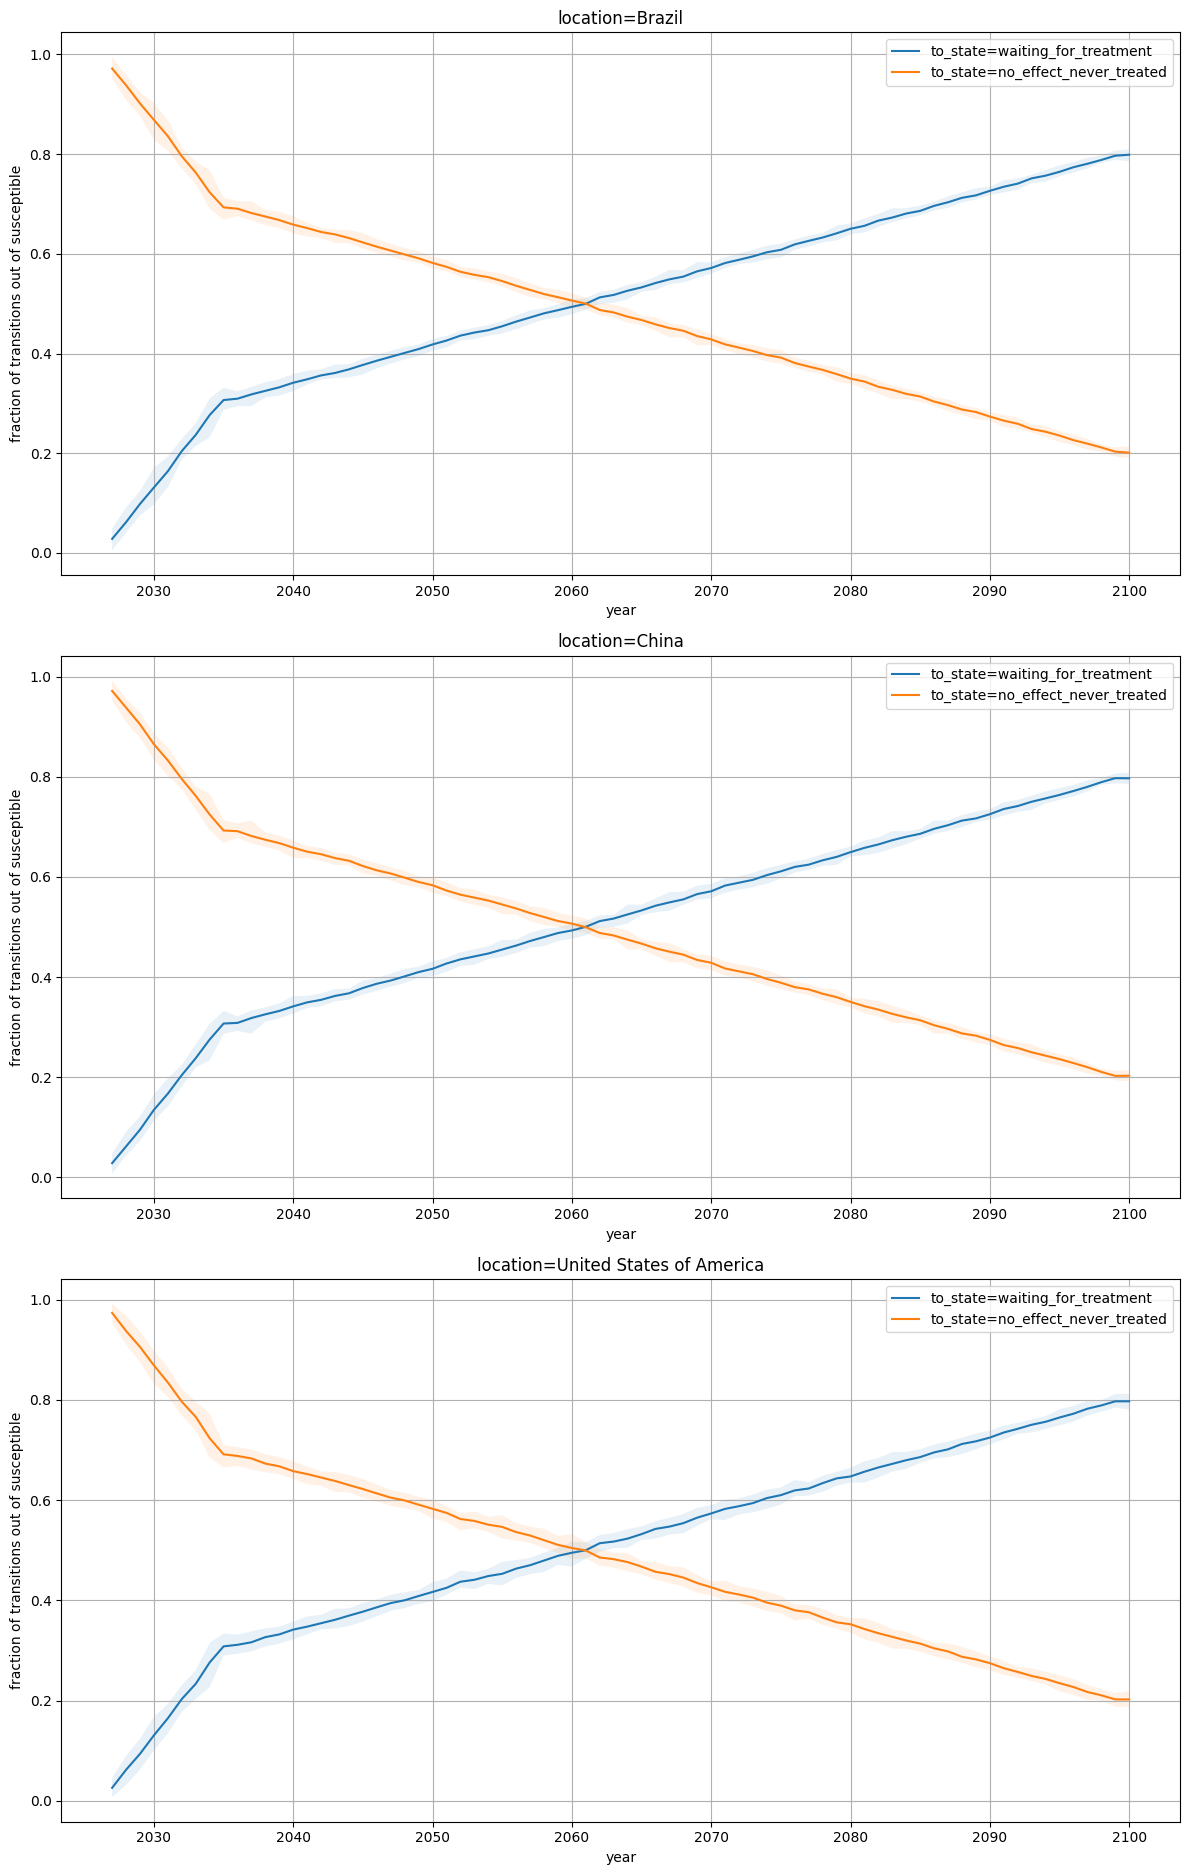

In [57]:
fig = plot_over_time_by_column_for_row_x_1(
    initiate_vs_not,
    'to_state',
    'location',
    ylabel='fraction of transitions out of susceptible',
)
for ax in fig.axes:
    # Looks like this is unnecessary after converting year to int
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)

# Check #2 (completes vs. discontinues treatment)

10% of transitions to Full treatment effect status are by simulants who
discontinue treatment

## Strategy using new `treatment_duration` dataframe

For each year, compute the fraction of simulants who complete 9 months
of treatment among those who complete more than 0 months of treatment.
This should be 90%. Moreover, in this same group, for each $k\in \{1, \dotsc, 8\}$, the
fraction of those who complete $k$ months of treatment should be 10/8 =
1.25%.

Out of the total, the fraction of simulants who complete more than 0
months of treatment should (maybe) be the treatment rate for the year.

## Looks good

In [58]:
colname_to_dtype

{'event_year': 'int16',
 'age_group': CategoricalDtype(categories=['25_to_29', '30_to_34', '35_to_39', '40_to_44', '45_to_49',
                   '50_to_54', '55_to_59', '60_to_64', '65_to_69', '70_to_74',
                   '75_to_79', '80_to_84', '85_to_89', '90_to_94', '95_plus'],
 , ordered=True),
 'scenario': CategoricalDtype(categories=['baseline', 'bbbm_testing', 'bbbm_testing_and_treatment'], ordered=True)}

In [59]:
treatment_duration = load_sim_output(
    'treatment_duration',
    colname_to_dtype = colname_to_dtype | {'sub_entity': 'int8'},
    )
treatment_duration

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,0,0.0,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,1,0.0,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,2,0.0,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,3,0.0,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,4,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
5332495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,5,0.0,Brazil
5332496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,6,0.0,Brazil
5332497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,7,0.0,Brazil
5332498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,8,0.0,Brazil


In [60]:
treatment_duration.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity           int8
value             float64
location         category
dtype: object

In [61]:
treatment_duration.scenario.unique()

['baseline', 'bbbm_testing', 'bbbm_testing_and_treatment']
Categories (3, object): ['baseline' < 'bbbm_testing' < 'bbbm_testing_and_treatment']

In [62]:
assert set(treatment_duration.query("value > 0").scenario.unique()) == {'bbbm_testing_and_treatment'}, \
    "Treatments occurring in wrong scenarios"

In [63]:
assert set(treatment_duration.query("value > 0").age_group.unique()) \
    == {'65_to_69', '70_to_74', '75_to_79'}, \
        "Treatments occurring in wrong age groups"

In [64]:
# Compute fraction of treatments discontinued after k months, where k =
# 1, 2, 3, ..., 9
fraction_among_treated = ops.ratio(
    treatment_duration,
    treatment_duration,
    # Stratify by year so we can plot over time
    strata=['event_year'],
    # Stratify numerator by months of treatment; denominator will be the
    # sum of all those with more than 0 months
    numerator_broadcast=['sub_entity'],
    # Filter to those who got treatment
    prefilter_query="sub_entity > 0",
).rename(columns={'sub_entity': 'months_of_treatment'})
fraction_among_treated

,event_year,input_draw,scenario,location,months_of_treatment,value,numerator_measure,denominator_measure,multiplier
0,2022,1,baseline,Brazil,1,NaN,treatment_duration_count,treatment_duration_count,1
1,2022,1,baseline,Brazil,2,NaN,treatment_duration_count,treatment_duration_count,1
2,2022,1,baseline,Brazil,3,NaN,treatment_duration_count,treatment_duration_count,1
3,2022,1,baseline,Brazil,4,NaN,treatment_duration_count,treatment_duration_count,1
4,2022,1,baseline,Brazil,5,NaN,treatment_duration_count,treatment_duration_count,1
...,...,...,...,...,...,...,...,...,...
159970,2100,249,bbbm_testing_and_treatment,United States of America,5,0.012579,treatment_duration_count,treatment_duration_count,1
159971,2100,249,bbbm_testing_and_treatment,United States of America,6,0.012095,treatment_duration_count,treatment_duration_count,1
159972,2100,249,bbbm_testing_and_treatment,United States of America,7,0.011127,treatment_duration_count,treatment_duration_count,1
159973,2100,249,bbbm_testing_and_treatment,United States of America,8,0.011127,treatment_duration_count,treatment_duration_count,1


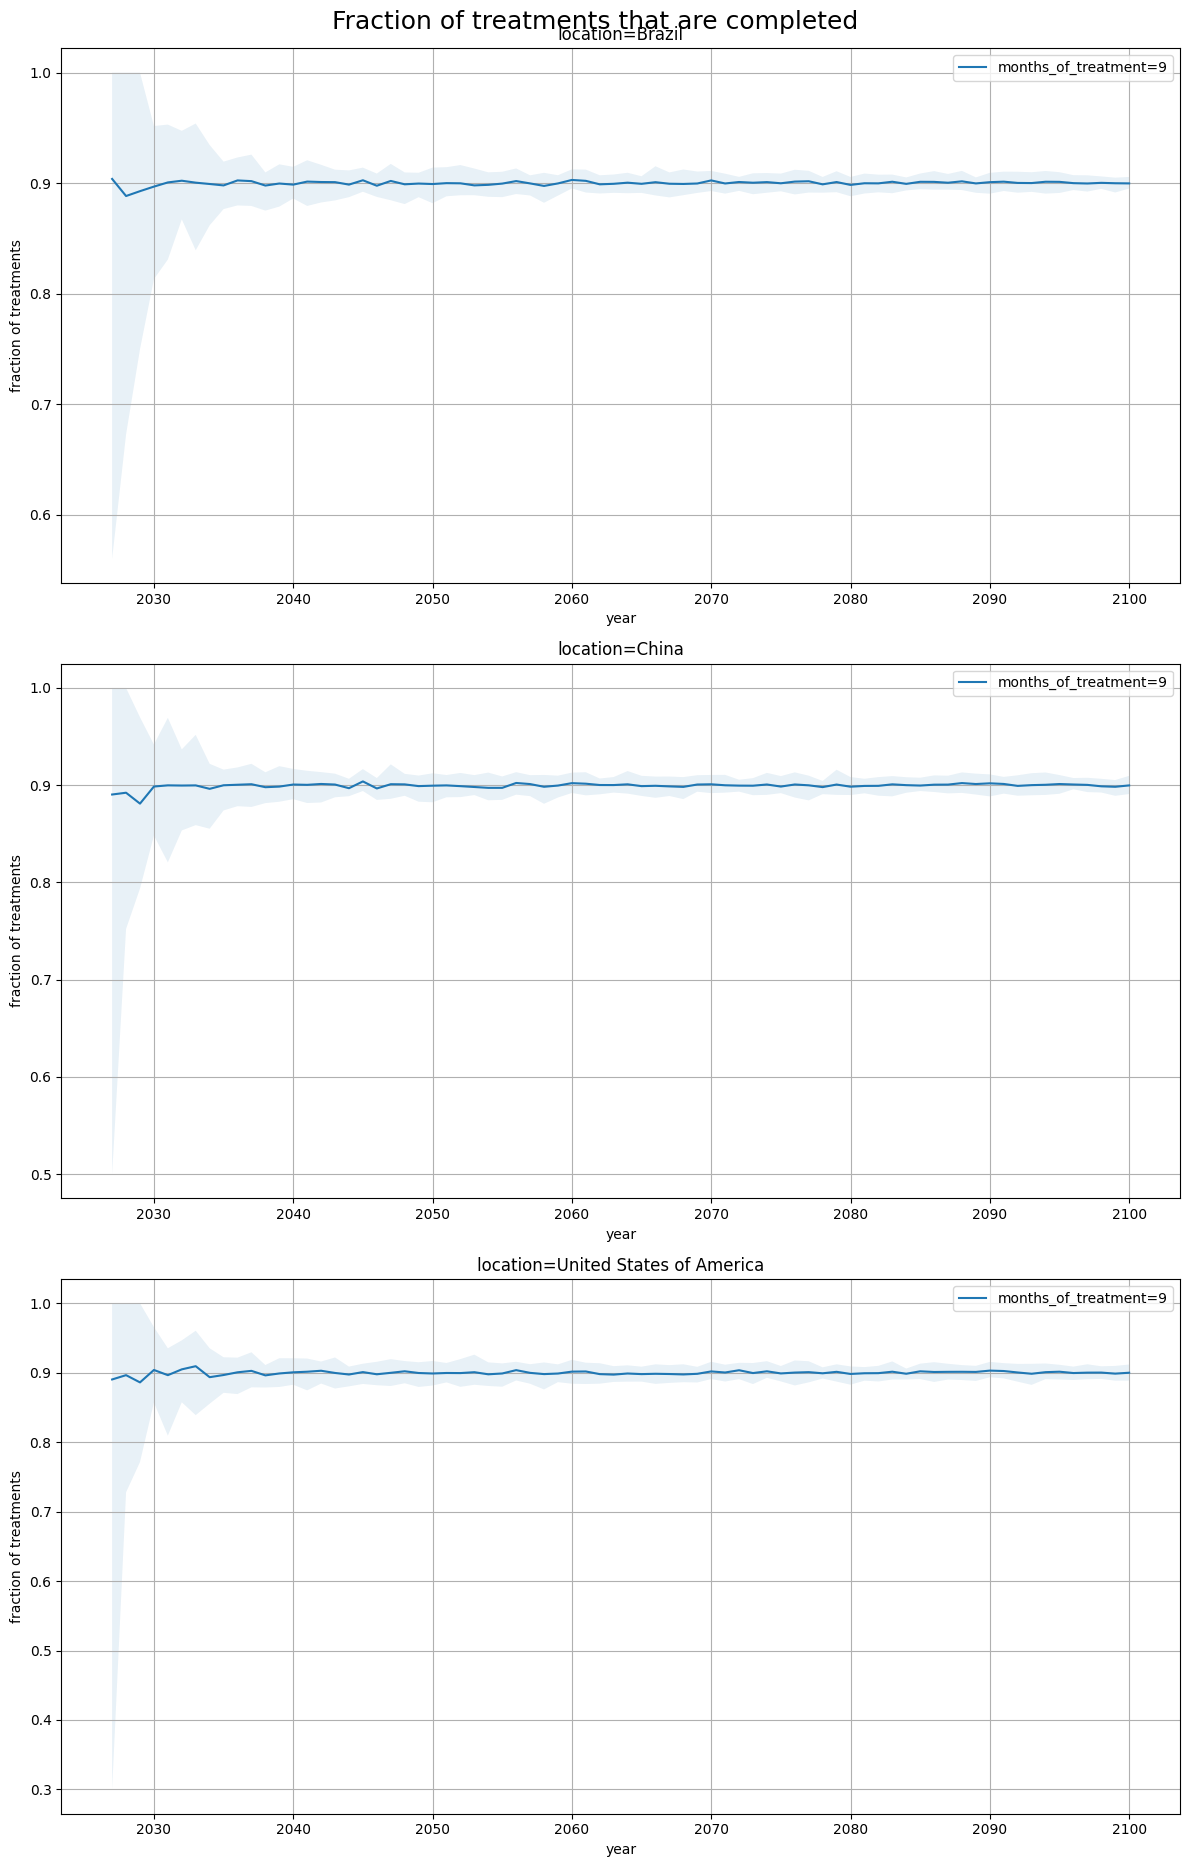

In [65]:
fig = plot_over_time_by_column_for_row_x_1(
    # Sub-entity is the number of months of treatment received
    fraction_among_treated.query("months_of_treatment == 9"),
    'months_of_treatment',
    'location',
    ylabel='fraction of treatments',
    suptitle='Fraction of treatments that are completed',
)
for ax in fig.axes:
    ax.grid(True)

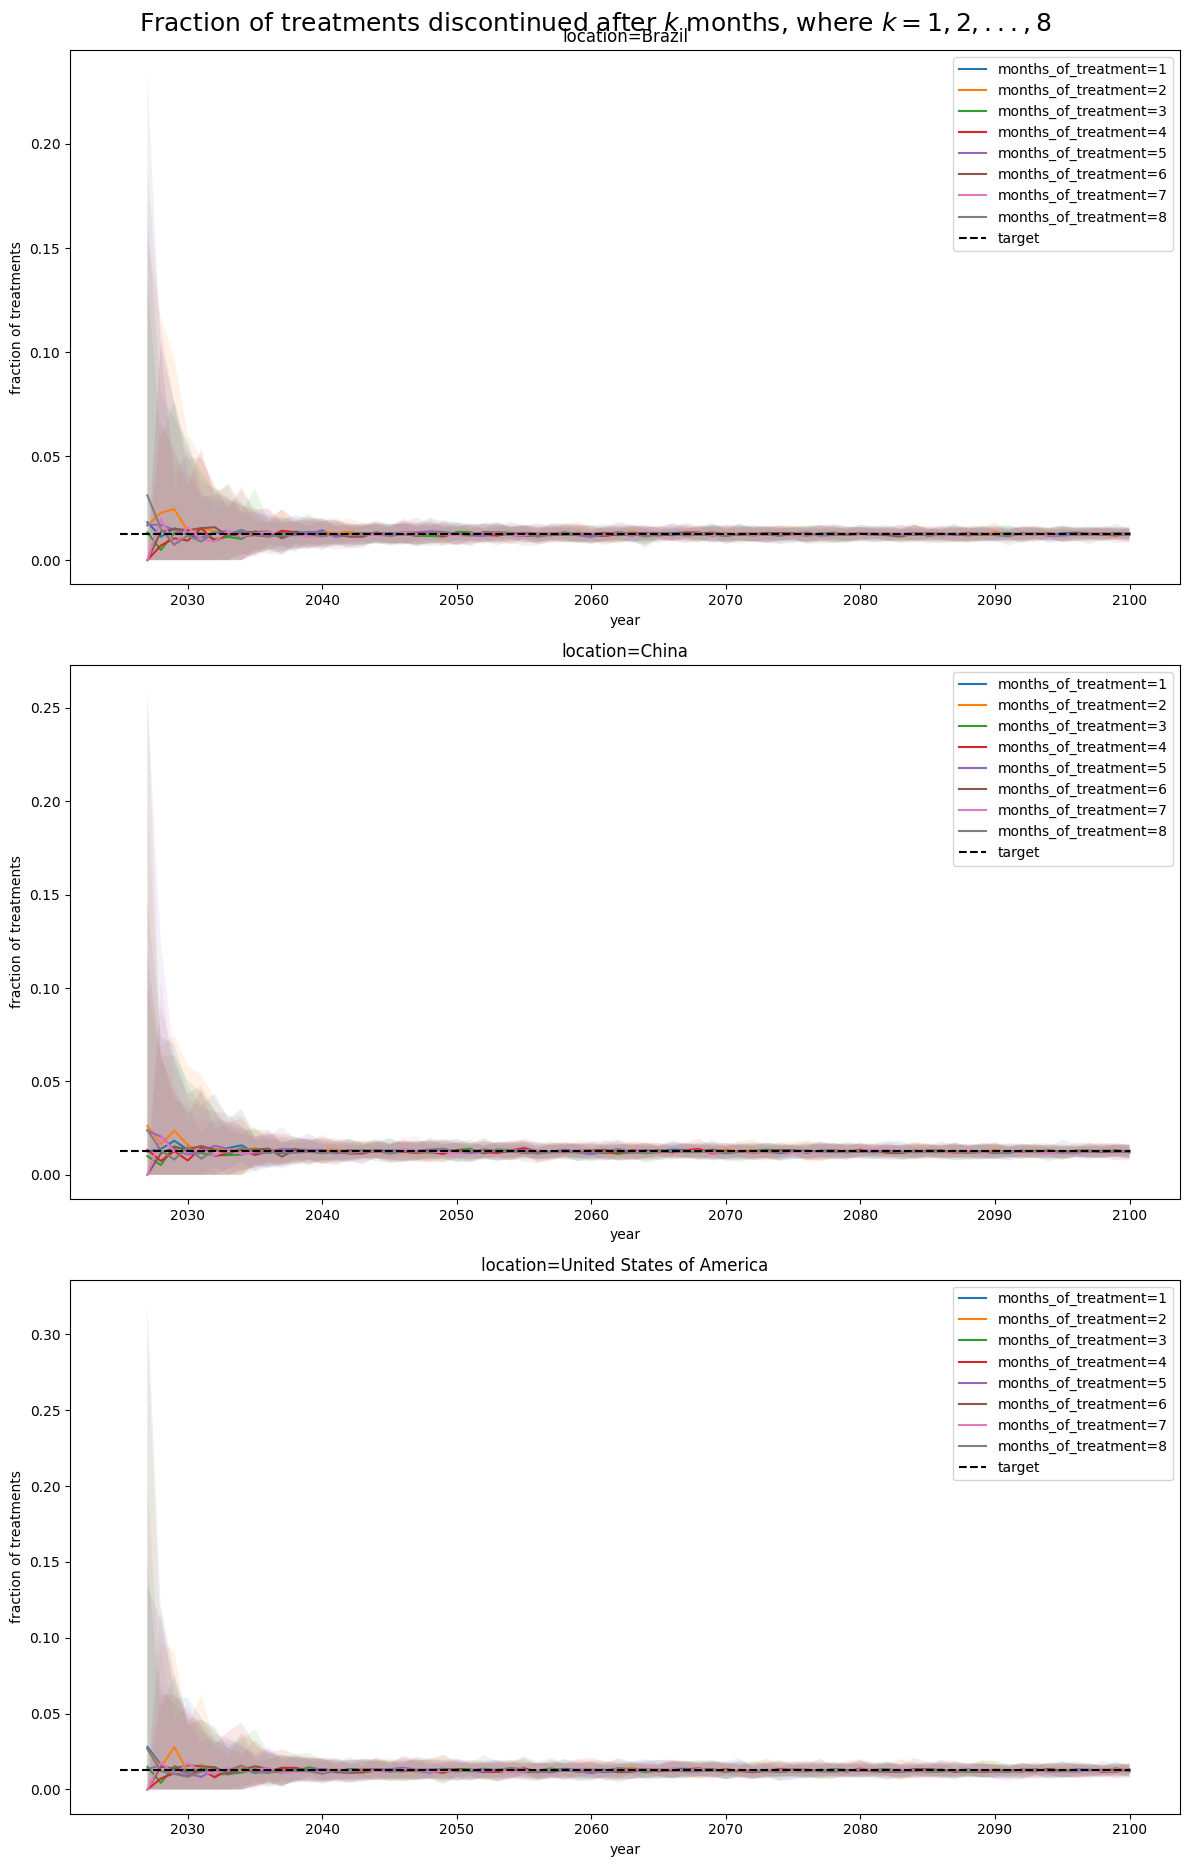

In [66]:
fig = plot_over_time_by_column_for_row_x_1(
    fraction_among_treated.query("months_of_treatment != 9"),
    'months_of_treatment',
    'location',
    ylabel='fraction of treatments',
    suptitle='Fraction of treatments discontinued after $k$ months, where $k=1, 2, ..., 8$',
)
for ax in fig.axes:
    ax.hlines(0.1/8, 2025, 2100, 'black', '--', label='target')
    ax.legend()

## Compute total number of people treated, and number of completed vs. discontinued treatment

In [67]:
# NOTE (2026-02-19): I originally used the following dictionary in my
# call to aggregate_categories below. Amazingly, this mostly worked as
# expected because pandas .replace can correctly interpret keys that are
# range objects! But this is not what I intended: My _ensure_iterable
# function treated the range as a singleton whereas I was (foolishly)
# expecting the ranges to be "unpacked". This caused my check for
# mutually exclusive lists to fail (it incorrectly said that the
# following dictionary had mutually exclusive lists for values), which
# led to unexpected results in the aggregation (see example series
# below). I addressed the problem by adding `range`` to the list of
# iterable types allowed by _ensure_iterable... not sure if that's the
# best solution.
d = {
        'not_treated': 0,
        'treated': range(1, 10),
        'completed_treatment': 9,
        'discontinued_treatment': range(1, 9),
    }
d_inv = {v: k for k, v in d.items()}
print(d_inv)
s = pd.Series(range(20))
s.replace(d_inv)

{0: 'not_treated', range(1, 10): 'treated', 9: 'completed_treatment', range(1, 9): 'discontinued_treatment'}


0                not_treated
1     discontinued_treatment
2     discontinued_treatment
3     discontinued_treatment
4     discontinued_treatment
5     discontinued_treatment
6     discontinued_treatment
7     discontinued_treatment
8     discontinued_treatment
9        completed_treatment
10                        10
11                        11
12                        12
13                        13
14                        14
15                        15
16                        16
17                        17
18                        18
19                        19
dtype: object

In [68]:
treated_vs_not = ops.aggregate_categories(
    treatment_duration,
    'sub_entity',
    {
        'not_treated': 0,
        'treated': range(1, 10),
        'completed_treatment': 9,
        'discontinued_treatment': range(1, 9),
    },
)
treated_vs_not

ValueError: The sets of categories in each supercategory must be mutually exclusive

In [ ]:
d = {
        'not_treated': 0,
        'treated': range(1, 10),
        'completed_treatment': 9,
        'discontinued_treatment': range(1, 9),
    }
vh.utils.lists_are_mutually_exclusive(d.values())

False

In [ ]:
vh.utils._ensure_iterable(range(1,10))

range(1, 10)

In [ ]:
supercategory_to_categories = d
category_to_supercategory = {
            category: supercategory
            for supercategory, categories
                in supercategory_to_categories.items()
            for category in vh.utils._ensure_iterable(categories)
        }

category_to_supercategory

{0: 'not_treated',
 1: 'discontinued_treatment',
 2: 'discontinued_treatment',
 3: 'discontinued_treatment',
 4: 'discontinued_treatment',
 5: 'discontinued_treatment',
 6: 'discontinued_treatment',
 7: 'discontinued_treatment',
 8: 'discontinued_treatment',
 9: 'completed_treatment'}

In [ ]:
s = pd.Series(range(20))
s.replace(category_to_supercategory)

0                not_treated
1     discontinued_treatment
2     discontinued_treatment
3     discontinued_treatment
4     discontinued_treatment
5     discontinued_treatment
6     discontinued_treatment
7     discontinued_treatment
8     discontinued_treatment
9        completed_treatment
10                        10
11                        11
12                        12
13                        13
14                        14
15                        15
16                        16
17                        17
18                        18
19                        19
dtype: object

In [ ]:
d = {
        'not_treated': 0,
        'treated': range(1, 10),
        'completed_treatment': 9,
        'discontinued_treatment': range(1, 9),
    }
d_inv = {v: k for k, v in d.items()}
print(d_inv)
s = pd.Series(range(20))
s.replace(d_inv)

{0: 'not_treated', range(1, 10): 'treated', 9: 'completed_treatment', range(1, 9): 'discontinued_treatment'}


0                not_treated
1     discontinued_treatment
2     discontinued_treatment
3     discontinued_treatment
4     discontinued_treatment
5     discontinued_treatment
6     discontinued_treatment
7     discontinued_treatment
8     discontinued_treatment
9        completed_treatment
10                        10
11                        11
12                        12
13                        13
14                        14
15                        15
16                        16
17                        17
18                        18
19                        19
dtype: object

In [ ]:
s.replace(d_inv)

0                not_treated
1     discontinued_treatment
2     discontinued_treatment
3     discontinued_treatment
4     discontinued_treatment
5     discontinued_treatment
6     discontinued_treatment
7     discontinued_treatment
8     discontinued_treatment
9        completed_treatment
10                        10
11                        11
12                        12
13                        13
14                        14
15                        15
16                        16
17                        17
18                        18
19                        19
dtype: object

In [ ]:
type(range(1, 10))

range

In [ ]:
treated_vs_not.sub_entity.unique()

array(['completed_treatment', 'discontinued_treatment', 'not_treated'],
      dtype=object)

In [ ]:
assert set(treated_vs_not.query("sub_entity == 'not_treated'").value.unique()) == {0}, \
    "Treatment durations should only be recorded among treated simulants"

## Check fraction of people who complete vs. discontinue treatment

In [ ]:
fraction_completed = ops.ratio(
    treated_vs_not,
    treated_vs_not,
    strata=['event_year'],
    numerator_broadcast='sub_entity',
    prefilter_query=(
        "sub_entity in ['completed_treatment', 'discontinued_treatment']"
        f" and age_group in {testing_eligible_age_groups}"
    ),
)
fraction_completed


,event_year,input_draw,scenario,location,sub_entity,value,numerator_measure,denominator_measure,multiplier
0,2022,1,baseline,Brazil,completed_treatment,NaN,treatment_duration_count,treatment_duration_count,1
1,2022,1,baseline,Brazil,discontinued_treatment,NaN,treatment_duration_count,treatment_duration_count,1
2,2022,1,baseline,Brazil,not_treated,NaN,treatment_duration_count,treatment_duration_count,1
3,2022,1,baseline,China,completed_treatment,NaN,treatment_duration_count,treatment_duration_count,1
4,2022,1,baseline,China,discontinued_treatment,NaN,treatment_duration_count,treatment_duration_count,1
...,...,...,...,...,...,...,...,...,...
53320,2100,249,bbbm_testing_and_treatment,China,discontinued_treatment,0.095673,treatment_duration_count,treatment_duration_count,1
53321,2100,249,bbbm_testing_and_treatment,China,not_treated,0.000000,treatment_duration_count,treatment_duration_count,1
53322,2100,249,bbbm_testing_and_treatment,United States of America,completed_treatment,0.909047,treatment_duration_count,treatment_duration_count,1
53323,2100,249,bbbm_testing_and_treatment,United States of America,discontinued_treatment,0.090953,treatment_duration_count,treatment_duration_count,1


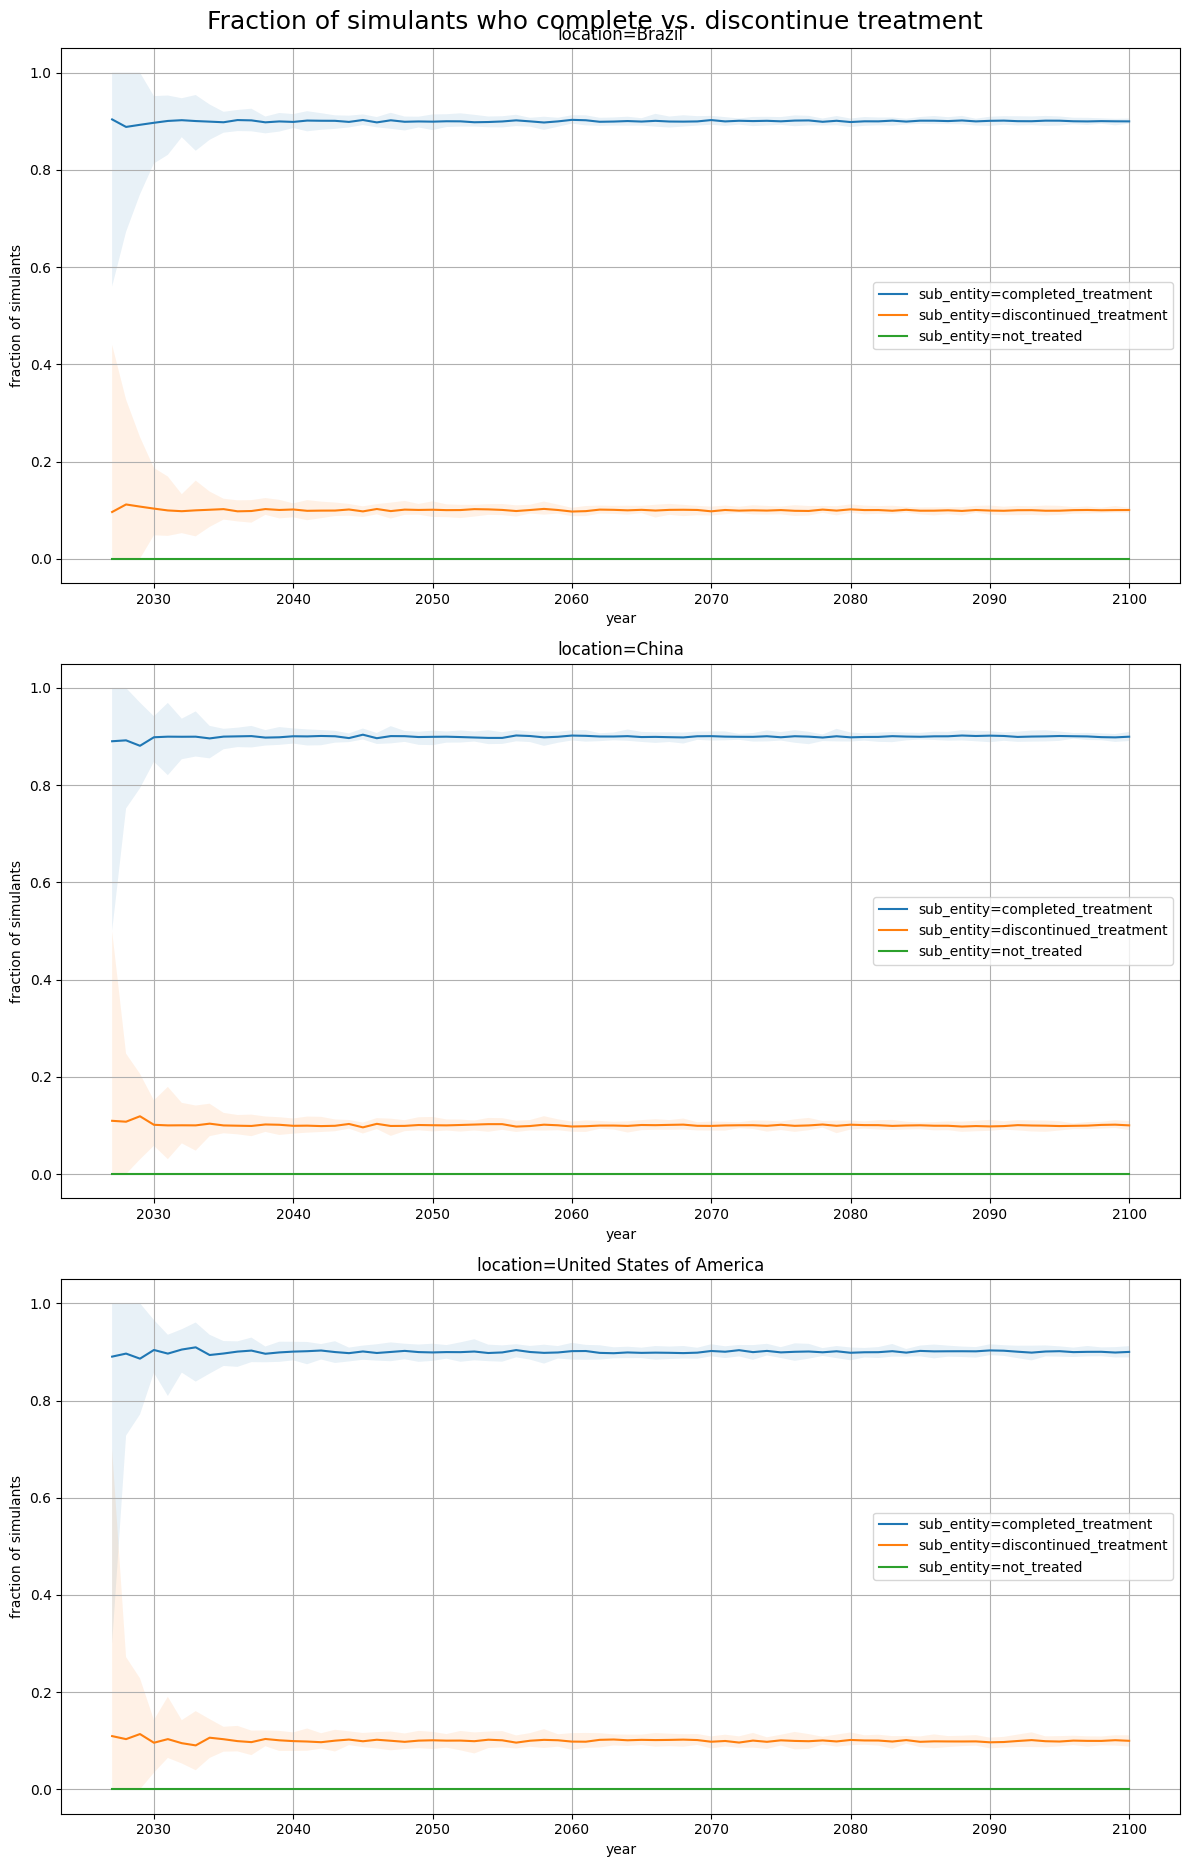

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    fraction_completed,
    'sub_entity',
    'location',
    ylabel='fraction of simulants',
    suptitle='Fraction of simulants who complete vs. discontinue treatment',
)
for ax in fig.axes:
    ax.grid(True)

In [ ]:
treatment_duration.query("event_year>=2050").groupby('sub_entity')['value'].sum()

sub_entity
0          0.0
1     116493.0
2     117492.0
3     116335.0
4     116627.0
5     115618.0
6     116586.0
7     116618.0
8     115791.0
9    8395406.0
Name: value, dtype: float64

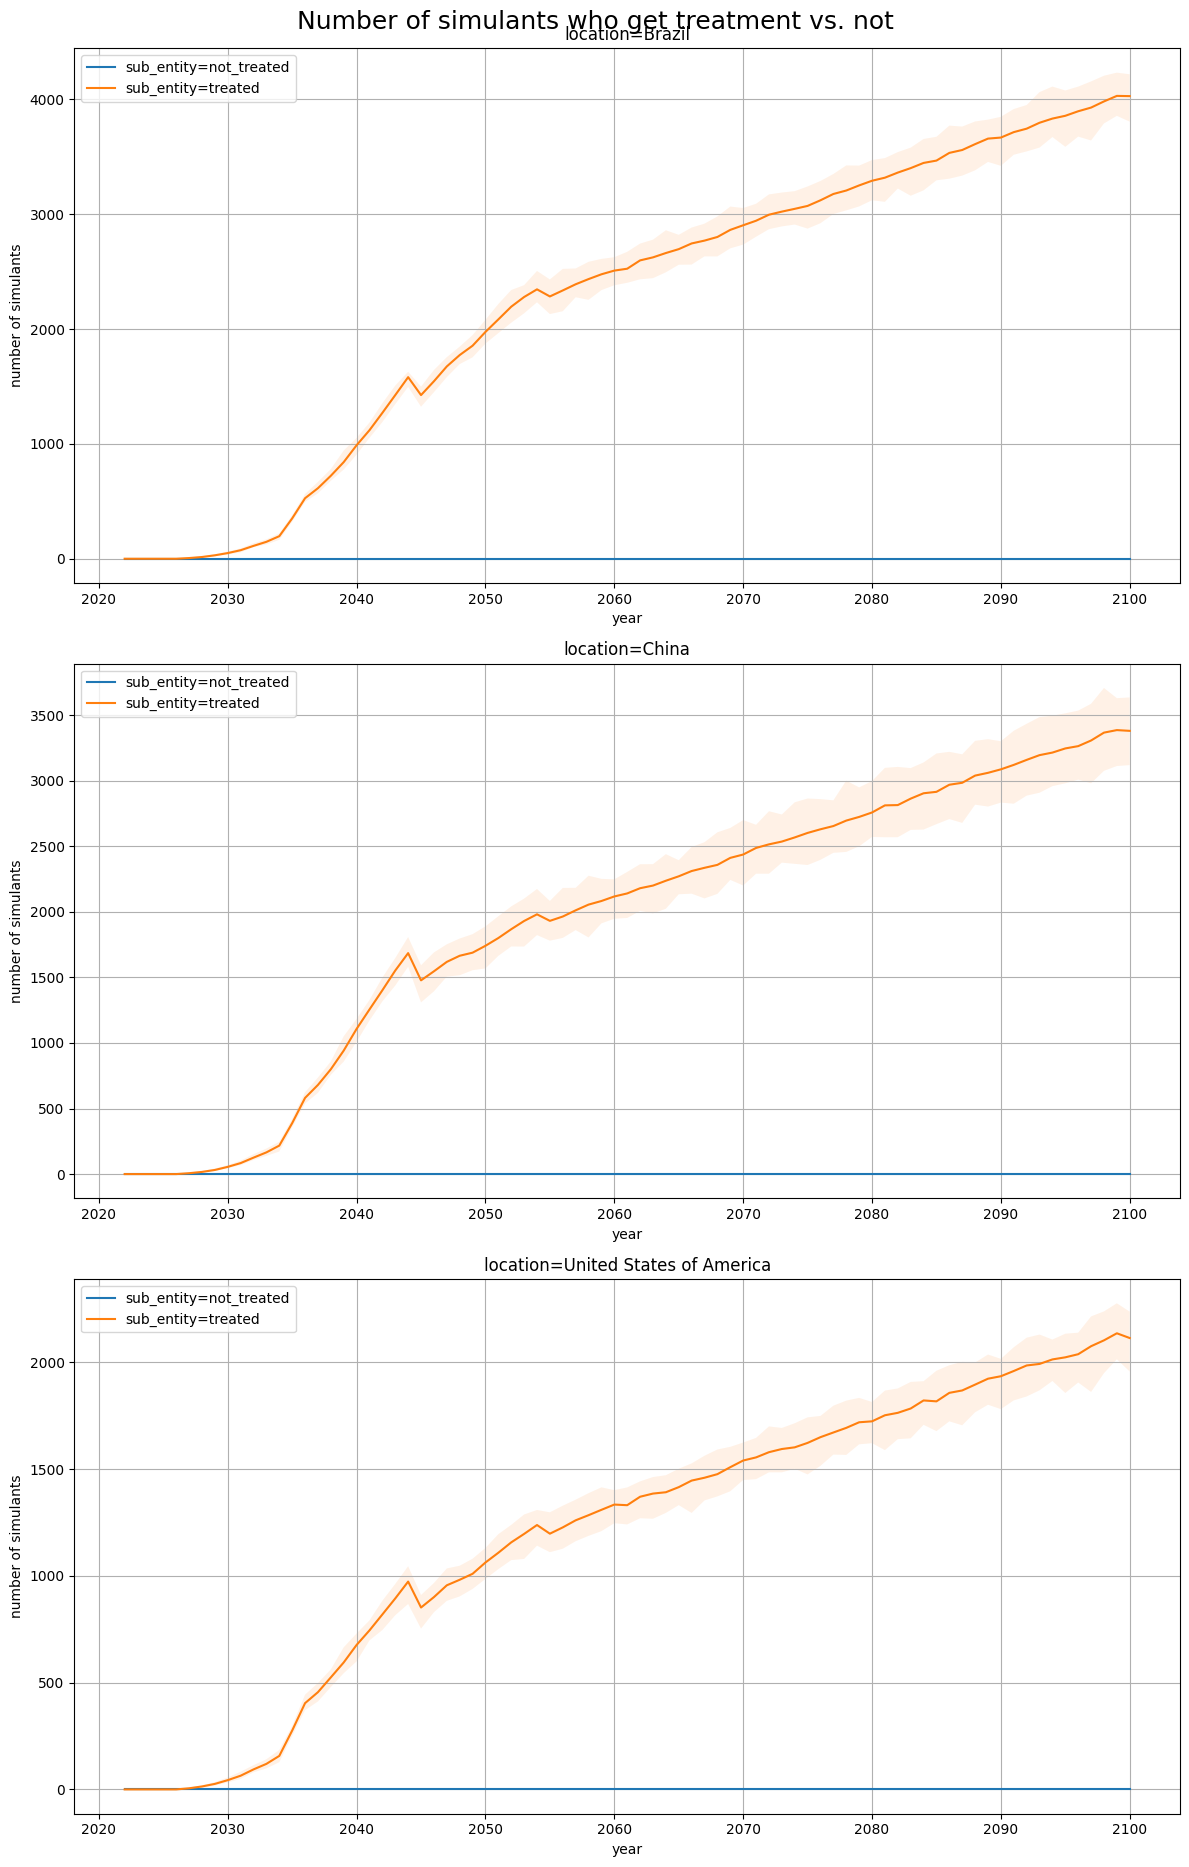

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    ops.stratify(treated_vs_not.query("scenario == 'bbbm_testing_and_treatment'"), ['sub_entity', 'event_year']),
    # ops.stratify(treatment_duration,)
    'sub_entity',
    'location',
    uncertainty=True,
    ylabel='number of simulants',
    suptitle='Number of simulants who get treatment vs. not',
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()

In [ ]:
treatment_duration

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,0,0.0,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,1,0.0,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,2,0.0,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,3,0.0,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,treatment_duration_count,baseline,Female,4,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
5332495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,5,0.0,Brazil
5332496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,6,0.0,Brazil
5332497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,7,0.0,Brazil
5332498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,treatment_duration_count,bbbm_testing_and_treatment,Male,8,0.0,Brazil


In [ ]:
ops.stratify(treated_vs_not, ['sub_entity', 'event_year'])

,sub_entity,event_year,input_draw,scenario,location,value
0,not_treated,2022,1,baseline,Brazil,0.0
1,not_treated,2022,1,baseline,China,0.0
2,not_treated,2022,1,baseline,United States of America,0.0
3,not_treated,2022,1,bbbm_testing,Brazil,0.0
4,not_treated,2022,1,bbbm_testing,China,0.0
...,...,...,...,...,...,...
35545,treated,2100,249,bbbm_testing,China,0.0
35546,treated,2100,249,bbbm_testing,United States of America,0.0
35547,treated,2100,249,bbbm_testing_and_treatment,Brazil,4038.0
35548,treated,2100,249,bbbm_testing_and_treatment,China,3397.0


In [ ]:
ops.stratify(treatment_duration, ['event_year'])

,event_year,input_draw,scenario,location,value
0,2022,1,baseline,Brazil,0.0
1,2022,1,baseline,China,0.0
2,2022,1,baseline,United States of America,0.0
3,2022,1,bbbm_testing,Brazil,0.0
4,2022,1,bbbm_testing,China,0.0
...,...,...,...,...,...
17770,2100,249,bbbm_testing,China,0.0
17771,2100,249,bbbm_testing,United States of America,0.0
17772,2100,249,bbbm_testing_and_treatment,Brazil,4038.0
17773,2100,249,bbbm_testing_and_treatment,China,3397.0


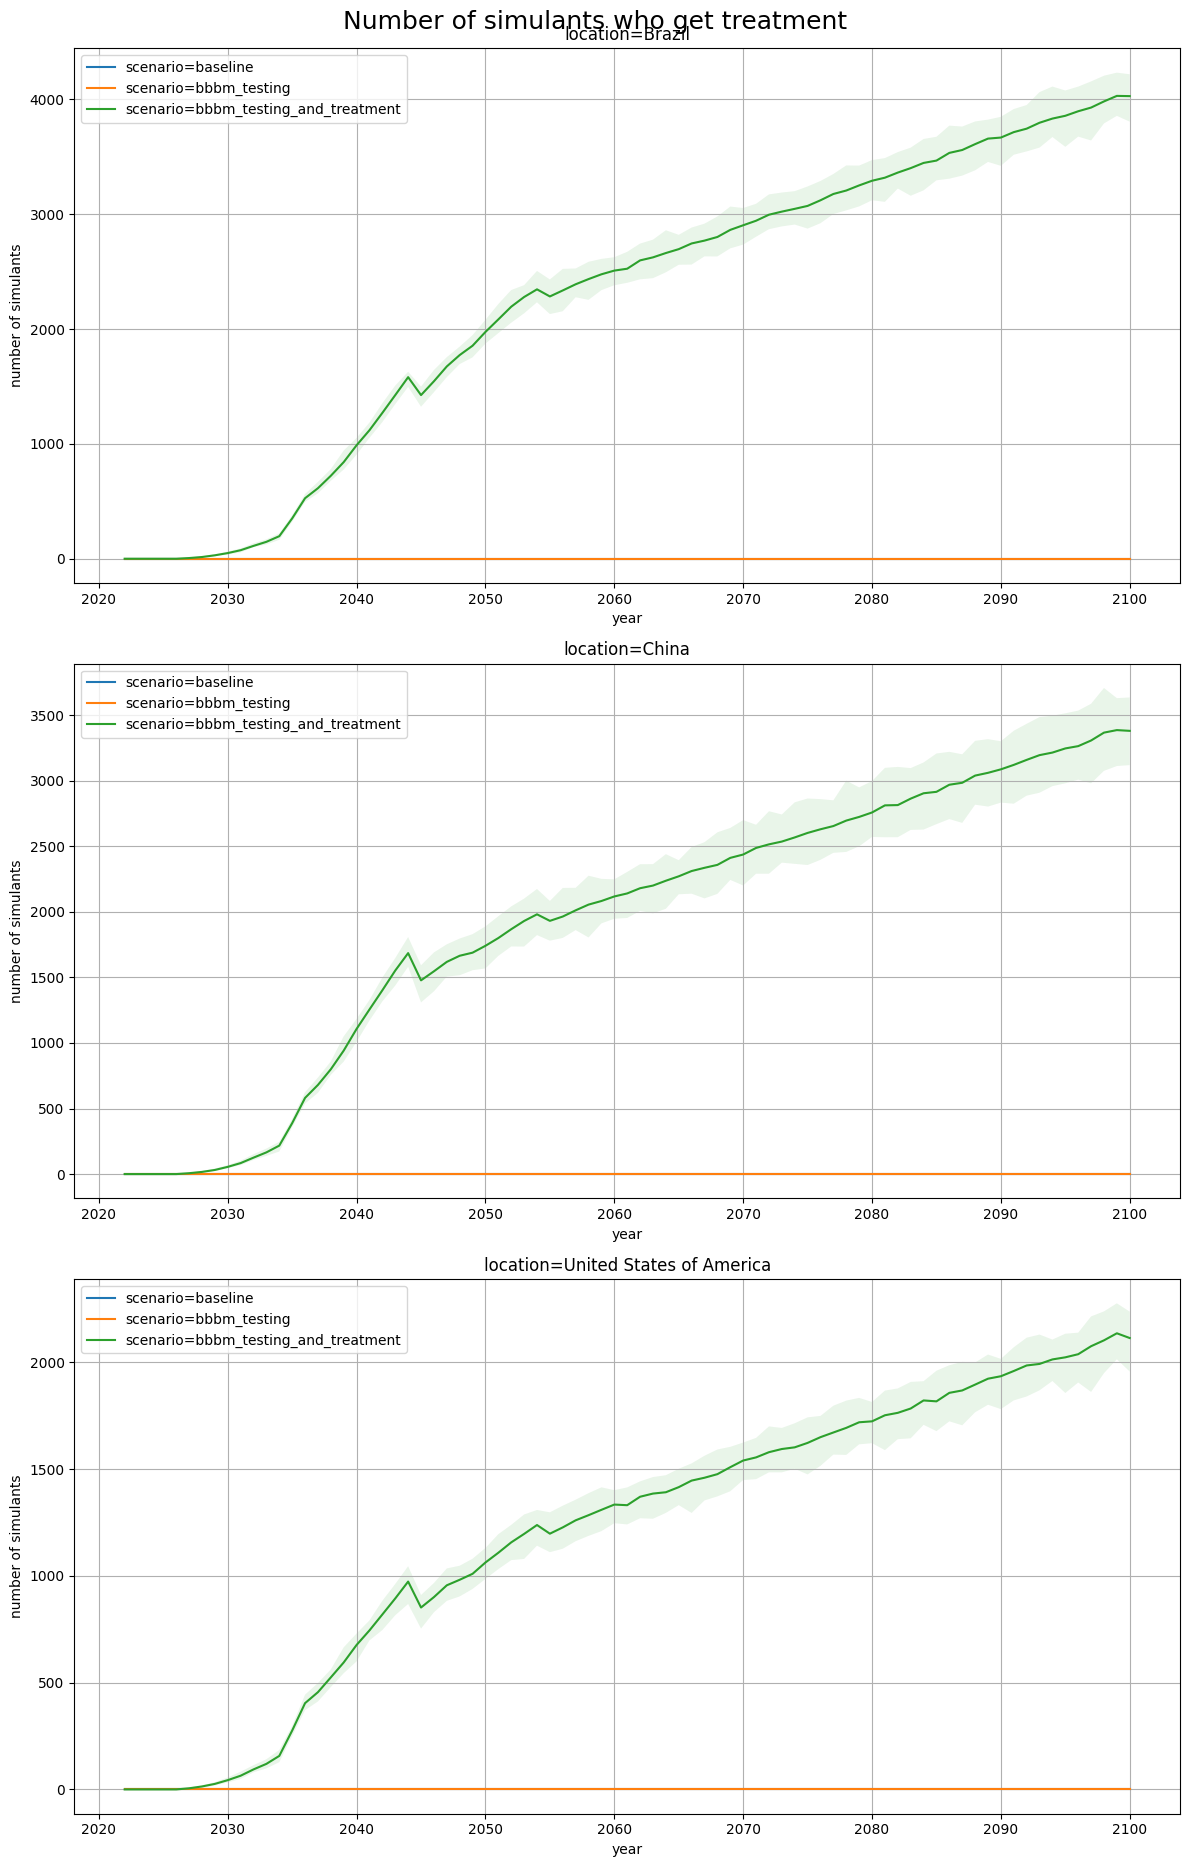

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    # ops.stratify(treated_vs_not, ['sub_entity', 'event_year']),
    ops.stratify(treatment_duration.query("sub_entity != 0"), ['event_year']).assign(treated='treated'),#.query(
        # "scenario == 'bbbm_testing_and_treatment'"),
    'scenario',
    'location',
    uncertainty=True,
    ylabel='number of simulants',
    suptitle='Number of simulants who get treatment',
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()

In [ ]:
treatment_transitions.sub_entity.unique()

['waiting_for_treatment_to_treatment_effect', 'treatment_effect_to_waning_effect', 'waning_effect_to_no_effect_after_treatment', 'susceptible_to_treatment_to_waiting_for_treat..., 'susceptible_to_treatment_to_no_effect_never_t...]
Categories (5, object): ['susceptible_to_treatment_to_no_effect_never_t..., 'susceptible_to_treatment_to_waiting_for_treat..., 'treatment_effect_to_waning_effect', 'waiting_for_treatment_to_treatment_effect', 'waning_effect_to_no_effect_after_treatment']

In [ ]:
treatment_transitions.value_counts(['from_state', 'to_state'])

from_state                to_state                 
susceptible_to_treatment  no_effect_never_treated      177750
                          waiting_for_treatment        177750
treatment_effect          waning_effect                177750
waiting_for_treatment     treatment_effect             177750
waning_effect             no_effect_after_treatment    177750
dtype: int64

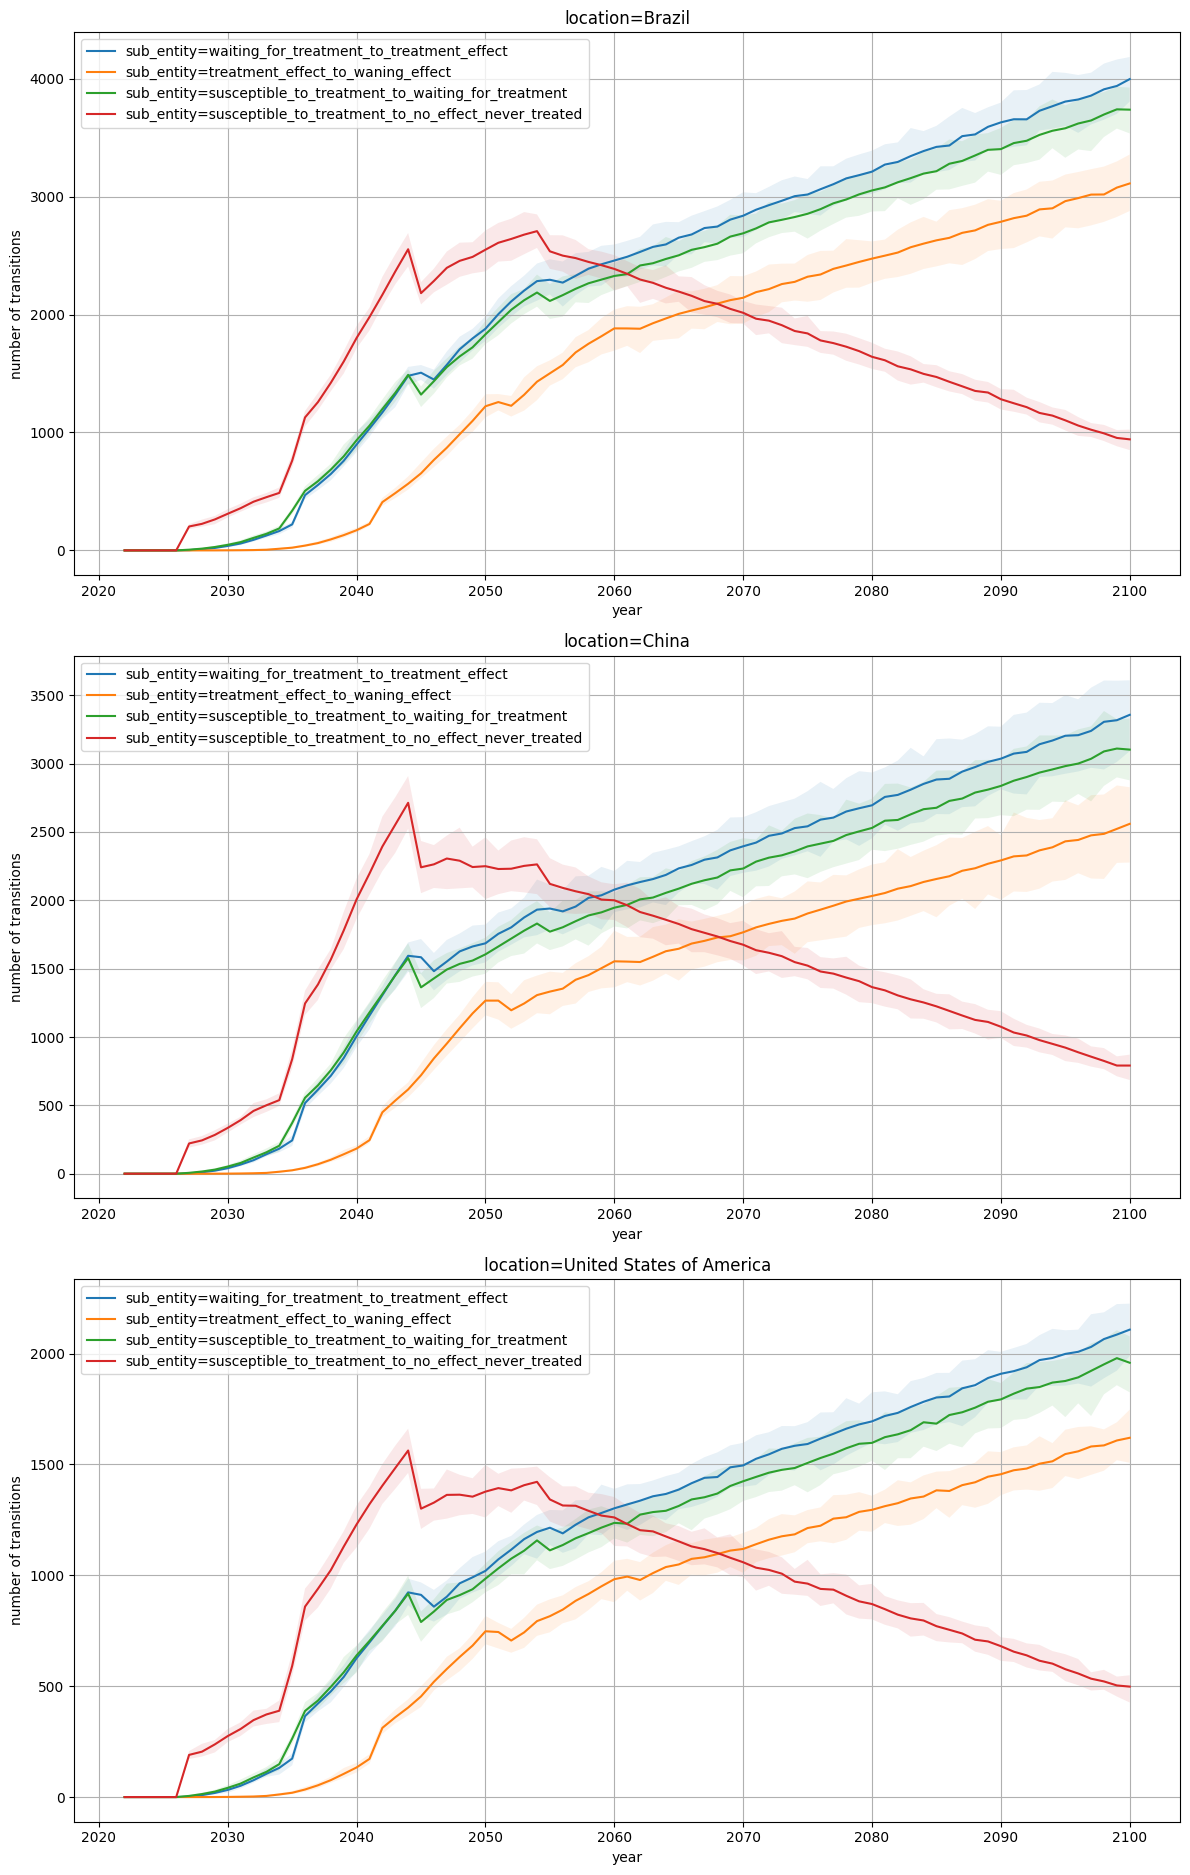

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    (
        treatment_transitions
        .query(
        # "sub_entity == 'susceptible_to_treatment_to_waiting_for_treatment'"
        "from_state in ['susceptible_to_treatment', 'waiting_for_treatment', 'treatment_effect']")
        .pipe(ops.stratify, ['sub_entity', 'event_year'])
    ),
    'sub_entity',
    'location',
    uncertainty=True,
    ylabel='number of transitions',
    # suptitle='Number of simulants who get treatment vs. not',
)
for ax in fig.axes:
    # ax.semilogy()
    ax.grid(True)

In [ ]:
treated_vs_not

,age_group,artifact_path,entity,entity_type,event_year,input_draw,location,measure,scenario,sex,sub_entity,value
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Female,not_treated,0.0
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Female,treated,0.0
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Male,not_treated,0.0
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Male,treated,0.0
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,bbbm_testing,Female,not_treated,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1066495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,treatment_duration_count,bbbm_testing,Male,treated,0.0
1066496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,treatment_duration_count,bbbm_testing_and_treatment,Female,not_treated,0.0
1066497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,treatment_duration_count,bbbm_testing_and_treatment,Female,treated,0.0
1066498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,treatment_duration_count,bbbm_testing_and_treatment,Male,not_treated,0.0


In [ ]:
treatment_transitions

,age_group,artifact_path,entity,entity_type,event_year,input_draw,location,measure,scenario,sex,sub_entity,value,from_state,to_state
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,waiting_for_treatment_to_treatment_effect,0.0,waiting_for_treatment,treatment_effect
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,treatment_effect_to_waning_effect,0.0,treatment_effect,waning_effect
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,waning_effect_to_no_effect_after_treatment,0.0,waning_effect,no_effect_after_treatment
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_waiting_for_treatment,0.0,susceptible_to_treatment,waiting_for_treatment
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_no_effect_never_tr...,0.0,susceptible_to_treatment,no_effect_never_treated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888745,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waiting_for_treatment_to_treatment_effect,0.0,waiting_for_treatment,treatment_effect
888746,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,treatment_effect_to_waning_effect,0.0,treatment_effect,waning_effect
888747,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,25.0,waning_effect,no_effect_after_treatment
888748,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_waiting_for_treatment,0.0,susceptible_to_treatment,waiting_for_treatment


In [ ]:
treatment_counts = pd.concat([treated_vs_not, treatment_transitions], ignore_index=True)
treatment_counts

,age_group,artifact_path,entity,entity_type,event_year,input_draw,location,measure,scenario,sex,sub_entity,value,from_state,to_state
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Female,not_treated,0.0,NaN,NaN
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Female,treated,0.0,NaN,NaN
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Male,not_treated,0.0,NaN,NaN
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,baseline,Male,treated,0.0,NaN,NaN
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,United States of America,treatment_duration_count,bbbm_testing,Female,not_treated,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955245,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waiting_for_treatment_to_treatment_effect,0.0,waiting_for_treatment,treatment_effect
1955246,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,treatment_effect_to_waning_effect,0.0,treatment_effect,waning_effect
1955247,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,25.0,waning_effect,no_effect_after_treatment
1955248,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_waiting_for_treatment,0.0,susceptible_to_treatment,waiting_for_treatment


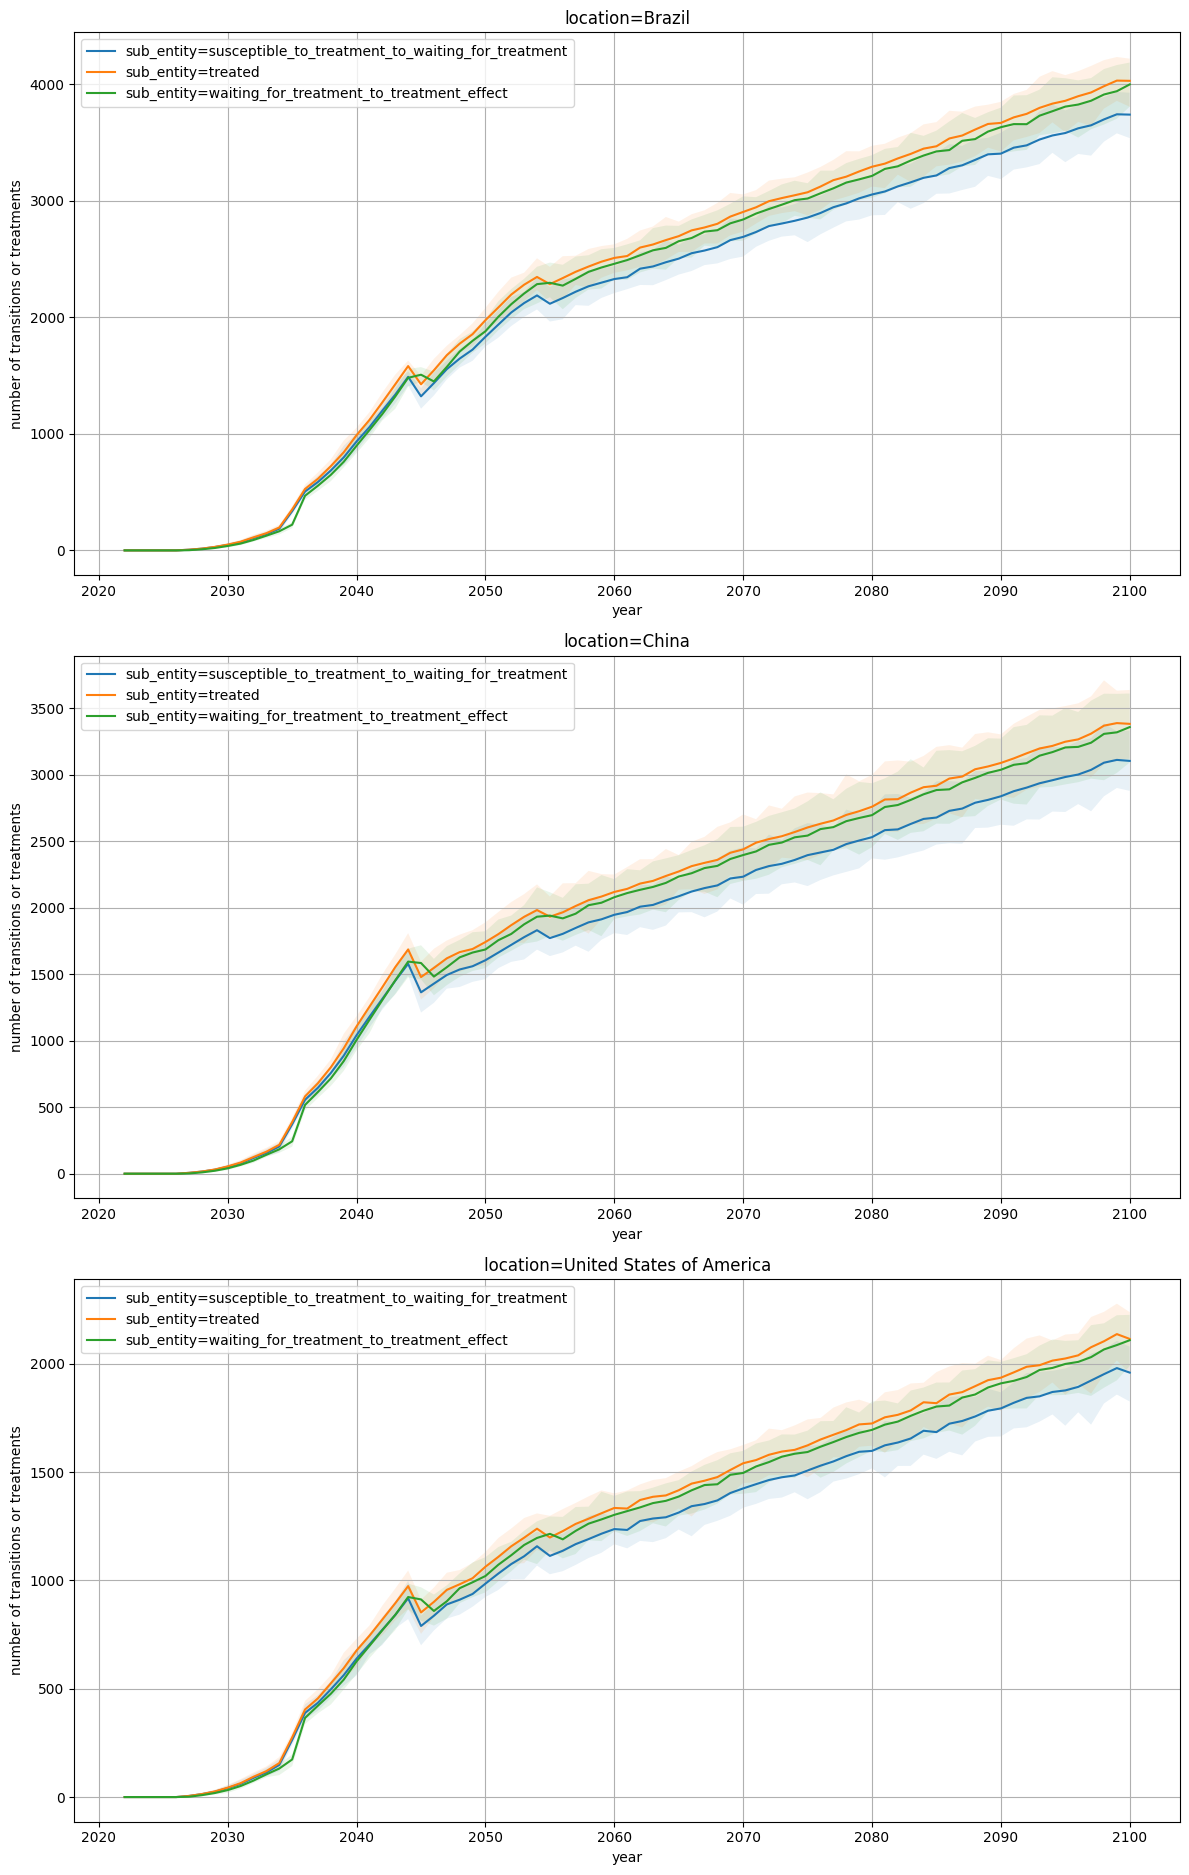

In [ ]:
treatment_initiations = [
    'susceptible_to_treatment_to_waiting_for_treatment',
    'waiting_for_treatment_to_treatment_effect',
    'treated',
]

fig = plot_over_time_by_column_for_row_x_1(
    (
        treatment_counts
        .query(
            "scenario == 'bbbm_testing_and_treatment'"
            " and sub_entity in @treatment_initiations"
        )
        .pipe(ops.stratify, ['sub_entity', 'event_year'])
    ),
    'sub_entity',
    'location',
    uncertainty=True,
    ylabel='number of transitions or treatments',
    # suptitle='Number of simulants who get treatment vs. not',
)
for ax in fig.axes:
    # ax.semilogy()
    ax.grid(True)

## Old version of Check #2

In [ ]:
treatment_transitions.from_state.unique()

['susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']
Categories (4, object): ['susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

In [ ]:
# This gives the fraction of the total transitions out of
# 'waiting_for_treatment' that go to 'full_effect_long' vs.
# 'full_effect_short'. These ratios should be 0.9 and 0.1, respectively,
# across locations, age groups, draws, etc.
complete_vs_discontinue = ops.ratio(
    treatment_transitions,
    treatment_transitions,
    strata=[],
    prefilter_query="from_state == 'waiting_for_treatment'",
    numerator_broadcast=['to_state'],
    # denominator_broadcast=['to_state'],
)
complete_vs_discontinue

,to_state,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,treatment_effect,1,bbbm_testing_and_treatment,Brazil,1.0,transition_count,transition_count,1
1,treatment_effect,1,bbbm_testing_and_treatment,China,1.0,transition_count,transition_count,1
2,treatment_effect,1,bbbm_testing_and_treatment,United States of America,1.0,transition_count,transition_count,1
3,treatment_effect,6,bbbm_testing_and_treatment,Brazil,1.0,transition_count,transition_count,1
4,treatment_effect,6,bbbm_testing_and_treatment,China,1.0,transition_count,transition_count,1
...,...,...,...,...,...,...,...,...
70,treatment_effect,248,bbbm_testing_and_treatment,China,1.0,transition_count,transition_count,1
71,treatment_effect,248,bbbm_testing_and_treatment,United States of America,1.0,transition_count,transition_count,1
72,treatment_effect,249,bbbm_testing_and_treatment,Brazil,1.0,transition_count,transition_count,1
73,treatment_effect,249,bbbm_testing_and_treatment,China,1.0,transition_count,transition_count,1


In [ ]:
# Draw 2 in Japan: ratio of fraction of transitions to full_effect_long
# to fraction of transitions to full_effect short (rowss 0 and 1 above),
# gives the same value as the row for draw 2 in Japan in the table
# below:
# 8	2	bbbm_testing_and_treatment	Japan	8.956227	transition_count	transition_count	1
0.899560 / 0.100440

8.956192751891678

In [ ]:
# This gives the ratio of the total transitions from start -> long to
# start -> short. The ratio should be approximately 9.0 for all
# locations, draws, age groups, etc. These ratios are equivalent to
# dividing the 'full_effect_long' rows in the previous dataframe by the
# 'full_effect_short' rows (see above cell for an example).
complete_to_discontinue_ratio = ops.ratio(
    treatment_transitions.query("to_state == 'full_effect_long'"),
    treatment_transitions.query("to_state == 'full_effect_short'"),
    strata=[],
    prefilter_query="from_state == 'waiting_for_treatment'",
    # numerator_broadcast=['to_state'],
    # denominator_broadcast=['to_state'],
)
complete_to_discontinue_ratio

,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier


In [ ]:
# NOTE: ops.describe explicitly calculates uncertainty over
# ops.draw_col, so setting the draw column to 'random_seed' makes this
# work. Another option would be to allow passing in the "uncertainty"
# column instead of always assuming it's the input draw.
summarize_sim_data(complete_to_discontinue_ratio)

,count,mean,std,min,25%,50%,75%,max


In [ ]:
summarize_sim_data(complete_vs_discontinue)

count  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                  
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect   25.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect   25.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect   25.0   

                                                                                                                       mean  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                 
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect   1.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect   1.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect   1.0   

                                                                                                                       std  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect  0.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect  0.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect  0.0   

                                                                                                                       min  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   

                                                                                                                       25%  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   

                                                                                                                       50%  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                
transition_count    Brazil                   1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    China                    1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   
                    United States of America 1          transition_count  bbbm_testing_and_treatment treatment_effect  1.0   

                                                                                                                       75%  \
denominator_measure location                 multiplier numerator_measure scenario                   to_state                
transition_count    Brazil                   1          transition

# Check #3 (durations of full vs. waning treatment)

Full/Waning durations are accurate (use person-time ratios between
states?)

## Strategy

Look at ratio of person-time in each state to the person-time in the
`'waiting_for_treatment'` state. Using the fact that 90% of simulants complete
treatment and end up in the "long" states, while 10% of simulants
discontinue treatment and end up in the "short" states, we can predict
what these ratios should be.

## Results

Things look good except for the `'waning_effect_long'` state, whose
ratio to the `'waiting_for_treatment'` state looks too low (it's the same as
for the `'full_effect_long'` state).

In [ ]:
all_tx_states = person_time_treatment.sub_entity.unique()
all_tx_states

['no_effect_after_treatment', 'no_effect_never_treated', 'susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']
Categories (6, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

In [ ]:
no_effect_states = [state for state in all_tx_states if 'no_effect' in state]
no_effect_states

['no_effect_after_treatment', 'no_effect_never_treated']

In [ ]:
# Compute ratio of person-time in each state to the person-time in the
# "waiting_for_treatment" state
tx_person_time_ratios = ops.ratio(
    person_time_treatment,
    person_time_treatment.query("sub_entity == 'waiting_for_treatment'"),
    strata=['event_year'],
    prefilter_query=(
        "scenario == 'bbbm_testing_and_treatment'"
        f" and event_year >= 2030" #" and age_group in {treatment_eligible_age_groups}"
        f" and sub_entity not in {no_effect_states + ['susceptible_to_treatment']}"
    ),
    numerator_broadcast=['sub_entity'],
)
tx_person_time_ratios

,event_year,sub_entity,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,2030,treatment_effect,1,bbbm_testing_and_treatment,Brazil,1.600000,person_time,person_time,1
1,2030,waiting_for_treatment,1,bbbm_testing_and_treatment,Brazil,1.000000,person_time,person_time,1
2,2030,waning_effect,1,bbbm_testing_and_treatment,Brazil,0.000000,person_time,person_time,1
3,2030,treatment_effect,1,bbbm_testing_and_treatment,China,1.509091,person_time,person_time,1
4,2030,waiting_for_treatment,1,bbbm_testing_and_treatment,China,1.000000,person_time,person_time,1
...,...,...,...,...,...,...,...,...,...
15970,2100,waiting_for_treatment,249,bbbm_testing_and_treatment,China,1.000000,person_time,person_time,1
15971,2100,waning_effect,249,bbbm_testing_and_treatment,China,9.759420,person_time,person_time,1
15972,2100,treatment_effect,249,bbbm_testing_and_treatment,United States of America,9.432272,person_time,person_time,1
15973,2100,waiting_for_treatment,249,bbbm_testing_and_treatment,United States of America,1.000000,person_time,person_time,1


In [ ]:
tx_state_durations = pd.DataFrame(
    {
        # Durations from state diagram in treatment documentation
        'duration': [0.5, 5.0, 0.5, 9.0, 2.5],
        # 90% of people complete treatment and get long treatment
        # effect, 10% discontinue and get short treatment effect 
        'population_fraction': [1, 0.9, 0.1, 0.9, 0.1],
    },
    index=pd.CategoricalIndex(
        ['waiting_for_treatment', 'full_effect_long', 'full_effect_short', 'waning_effect_long', 'waning_effect_short'],
        name='sub_entity',
    )
)
# Compute the ratio of the population-weighted duration of each state to
# the duration of the "start treatment" state.
tx_state_durations['target_person_time_ratio'] = (
    tx_state_durations['duration'] * tx_state_durations['population_fraction']
    / tx_state_durations.at['waiting_for_treatment', 'duration']
)
tx_state_durations


,duration,population_fraction,target_person_time_ratio
sub_entity,,,
waiting_for_treatment,0.5,1.0,1.0
full_effect_long,5.0,0.9,9.0
full_effect_short,0.5,0.1,0.1
waning_effect_long,9.0,0.9,16.2
waning_effect_short,2.5,0.1,0.5


In [ ]:
# For posting in Slack...
print(tx_state_durations.rename(
    columns={'population_fraction': 'pop_frac', 'target_person_time_ratio': 'pt_ratio'}))

                       duration  pop_frac  pt_ratio
sub_entity                                         
waiting_for_treatment       0.5       1.0       1.0
full_effect_long            5.0       0.9       9.0
full_effect_short           0.5       0.1       0.1
waning_effect_long          9.0       0.9      16.2
waning_effect_short         2.5       0.1       0.5


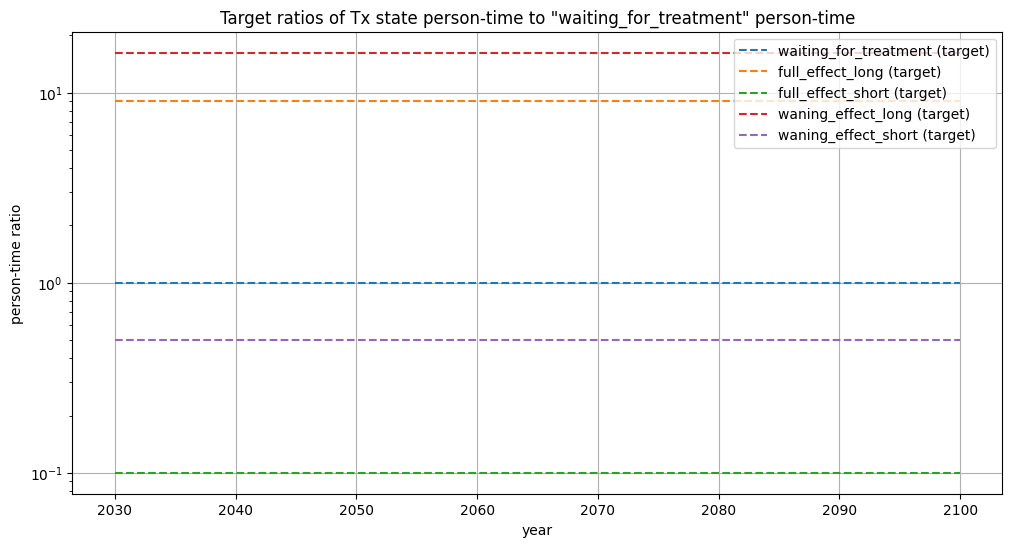

In [ ]:
def plot_treatment_state_targets(tx_state_durations, column, ax):
    """Plot horizontal lines for values in one column of the treatment
    state durations table.
    """
    existing_lines = ax.get_lines()
    if len(existing_lines) == 0:
        # Axes.hlines plots all lines in a single color by default, so if you
        # want different colors, you have to explicitly cycle through them 
        prop_cycle = plt.rcParams['axes.prop_cycle']
        colors = prop_cycle.by_key()['color']

    for i, state in enumerate(tx_state_durations.index):
        # Find color corresponding to state if there already exists a
        # line for that state
        for line in existing_lines:
            if state in line.get_label():
                color = line.get_color()
                break
        # If there were no existing lines, go to next color in cycle
        if len(existing_lines) == 0:
            color = colors[i % len(colors)]
        ax.hlines(tx_state_durations.at[state, column], 2030, 2100, color, '--', label=f'{state} (target)')
    return ax

fig, ax = plt.subplots(figsize=(12, 6))

ax = plot_treatment_state_targets(tx_state_durations, 'target_person_time_ratio', ax)
ax.set(
    xlabel='year',
    ylabel='person-time ratio',
    title='Target ratios of Tx state person-time to "waiting_for_treatment" person-time',
)
ax.grid(True)
ax.legend()
ax.semilogy()
plt.show()

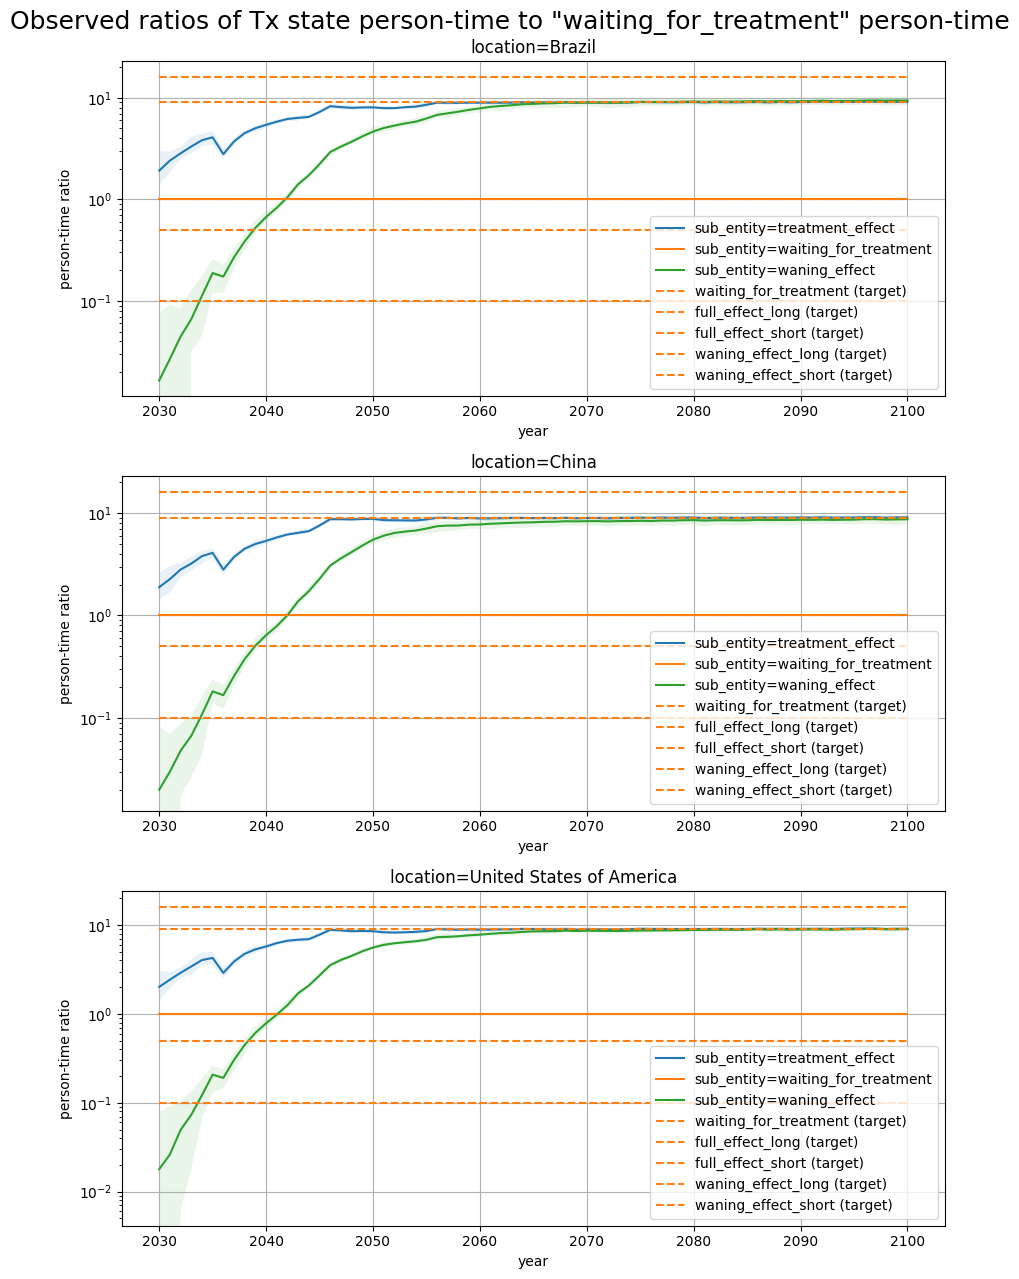

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    tx_person_time_ratios,
    'sub_entity',
    'location',
    ylabel='person-time ratio',
    suptitle='Observed ratios of Tx state person-time to "waiting_for_treatment" person-time',
    axes_width=9,
    axes_height=4,
)
for ax in fig.axes:
    ax = plot_treatment_state_targets(tx_state_durations, 'target_person_time_ratio', ax)
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
    ax.legend()
    ax.semilogy()
plt.show()

In [ ]:
tx_person_time_ratios.groupby(['event_year', 'sub_entity'], observed=True)['value'].describe()

count      mean       std       min  \
event_year sub_entity                                                   
2030       treatment_effect        75.0  1.942054  0.460157  1.296296   
           waiting_for_treatment   75.0  1.000000  0.000000  1.000000   
           waning_effect           75.0  0.018107  0.026696  0.000000   
2031       treatment_effect        75.0  2.367846  0.331362  1.662651   
           waiting_for_treatment   75.0  1.000000  0.000000  1.000000   
...                                 ...       ...       ...       ...   
2099       waiting_for_treatment   75.0  1.000000  0.000000  1.000000   
           waning_effect           75.0  9.031587  0.550186  7.383425   
2100       treatment_effect        75.0  9.085395  0.184403  8.666094   
           waiting_for_treatment   75.0  1.000000  0.000000  1.000000   
           waning_effect           75.0  9.035236  0.566189  7.701837   

                                       25%       50%       75%        max  
event_year sub_entity                                                      
2030       treatment_effect       1.600000  1.830189  2.158318   3.700000  
           waiting_for_treatment  1.000000  1.000000  1.000000   1.000000  
           waning_effect          0.000000  0.000000  0.032796   0.097561  
2031       treatment_effect       2.121958  2.342466  2.585430   3.344828  
           waiting_for_treatment  1.000000  1.000000  1.000000   1.000000  
...                                    ...       ...       ...        ...  
2099       waiting_for_treatment  1.000000  1.000000  1.000000   1.000000  
           waning_effect          8.794495  9.044583  9.339317  10.262571  
2100       treatment_effect       8.954888  9.086159  9.210700   9.496332  
           waiting_for_treatment  1.000000  1.000000  1.000000   1.000000  
           waning_effect          8.748980  9.057802  9.319261  10.456071  

[213 rows x 8 columns]

## Check values

In [ ]:
tx_person_time_ratios.query("sub_entity == 'waning_effect_long' and event_year>2060").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

In [ ]:
tx_person_time_ratios.query("sub_entity == 'full_effect_long' and event_year>2060").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

In [ ]:
# Compute implied durations from the ratios above
# Target durations are (9, 5)
12.576105 / .9 * .5, 8.641488 / .9 * .5

(6.986725, 4.800826666666667)

In [ ]:
ops.index_cols

['input_draw', 'scenario', 'location']

## Look at actual person-time instead of the ratio

In [ ]:
ops.describe(
    ops.stratify(
        person_time_treatment.query(
            "value > 0 and "
            "(sub_entity == 'waiting_for_treatment' or "
            " sub_entity.str.endswith('effect_long')) and event_year > 2050"
            # " and location == 'Spain'"
        ),
        ['event_year', 'sub_entity']
    )
)

count  \
event_year location                 scenario                   sub_entity                     
2051       Brazil                   bbbm_testing_and_treatment waiting_for_treatment   25.0   
           China                    bbbm_testing_and_treatment waiting_for_treatment   25.0   
           United States of America bbbm_testing_and_treatment waiting_for_treatment   25.0   
2052       Brazil                   bbbm_testing_and_treatment waiting_for_treatment   25.0   
           China                    bbbm_testing_and_treatment waiting_for_treatment   25.0   
...                                                                                     ...   
2099       China                    bbbm_testing_and_treatment waiting_for_treatment   25.0   
           United States of America bbbm_testing_and_treatment waiting_for_treatment   25.0   
2100       Brazil                   bbbm_testing_and_treatment waiting_for_treatment   25.0   
           China                    bbbm_testing_and_treatment waiting_for_treatment   25.0   
           United States of America bbbm_testing_and_treatment waiting_for_treatment   25.0   

                                                                                             mean  \
event_year location                 scenario                   sub_entity                           
2051       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  1118.877700   
           China                    bbbm_testing_and_treatment waiting_for_treatment   980.333470   
           United States of America bbbm_testing_and_treatment waiting_for_treatment   598.584422   
2052       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  1181.462779   
           China                    bbbm_testing_and_treatment waiting_for_treatment  1009.473402   
...                                                                                           ...   
2099       China                    bbbm_testing_and_treatment waiting_for_treatment  1859.275127   
           United States of America bbbm_testing_and_treatment waiting_for_treatment  1166.932676   
2100       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  2234.745736   
           China                    bbbm_testing_and_treatment waiting_for_treatment  1876.954415   
           United States of America bbbm_testing_and_treatment waiting_for_treatment  1176.180917   

                                                                                            std  \
event_year location                 scenario                   sub_entity                         
2051       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  39.066205   
           China                    bbbm_testing_and_treatment waiting_for_treatment  45.731407   
           United States of America bbbm_testing_and_treatment waiting_for_treatment  24.852294   
2052       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  42.932069   
           China                    bbbm_testing_and_treatment waiting_for_treatment  47.400192   
...                                                                                         ...   
2099       China                    bbbm_testing_and_treatment waiting_for_treatment  85.591017   
           United States of America bbbm_testing_and_treatment waiting_for_treatment  47.319367   
2100       Brazil                   bbbm_testing_and_treatment waiting_for_treatment  64.924901   
           China                    bbbm_testing_and_treatment waiting_for_treatment  86.455268   
           United States of America bbbm_testing_and_treatment waiting_for_treatment  40.101955   

                                                                                              min  \
event_year location                 scenario                   sub_entity                           
2051       Brazil                   bbbm_testi

In [ ]:
9721.296427 / 1129.481287

8.606868071998433

In [ ]:
13995.099904 / 1129.481287

12.390731980316554

# Check #4 (duration of start treatment/waiting for treatment)

“In treatment/waiting for treatment” duration is accurate (use
person-time ratios between states?)

This duration is supposed to be 6 months for all simulants.

## Strategy

To compute the average duration of each state, divide the total
person-time of that state by the number of simulants entering that
state, i.e., the the sum of transition counts where it's the `to_state`.

Alternatively, compute the average duration by dividing the total
person-time by the number of simulants *exiting* the state, i.e., the
sum of transition counts where it's the `from_state`.

## Results

I'm not sure how closely either of these strategies should match the
actual duration... Neither takes deaths into account, and I stratified
the calculations by year, which seems weird because some of the
durations are much longer than a year.

Nevertheless, the observed average durations for 4 out of 5 of the
states eventually converge to a value pretty close to the specified
duration, using either of the above two methods. The fifth state,
`'waning_effect_long'`, converges to different values in each of the
above two methods, neither of which is particularly close to the target
duration of 9 years. We think this is probably due to mortality.

In [ ]:
person_time_treatment

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,no_effect_after_treatment,0.000000,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,no_effect_never_treated,0.000000,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,susceptible_to_treatment,0.000000,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,treatment_effect,0.000000,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,person_time,baseline,Female,waiting_for_treatment,0.000000,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
3199495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,no_effect_never_treated,185.363450,Brazil
3199496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,susceptible_to_treatment,13787.154004,Brazil
3199497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,treatment_effect,0.000000,Brazil
3199498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,waiting_for_treatment,0.000000,Brazil


In [ ]:
treatment_transitions.query("value>0")

,age_group,artifact_path,entity,entity_type,event_year,input_draw,location,measure,scenario,sex,sub_entity,value,from_state,to_state
475250,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_no_effect_never_tr...,27.0,susceptible_to_treatment,no_effect_never_treated
475251,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,United States of America,transition_count,bbbm_testing_and_treatment,Female,susceptible_to_treatment_to_waiting_for_treatment,1.0,susceptible_to_treatment,waiting_for_treatment
475255,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,United States of America,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_no_effect_never_tr...,10.0,susceptible_to_treatment,no_effect_never_treated
475256,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,United States of America,transition_count,bbbm_testing_and_treatment,Male,susceptible_to_treatment_to_waiting_for_treatment,2.0,susceptible_to_treatment,waiting_for_treatment
475258,65_to_69,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2027,1,United States of America,transition_count,bbbm_testing_and_treatment,Male,waiting_for_treatment_to_treatment_effect,1.0,waiting_for_treatment,treatment_effect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888729,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,245,Brazil,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,12.0,waning_effect,no_effect_after_treatment
888734,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,248,Brazil,transition_count,bbbm_testing_and_treatment,Female,waning_effect_to_no_effect_after_treatment,14.0,waning_effect,no_effect_after_treatment
888739,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,248,Brazil,transition_count,bbbm_testing_and_treatment,Male,waning_effect_to_no_effect_after_treatment,3.0,waning_effect,no_effect_after_treatment
888744,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,Brazil,transition_count,bbbm_testing_and_treatment,Female,waning_effect_to_no_effect_after_treatment,85.0,waning_effect,no_effect_after_treatment


In [ ]:
person_time_treatment.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity       category
value             float64
location         category
dtype: object

In [ ]:
treatment_transitions.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
location         category
measure          category
scenario         category
sex              category
sub_entity       category
value             float64
from_state       category
to_state         category
dtype: object

In [ ]:
tx_state_mean_durations_incoming = ops.ratio(
    person_time_treatment.assign(to_state=lambda df: df['sub_entity']),
    treatment_transitions.query("value>0"),
    strata=['event_year', 'to_state'],
    prefilter_query=(
        "scenario=='bbbm_testing_and_treatment' and event_year >= 2030"
    )
)
tx_state_mean_durations_incoming

,event_year,to_state,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,Brazil,NaN,person_time,transition_count,1
1,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,China,NaN,person_time,transition_count,1
2,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,United States of America,NaN,person_time,transition_count,1
3,2030,no_effect_after_treatment,6,bbbm_testing_and_treatment,Brazil,NaN,person_time,transition_count,1
4,2030,no_effect_after_treatment,6,bbbm_testing_and_treatment,China,NaN,person_time,transition_count,1
...,...,...,...,...,...,...,...,...,...
31945,2100,waning_effect,248,bbbm_testing_and_treatment,China,5.999461,person_time,transition_count,1
31946,2100,waning_effect,248,bbbm_testing_and_treatment,United States of America,6.154103,person_time,transition_count,1
31947,2100,waning_effect,249,bbbm_testing_and_treatment,Brazil,7.057999,person_time,transition_count,1
31948,2100,waning_effect,249,bbbm_testing_and_treatment,China,6.674548,person_time,transition_count,1


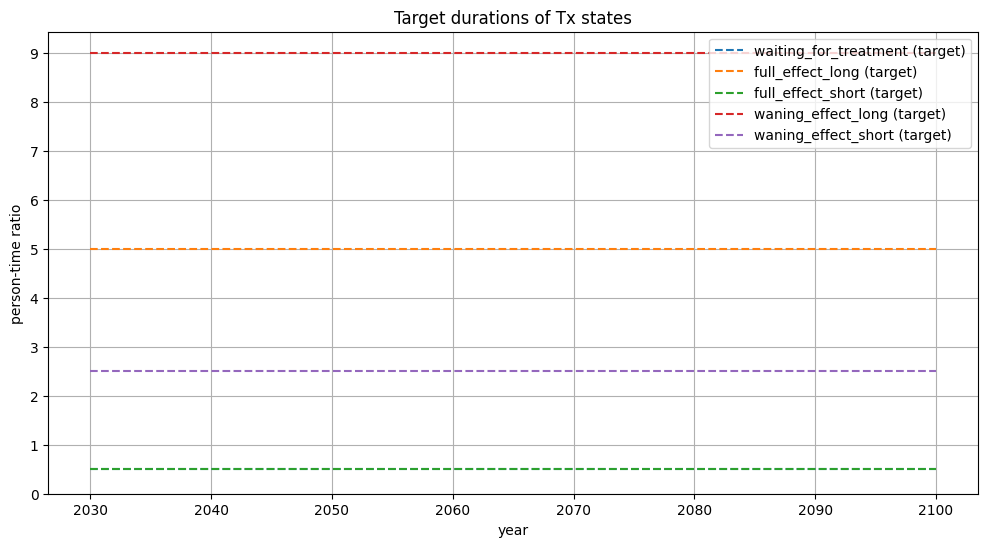

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax = plot_treatment_state_targets(tx_state_durations, 'duration', ax)
ax.set(
    xlabel='year',
    ylabel='person-time ratio',
    title='Target durations of Tx states',
)
ax.grid(True)
ax.legend()
ax.set(yticks=range(0,10))
# ax.semilogy()
plt.show()

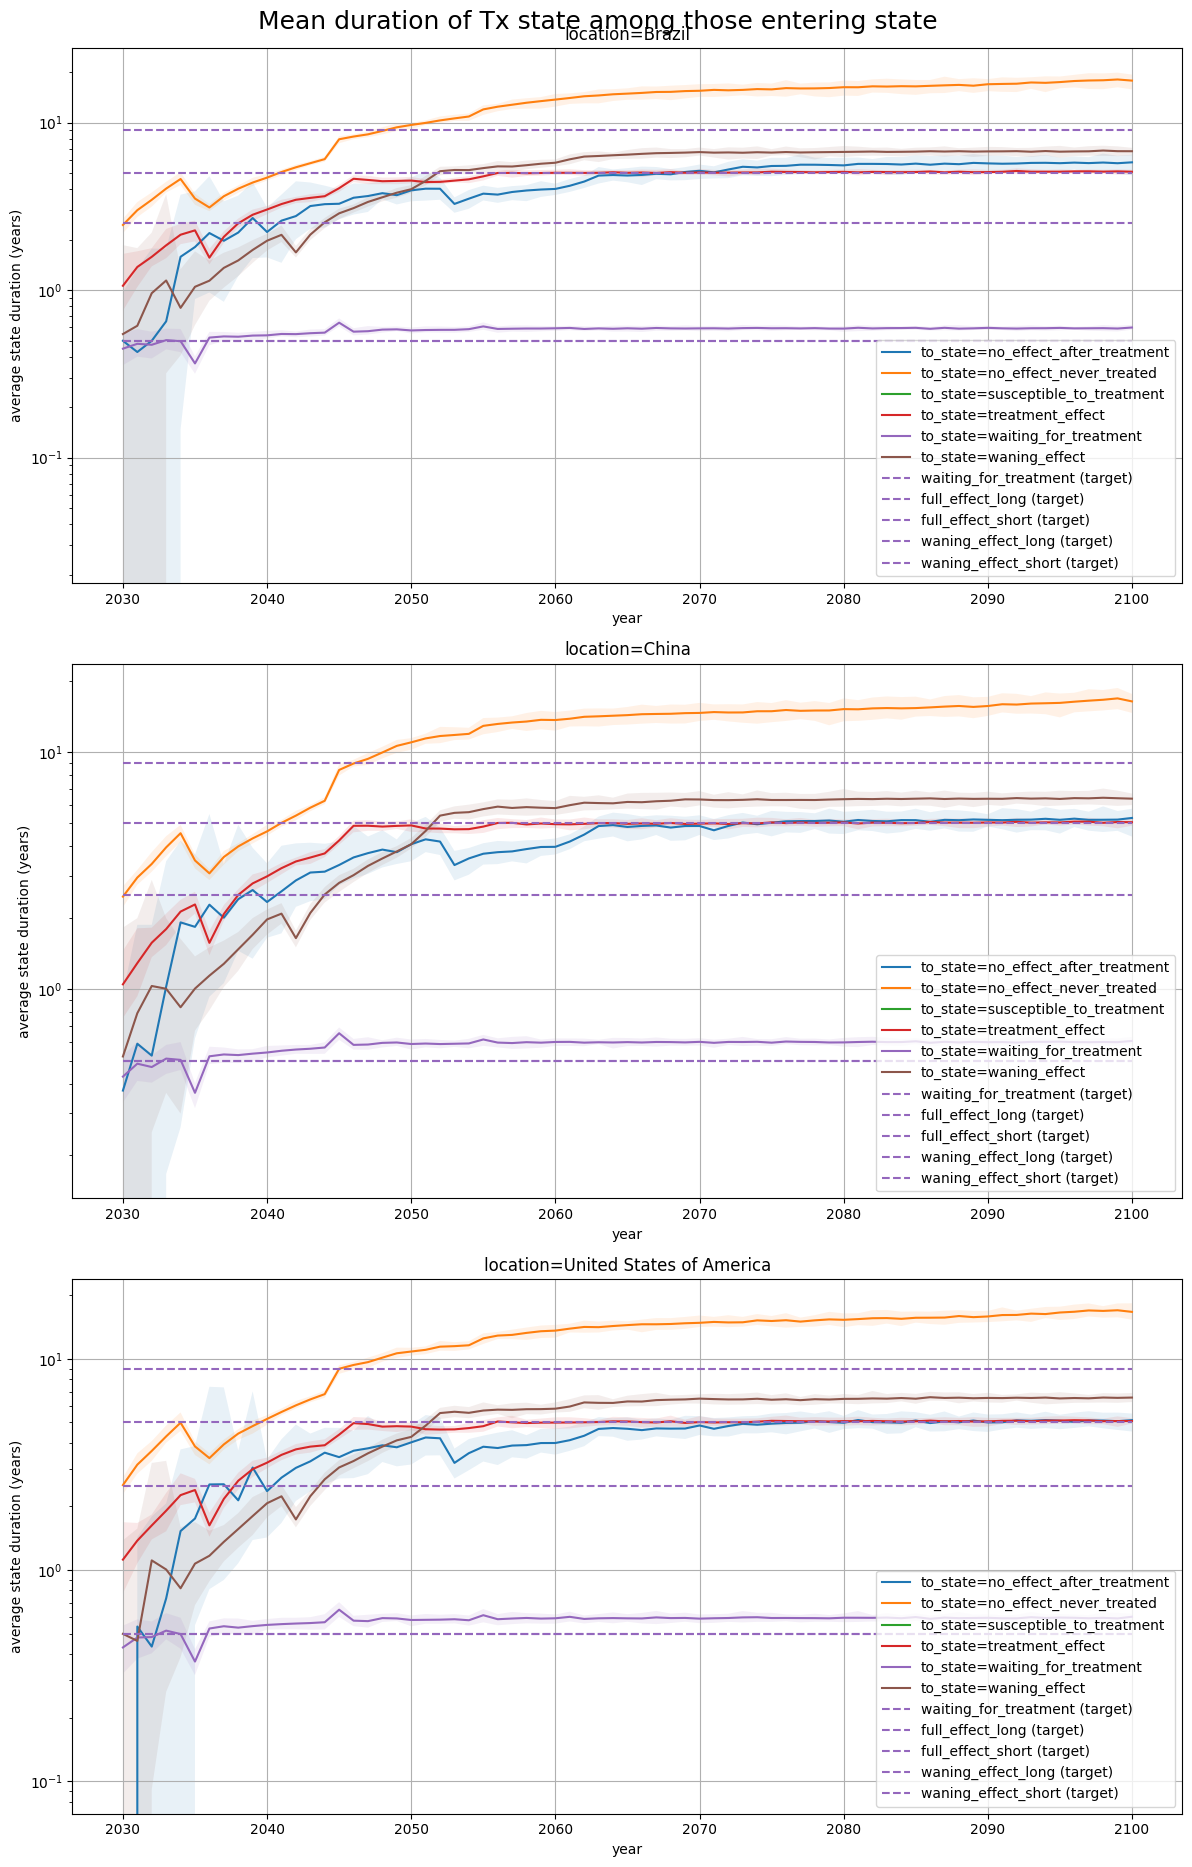

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    tx_state_mean_durations_incoming,
    'to_state',
    'location',
    ylabel='average state duration (years)',
    suptitle="Mean duration of Tx state among those entering state",
    # axes_width=9,
    # axes_height=4,
)
for ax in fig.axes:
    ax = plot_treatment_state_targets(tx_state_durations, 'duration', ax)
    ax.legend()
    ax.grid(True)
    ax.semilogy()
plt.show()

In [ ]:
tx_state_mean_durations_outgoing = ops.ratio(
    person_time_treatment.assign(from_state=lambda df: df['sub_entity']),
    treatment_transitions.query("value>0"),
    strata=['event_year', 'from_state'],
    prefilter_query=(
        "scenario=='bbbm_testing_and_treatment' and event_year >= 2030"
    )
)
tx_state_mean_durations_outgoing

,event_year,from_state,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,Brazil,NaN,person_time,transition_count,1
1,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,China,NaN,person_time,transition_count,1
2,2030,no_effect_after_treatment,1,bbbm_testing_and_treatment,United States of America,NaN,person_time,transition_count,1
3,2030,no_effect_after_treatment,6,bbbm_testing_and_treatment,Brazil,NaN,person_time,transition_count,1
4,2030,no_effect_after_treatment,6,bbbm_testing_and_treatment,China,NaN,person_time,transition_count,1
...,...,...,...,...,...,...,...,...,...
31945,2100,waning_effect,248,bbbm_testing_and_treatment,China,21.419352,person_time,transition_count,1
31946,2100,waning_effect,248,bbbm_testing_and_treatment,United States of America,20.578541,person_time,transition_count,1
31947,2100,waning_effect,249,bbbm_testing_and_treatment,Brazil,17.265508,person_time,transition_count,1
31948,2100,waning_effect,249,bbbm_testing_and_treatment,China,18.755207,person_time,transition_count,1


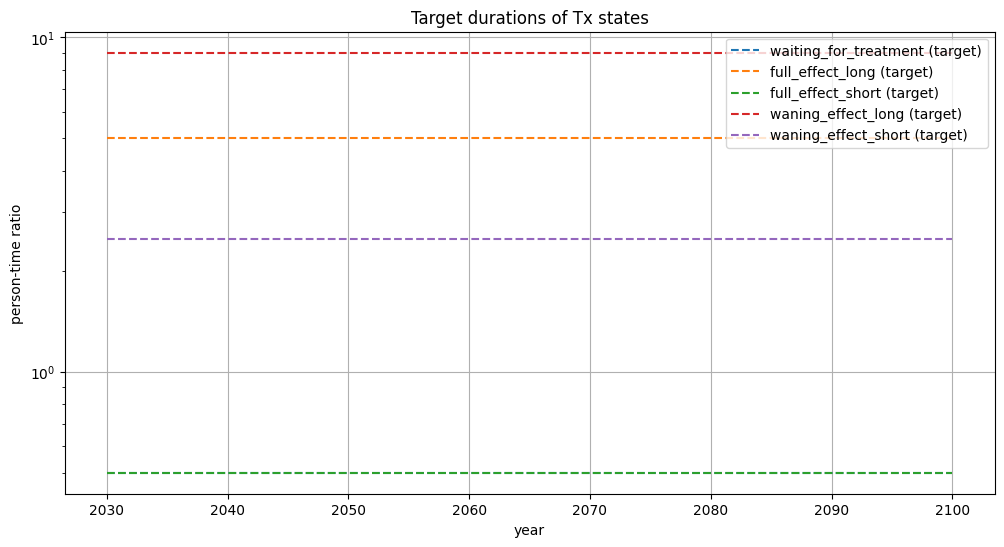

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax = plot_treatment_state_targets(tx_state_durations, 'duration', ax)
ax.set(
    xlabel='year',
    ylabel='person-time ratio',
    title='Target durations of Tx states',
)
ax.grid(True)
ax.legend()
ax.set(yticks=range(0,10))
ax.semilogy()
plt.show()

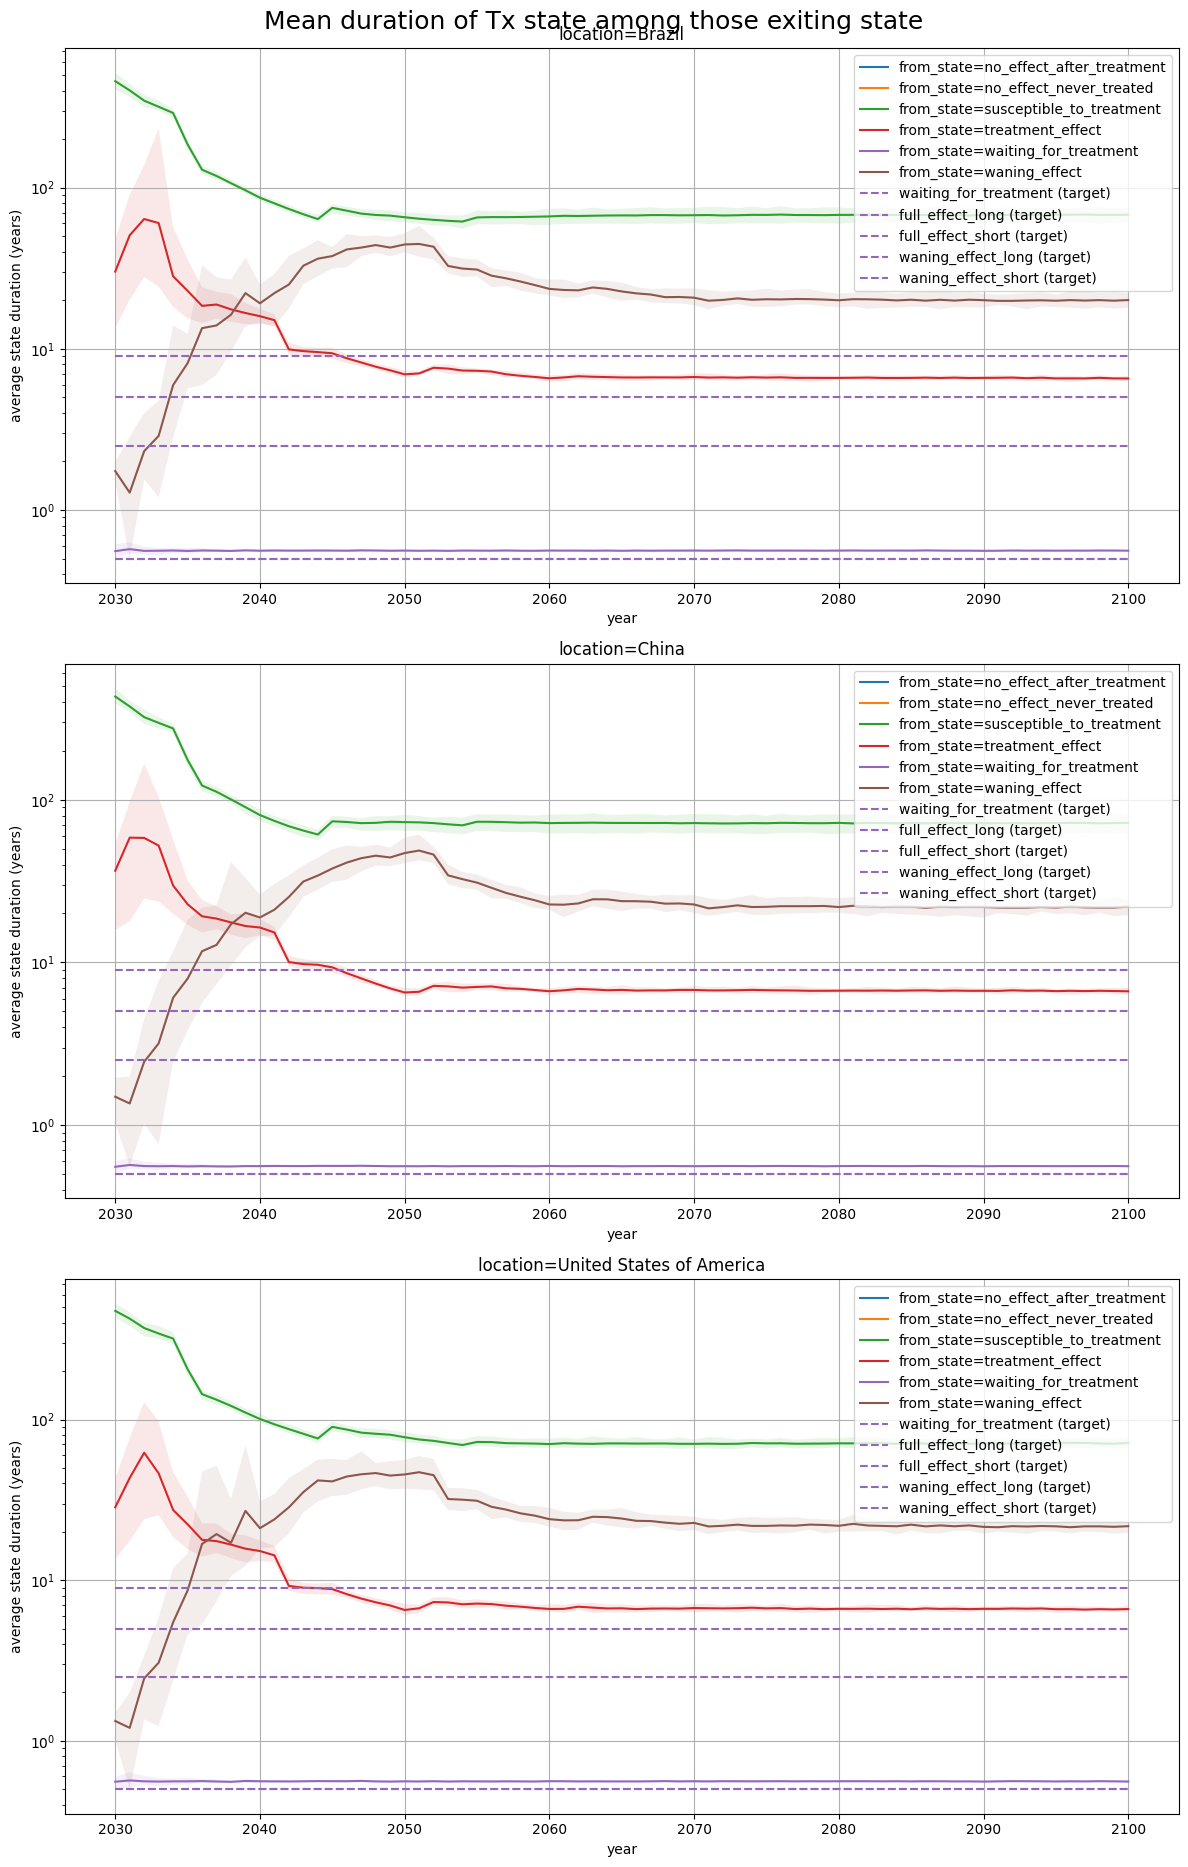

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    tx_state_mean_durations_outgoing,
    'from_state',
    'location',
    ylabel='average state duration (years)',
    suptitle="Mean duration of Tx state among those exiting state",
)
for ax in fig.axes:
    ax = plot_treatment_state_targets(tx_state_durations, 'duration', ax)
    ax.legend()
    ax.grid(True)
    ax.semilogy()
plt.show()

## Check value of `waning_effect_long`

It's not close to 9 years in either graph.

In [ ]:
tx_state_mean_durations_incoming.query("to_state == 'waning_effect_long' and event_year > 2050").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

In [ ]:
tx_state_mean_durations_outgoing.query("from_state == 'waning_effect_long' and event_year > 2050").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

## By contrast, check the value of `full_effect_long`

It **is** close to 5 years in _both_ graphs.

In [ ]:
tx_state_mean_durations_incoming.query("to_state == 'full_effect_long' and event_year > 2050").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

In [ ]:
tx_state_mean_durations_outgoing.query("from_state == 'full_effect_long' and event_year > 2050").value.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: value, dtype: float64

# Check #5 (Interactive sim)

I'm planning to do the interactive sim in another notebook.

# Check #6 (hazard ratio)

Check hazard ratios for simulants who begin treatment and those who
transition to *No treatment effect* (Check hazard ratio of treated to
not treated for hazard rate from BBBM to MCI)

## I think I can't check this in the outputs because neither cause transitions nor cause state person-time is stratified by treatment status

In [ ]:
person_time_cause_states = load_sim_output(
    'person_time_alzheimers_disease_and_other_dementias',
)
print_memory_usage(person_time_cause_states)
person_time_cause_states

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
268.762679 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,treatment,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,person_time,baseline,Female,alzheimers_blood_based_biomarker_state,no_effect_after_treatment,0.000000,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,person_time,baseline,Female,alzheimers_blood_based_biomarker_state,no_effect_never_treated,0.000000,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,person_time,baseline,Female,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,0.000000,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,person_time,baseline,Female,alzheimers_blood_based_biomarker_state,treatment_effect,0.000000,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,person_time,baseline,Female,alzheimers_blood_based_biomarker_state,waiting_for_treatment,0.000000,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9598495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state,no_effect_never_treated,26.409309,Brazil
9598496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state,susceptible_to_treatment,3614.587269,Brazil
9598497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state,treatment_effect,0.000000,Brazil
9598498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,person_time,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state,waiting_for_treatment,0.000000,Brazil


In [ ]:
person_time_cause_states.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity       category
treatment        category
value             float64
location         category
dtype: object

In [ ]:
person_time_cause_states.treatment.unique()

['no_effect_after_treatment', 'no_effect_never_treated', 'susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']
Categories (6, object): ['no_effect_after_treatment', 'no_effect_never_treated', 'susceptible_to_treatment', 'treatment_effect', 'waiting_for_treatment', 'waning_effect']

In [ ]:
person_time_cause_states.sub_entity.unique()

['alzheimers_blood_based_biomarker_state', 'alzheimers_disease_state', 'alzheimers_mild_cognitive_impairment_state']
Categories (3, object): ['alzheimers_blood_based_biomarker_state', 'alzheimers_disease_state', 'alzheimers_mild_cognitive_impairment_state']

In [ ]:
transition_count_cause_states = (
    load_sim_output(
        'transition_count_alzheimers_disease_and_other_dementias',
    )
    # Display memory usage of loaded dataframe before adding columns
    .pipe(lambda df: print_memory_usage(df) or df)
    # Add columns for from and to state
    .pipe(lambda df: df.join(
        cleaning.extract_transition_states(df, 'sub_entity'))
    )
    # Display memory usage of loaded dataframe after adding columns
    .pipe(lambda df: print_memory_usage(df) or df)
    # Convert the new columns to Categoricals
    .pipe(convert_to_categorical)
)
print_memory_usage(transition_count_cause_states)
transition_count_cause_states

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
179.176677 MB
1375.789677 MB
191.975267 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,treatment,value,location,from_state,to_state
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,transition_count,baseline,Female,alzheimers_blood_based_biomarker_state_to_alzh...,no_effect_after_treatment,0.0,United States of America,alzheimers_blood_based_biomarker_state,alzheimers_mild_cognitive_impairment_state
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,transition_count,baseline,Female,alzheimers_blood_based_biomarker_state_to_alzh...,no_effect_never_treated,0.0,United States of America,alzheimers_blood_based_biomarker_state,alzheimers_mild_cognitive_impairment_state
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,transition_count,baseline,Female,alzheimers_blood_based_biomarker_state_to_alzh...,susceptible_to_treatment,0.0,United States of America,alzheimers_blood_based_biomarker_state,alzheimers_mild_cognitive_impairment_state
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,transition_count,baseline,Female,alzheimers_blood_based_biomarker_state_to_alzh...,treatment_effect,0.0,United States of America,alzheimers_blood_based_biomarker_state,alzheimers_mild_cognitive_impairment_state
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2022,1,transition_count,baseline,Female,alzheimers_blood_based_biomarker_state_to_alzh...,waiting_for_treatment,0.0,United States of America,alzheimers_blood_based_biomarker_state,alzheimers_mild_cognitive_impairment_state
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6398995,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state_to_...,no_effect_never_treated,9.0,Brazil,alzheimers_mild_cognitive_impairment_state,alzheimers_disease_state
6398996,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state_to_...,susceptible_to_treatment,848.0,Brazil,alzheimers_mild_cognitive_impairment_state,alzheimers_disease_state
6398997,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state_to_...,treatment_effect,0.0,Brazil,alzheimers_mild_cognitive_impairment_state,alzheimers_disease_state
6398998,95_plus,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_and_other_dementias,cause,2100,249,transition_count,bbbm_testing_and_treatment,Male,alzheimers_mild_cognitive_impairment_state_to_...,waiting_for_treatment,0.0,Brazil,alzheimers_mild_cognitive_impairment_state,alzheimers_disease_state


In [ ]:
transition_count_cause_states.dtypes

age_group        category
artifact_path    category
entity           category
entity_type      category
event_year          int16
input_draw          int64
measure          category
scenario         category
sex              category
sub_entity       category
treatment        category
value             float64
location         category
from_state       category
to_state         category
dtype: object

In [ ]:
transition_count_cause_states.from_state.unique()

['alzheimers_blood_based_biomarker_state', 'alzheimers_mild_cognitive_impairment_state']
Categories (2, object): ['alzheimers_blood_based_biomarker_state', 'alzheimers_mild_cognitive_impairment_state']

In [ ]:
incidence_rates_by_treatment = ops.ratio(
    transition_count_cause_states,
    person_time_cause_states.rename(columns={'sub_entity': 'from_state'}),
    strata=['event_year', 'from_state', 'treatment'],
    numerator_broadcast='to_state', # doesn't actually broadcast, just records it
    measure='transition_rate',
    dropna=True,
)
incidence_rates_by_treatment

,event_year,from_state,treatment,to_state,input_draw,scenario,location,value,measure,numerator_measure,denominator_measure,multiplier
0,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,alzheimers_mild_cognitive_impairment_state,1,baseline,Brazil,0.139972,transition_rate,transition_count,person_time,1
1,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,alzheimers_mild_cognitive_impairment_state,1,baseline,China,0.140249,transition_rate,transition_count,person_time,1
2,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,alzheimers_mild_cognitive_impairment_state,1,baseline,United States of America,0.142225,transition_rate,transition_count,person_time,1
3,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,alzheimers_mild_cognitive_impairment_state,1,bbbm_testing,Brazil,0.139972,transition_rate,transition_count,person_time,1
4,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,alzheimers_mild_cognitive_impairment_state,1,bbbm_testing,China,0.140249,transition_rate,transition_count,person_time,1
...,...,...,...,...,...,...,...,...,...,...,...,...
99646,2100,alzheimers_mild_cognitive_impairment_state,waning_effect,alzheimers_disease_state,248,bbbm_testing_and_treatment,China,0.255734,transition_rate,transition_count,person_time,1
99647,2100,alzheimers_mild_cognitive_impairment_state,waning_effect,alzheimers_disease_state,248,bbbm_testing_and_treatment,United States of America,0.271674,transition_rate,transition_count,person_time,1
99648,2100,alzheimers_mild_cognitive_impairment_state,waning_effect,alzheimers_disease_state,249,bbbm_testing_and_treatment,Brazil,0.258894,transition_rate,transition_count,person_time,1
99649,2100,alzheimers_mild_cognitive_impairment_state,waning_effect,alzheimers_disease_state,249,bbbm_testing_and_treatment,China,0.251420,transition_rate,transition_count,person_time,1


## Investigate infinite transition rates between disease states

My plotting code below initially failed with `FloatingPointError:
invalid value encountered in subtract` in the `lower` function, due to
infinities in the transition rates data.

According to the engineers, we may be getting 0 person-time in some
strata where counts are nonzero because person-time is recorded at the
beginning of a time step, while transition counts are recorded at the
end. So for example, if someone starts in preclinical, in the "waiting
for treatment" state, then transitions to MCI and to "full effect long"
on the same time step, then they would have their person-time recorded
in the (preclinical, waiting for treatment) stratum, but their disease
transition recorded in the (preclinical- > MCI, full effect long)
stratum.

The engineers said there was a bugfix in model 7.2 that *might* address
this problem, so I'll try this again there...

In [ ]:
# 2026-02-05: Why do I have to explicitly put this in a context manager all of a sudden?
with np.errstate(invalid='ignore'):
    print(incidence_rates_by_treatment.value.describe())

count    9.965100e+04
mean              inf
std               NaN
min      0.000000e+00
25%      1.451429e-01
50%      1.759460e-01
75%      2.522678e-01
max               inf
Name: value, dtype: float64


In [ ]:
inf = np.isinf(incidence_rates_by_treatment.value)
print(inf.sum(), "rows with infinite values")
incidence_rates_by_treatment.loc[inf]#.query("from_state=='alzheimers_blood_based_biomarker_state'")

33 rows with infinite values


,event_year,from_state,treatment,to_state,input_draw,scenario,location,value,measure,numerator_measure,denominator_measure,multiplier
2625,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,1,bbbm_testing_and_treatment,Brazil,inf,transition_rate,transition_count,person_time,1
2626,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,1,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
2627,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,1,bbbm_testing_and_treatment,United States of America,inf,transition_rate,transition_count,person_time,1
2628,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,199,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
2629,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,204,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
2630,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,219,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
2631,2027,alzheimers_blood_based_biomarker_state,treatment_effect,alzheimers_mild_cognitive_impairment_state,245,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
4846,2030,alzheimers_blood_based_biomarker_state,no_effect_after_treatment,alzheimers_mild_cognitive_impairment_state,183,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1
5878,2031,alzheimers_blood_based_biomarker_state,no_effect_after_treatment,alzheimers_mild_cognitive_impairment_state,172,bbbm_testing_and_treatment,Brazil,inf,transition_rate,transition_count,person_time,1
5879,2031,alzheimers_blood_based_biomarker_state,no_effect_after_treatment,alzheimers_mild_cognitive_impairment_state,172,bbbm_testing_and_treatment,China,inf,transition_rate,transition_count,person_time,1


In [ ]:
transition_count_cause_states.query(
    "scenario=='bbbm_testing_and_treatment'"
    " and event_year==2044 and from_state=='alzheimers_blood_based_biomarker_state'"
    " and input_draw==499 and treatment=='full_effect_long'"
    " and age_group in @treatment_eligible_age_groups"
)

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,treatment,value,location,from_state,to_state


In [ ]:
person_time_cause_states.query(
    "scenario=='bbbm_testing_and_treatment'"
    " and event_year==2030 and sub_entity=='alzheimers_blood_based_biomarker_state'"
    " and input_draw==2 and treatment=='full_effect_long'"
    " and age_group in @treatment_eligible_age_groups"
)

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,treatment,value,location


## Plot disease transition rates stratified by treatment status, filtering out $\infty$

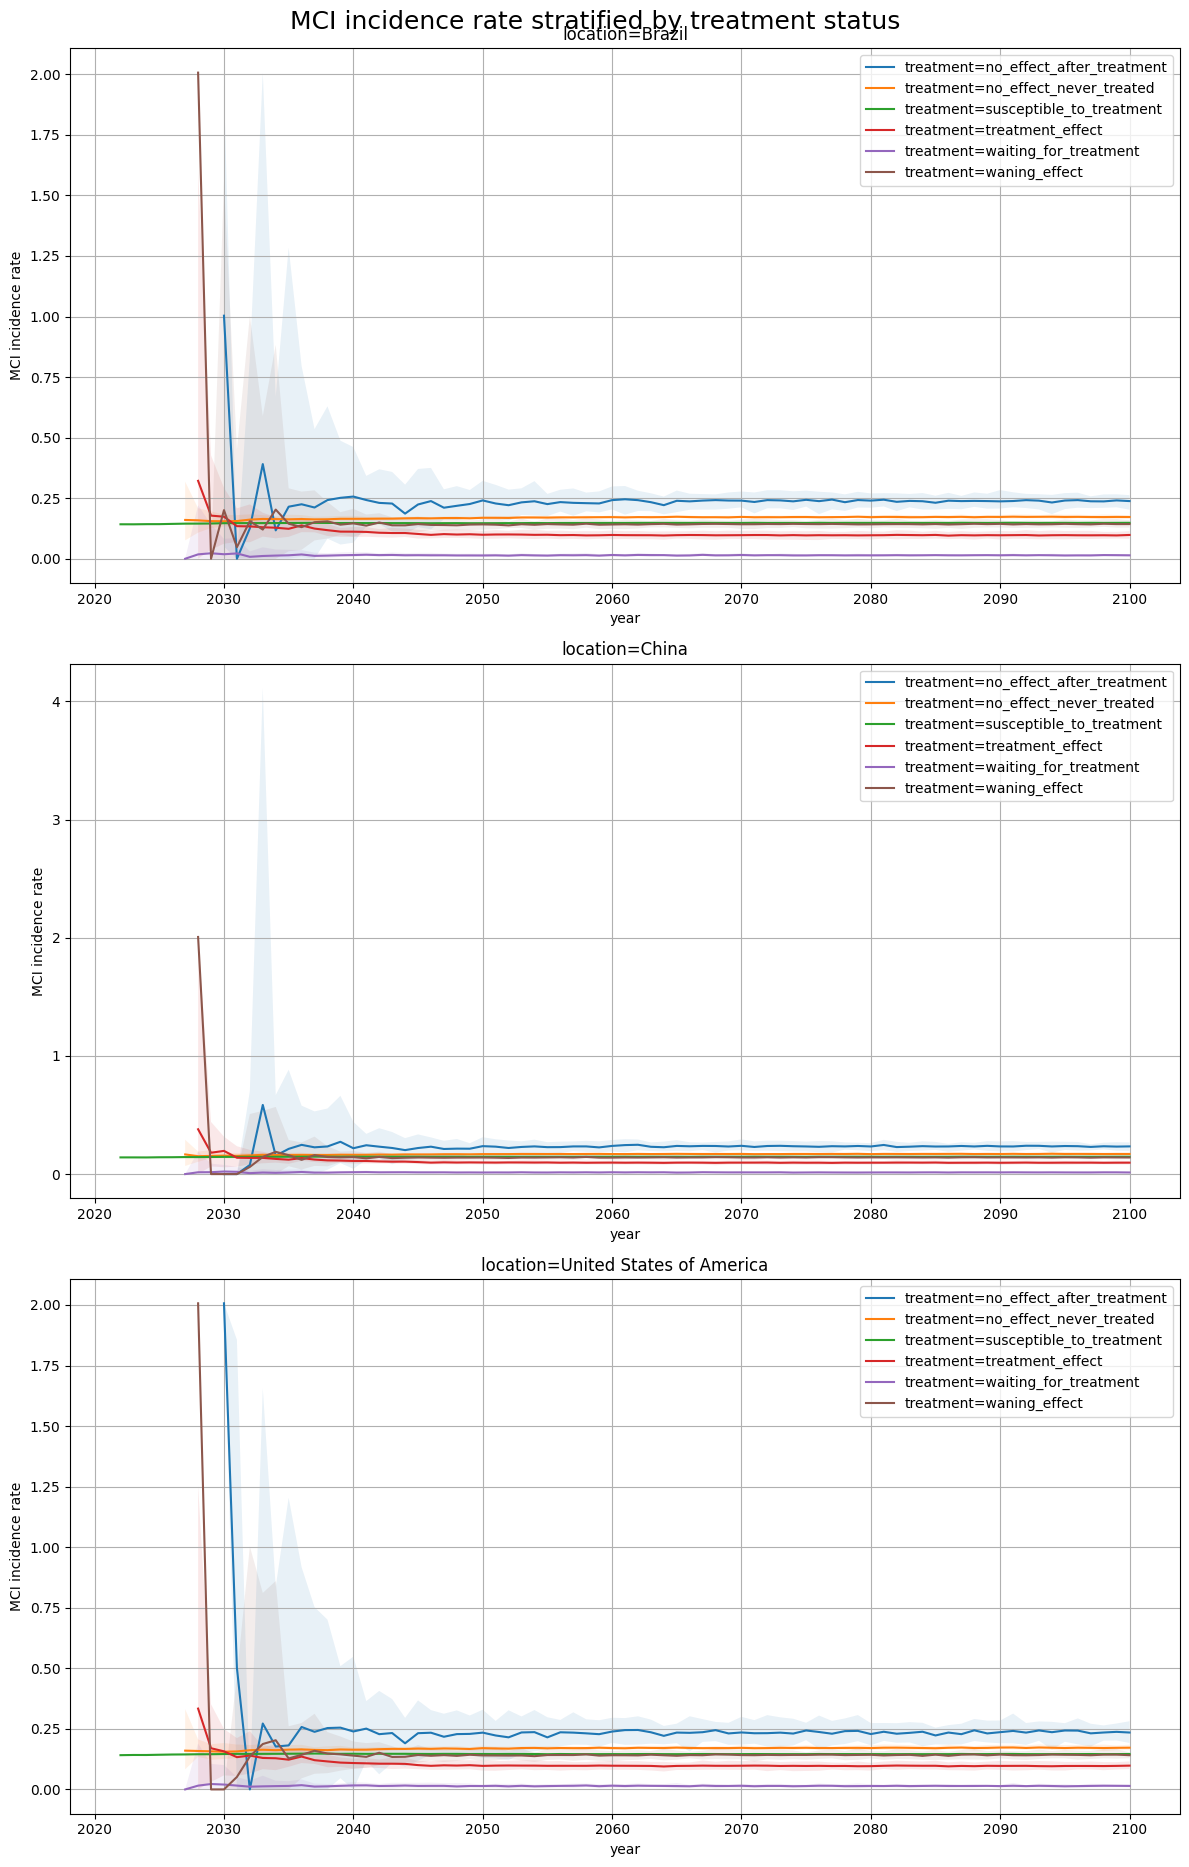

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    # NOTE: Without filtering infinities out, the `lower` method fails
    # with "FloatingPointError: invalid value encountered in subtract"
    incidence_rates_by_treatment.loc[~inf].query("from_state=='alzheimers_blood_based_biomarker_state'"),
    'treatment',
    'location',
    ylabel='MCI incidence rate',
    suptitle='MCI incidence rate stratified by treatment status',
    # uncertainty=False,
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()
plt.show()

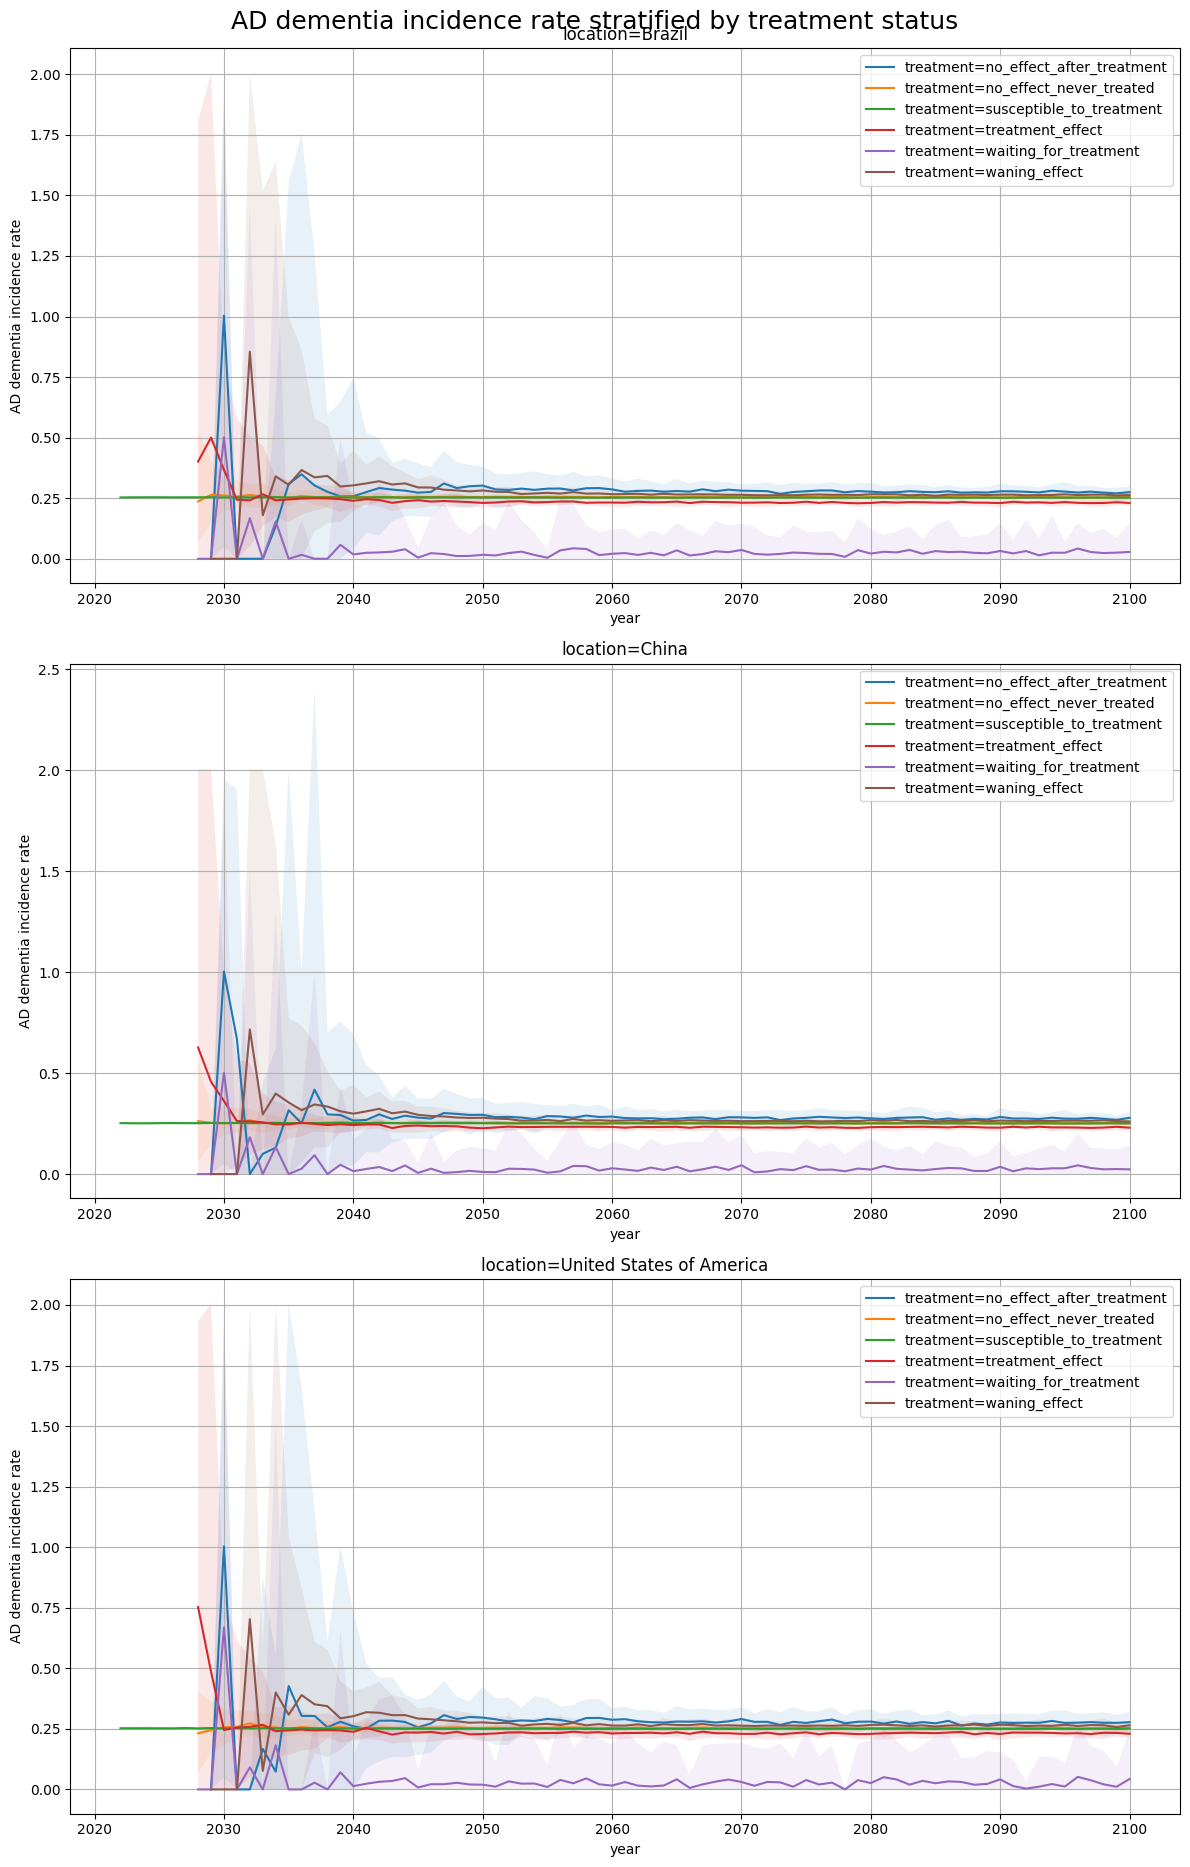

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    # NOTE: Without filtering infinities out, the `lower` method fails
    # with "FloatingPointError: invalid value encountered in subtract"
    incidence_rates_by_treatment.loc[~inf].query("from_state=='alzheimers_mild_cognitive_impairment_state'"),
    'treatment',
    'location',
    ylabel='AD dementia incidence rate',
    suptitle='AD dementia incidence rate stratified by treatment status',
    # uncertainty=False,
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()
plt.show()

## Compute hazard ratio

In [ ]:
hazard_ratio = ops.ratio(
    incidence_rates_by_treatment,
    incidence_rates_by_treatment.query("treatment=='susceptible_to_treatment'"),
    strata=['event_year', 'from_state'],
    numerator_broadcast=['treatment'],
    # prefilter_query="from_state=='alzheimers_blood_based_biomarker_state'",
)
hazard_ratio

,event_year,from_state,treatment,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,1,baseline,Brazil,1.000000,transition_rate,transition_rate,1
1,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,1,baseline,China,1.000000,transition_rate,transition_rate,1
2,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,1,baseline,United States of America,1.000000,transition_rate,transition_rate,1
3,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,1,bbbm_testing,Brazil,1.000000,transition_rate,transition_rate,1
4,2022,alzheimers_blood_based_biomarker_state,susceptible_to_treatment,1,bbbm_testing,China,1.000000,transition_rate,transition_rate,1
...,...,...,...,...,...,...,...,...,...,...
99646,2100,alzheimers_mild_cognitive_impairment_state,no_effect_never_treated,249,bbbm_testing_and_treatment,United States of America,1.006908,transition_rate,transition_rate,1
99647,2100,alzheimers_mild_cognitive_impairment_state,susceptible_to_treatment,249,bbbm_testing_and_treatment,United States of America,1.000000,transition_rate,transition_rate,1
99648,2100,alzheimers_mild_cognitive_impairment_state,treatment_effect,249,bbbm_testing_and_treatment,United States of America,0.950687,transition_rate,transition_rate,1
99649,2100,alzheimers_mild_cognitive_impairment_state,waiting_for_treatment,249,bbbm_testing_and_treatment,United States of America,0.396834,transition_rate,transition_rate,1


In [ ]:
with np.errstate(invalid='ignore'):
    print(hazard_ratio.value.describe())

count    9.965100e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.642213e-01
50%      1.000000e+00
75%      1.047422e+00
max               inf
Name: value, dtype: float64


In [ ]:
inf_ratio = np.isinf(hazard_ratio.value)
print(inf_ratio.sum(), "rows with infinite values")

33 rows with infinite values


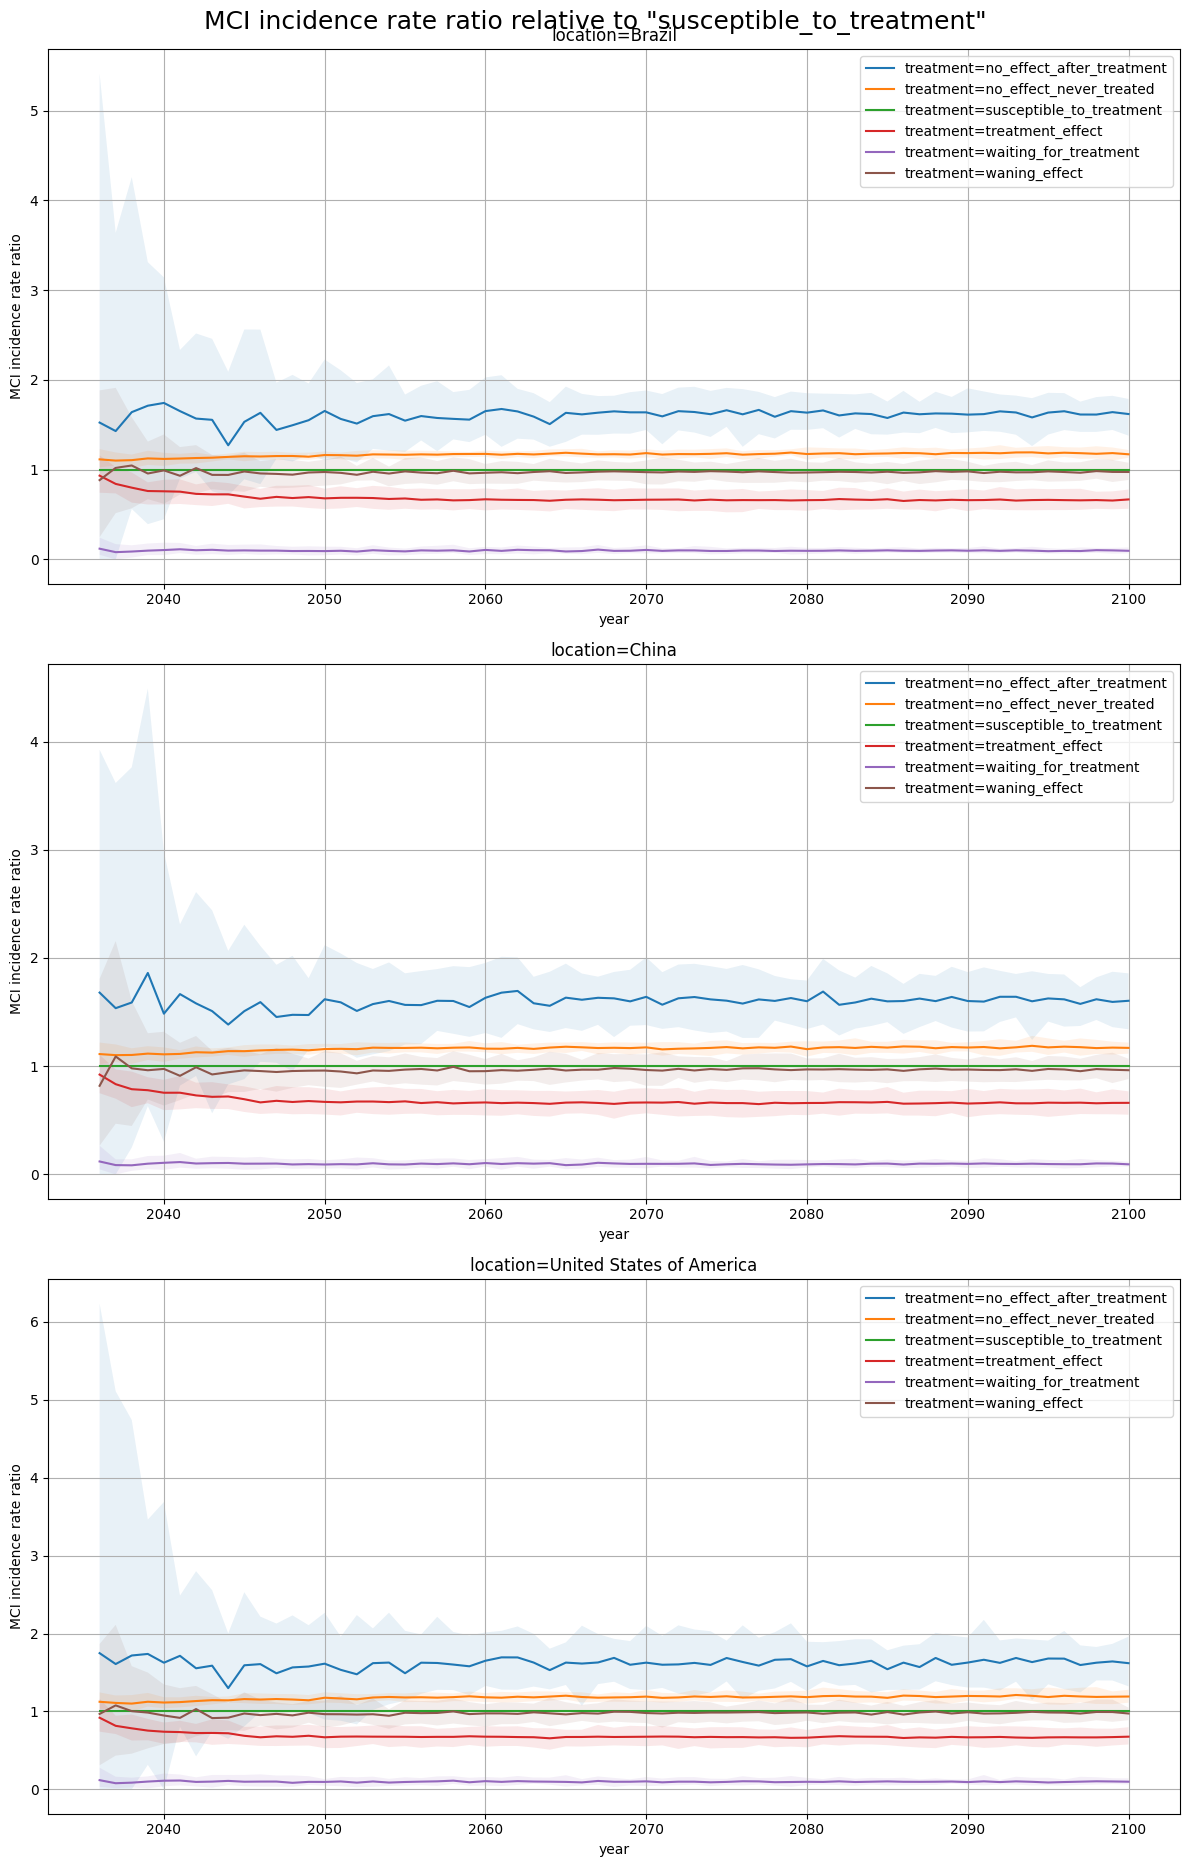

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    # NOTE: Without filtering infinities out, the `lower` method fails
    # with "FloatingPointError: invalid value encountered in subtract"
    hazard_ratio.loc[~inf_ratio].query(
        "scenario=='bbbm_testing_and_treatment'"
        " and from_state=='alzheimers_blood_based_biomarker_state'"
        " and event_year > 2035" # Avoid wild spikes in early years
        ),
    'treatment',
    'location',
    ylabel='MCI incidence rate ratio',
    suptitle='MCI incidence rate ratio relative to "susceptible_to_treatment"',
    # uncertainty=False,
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()
plt.show()

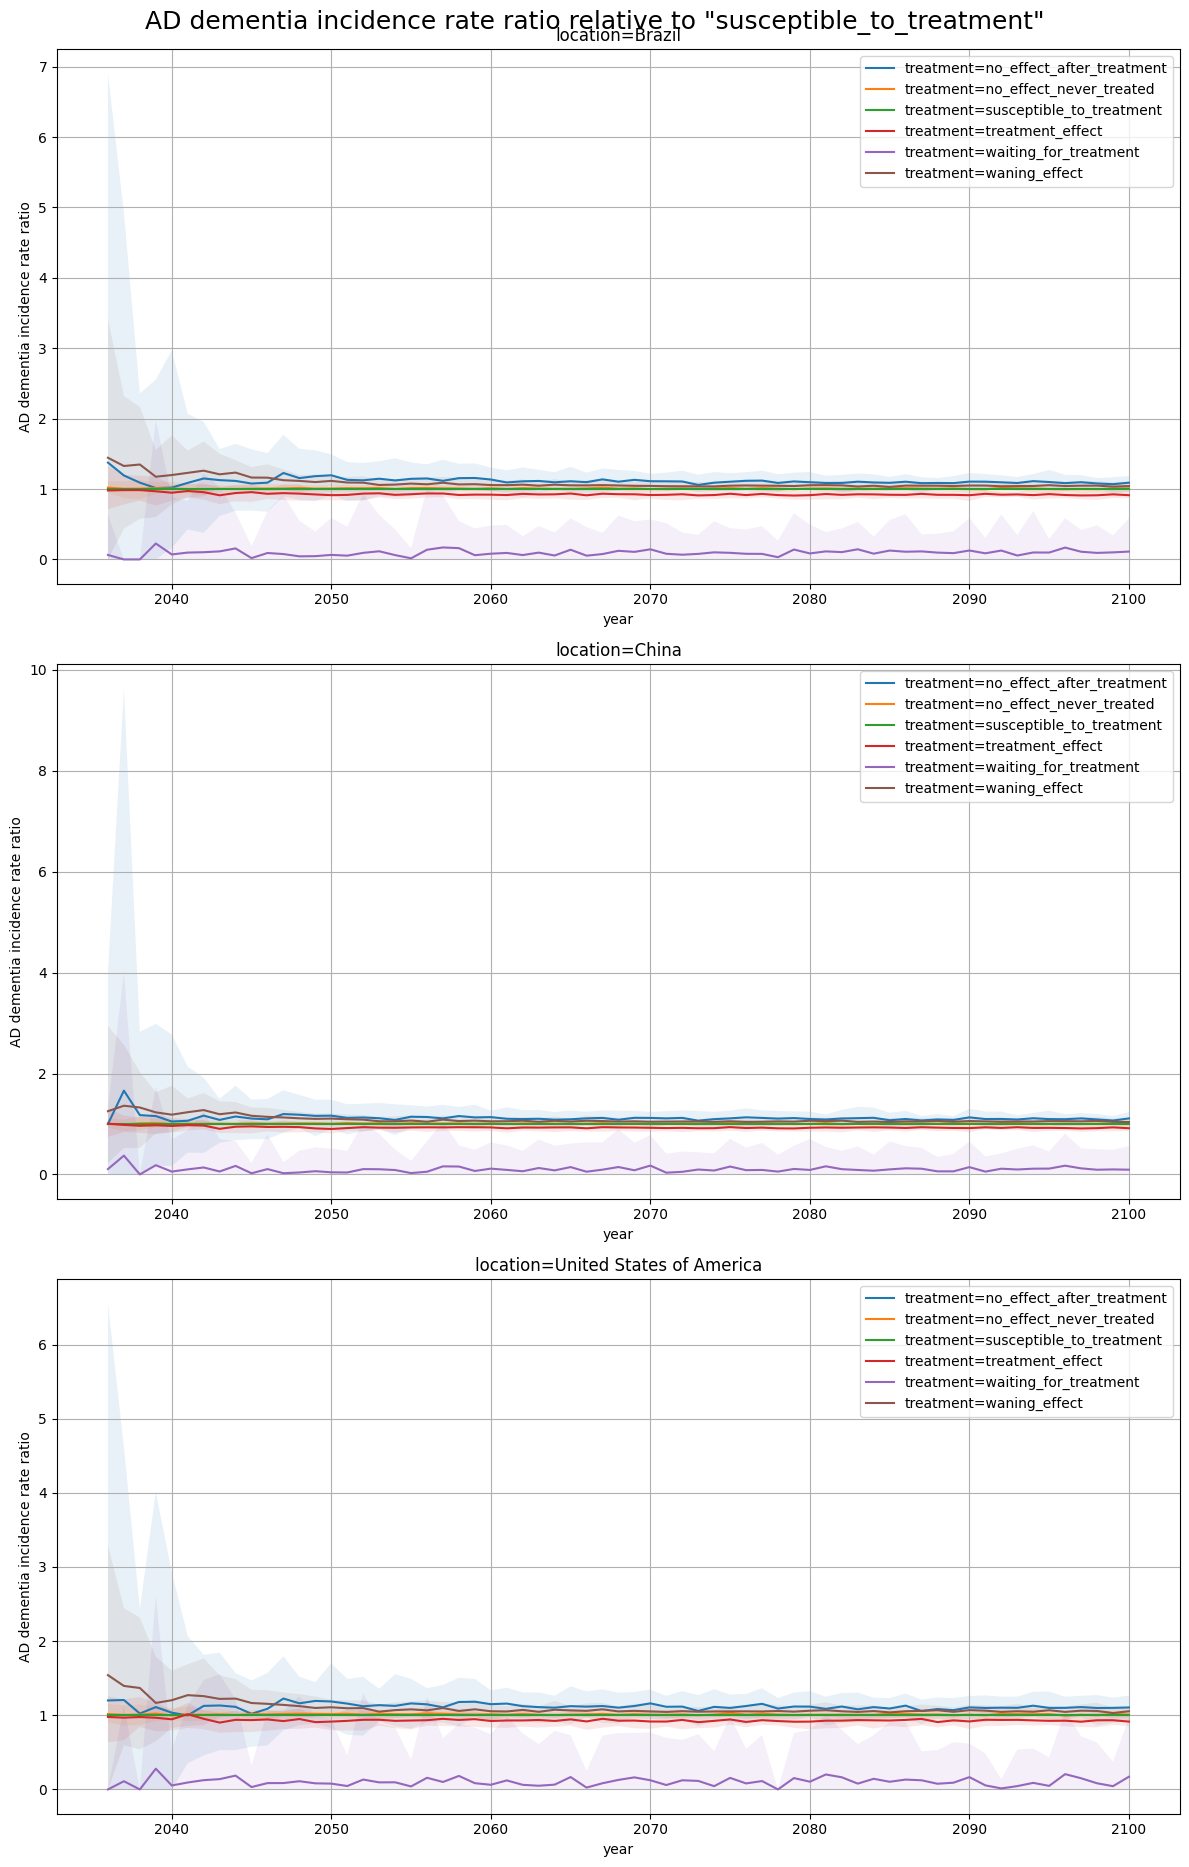

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    # NOTE: Without filtering infinities out, the `lower` method fails
    # with "FloatingPointError: invalid value encountered in subtract"
    hazard_ratio.loc[~inf_ratio].query(
        "scenario=='bbbm_testing_and_treatment' and event_year > 2035"
        " and from_state=='alzheimers_mild_cognitive_impairment_state'"
        ),
    'treatment',
    'location',
    ylabel='AD dementia incidence rate ratio',
    suptitle='AD dementia incidence rate ratio relative to "susceptible_to_treatment"',
    # uncertainty=False,
)
for ax in fig.axes:
    ax.grid(True)
    # ax.semilogy()
plt.show()

In [ ]:
# Why are the hazard ratios above 0.5?
# Maybe it's selection bias due to age?
hazard_ratio.loc[~inf_ratio].query(
    "scenario=='bbbm_testing_and_treatment'"# and event_year > 2035"
    " and from_state=='alzheimers_blood_based_biomarker_state'"
    " and treatment == 'treatment_effect'"
    " and event_year >= 2040"
    ).pipe(ops.describe)

count  \
denominator_measure event_year from_state                             location                 multiplier numerator_measure scenario                   treatment                 
transition_rate     2040       alzheimers_blood_based_biomarker_state Brazil                   1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      United States of America 1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                    2041       alzheimers_blood_based_biomarker_state Brazil                   1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
...                                                                                                                                                                        ...   
                    2099       alzheimers_blood_based_biomarker_state China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      United States of America 1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                    2100       alzheimers_blood_based_biomarker_state Brazil                   1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   
                                                                      United States of America 1          transition_rate   bbbm_testing_and_treatment treatment_effect   25.0   

                                                                                                                                                                             mean  \
denominator_measure event_year from_state                             location                 multiplier numerator_measure scenario                   treatment                    
transition_rate     2040       alzheimers_blood_based_biomarker_state Brazil                   1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.758885   
                                                                      China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.754750   
                                                                      United States of America 1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.740506   
                    2041       alzheimers_blood_based_biomarker_state Brazil                   1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.754937   
                                                                      China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.755071   
...                                                                                                                                                                           ...   
                    2099       alzheimers_blood_based_biomarker_state China                    1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.660980   
                                                                      United States of America 1          transition_rate   bbbm_testing_and_treatment treatment_effect  0.671499   
                    2100       alzheimers_bl

# Results!

# Load deaths and plot averted deaths by scenario

In [ ]:
deaths = load_sim_output('deaths')
print_memory_usage(deaths)
deaths

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
27.73271 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,baseline,Female,0.0,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,baseline,Male,0.0,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,bbbm_testing,Female,0.0,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,bbbm_testing,Male,0.0,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,bbbm_testing_and_treatment,Female,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...
1066495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,baseline,Male,1313.0,Brazil
1066496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,bbbm_testing,Female,4284.0,Brazil
1066497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,bbbm_testing,Male,1313.0,Brazil
1066498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,bbbm_testing_and_treatment,Female,4368.0,Brazil


In [ ]:
# NOTE: I had to rework some code in my vph_output.operators.difference
# function to prevent this code from converting Categoricals back to
# strings and making the memory explode...
averted_deaths = ops.averted(deaths, baseline_scenario='baseline')
print_memory_usage(averted_deaths)
# convert_dtypes(averted_deaths, colname_to_dtype=colname_to_categorical_dtype, inplace=True)
# print_memory_usage(averted_deaths)
# convert_to_categorical(averted_deaths, inplace=True)
# print_memory_usage(averted_deaths)
averted_deaths

27.73271 MB measure
12.090578 MB minuend
24.177578 MB subtrahend
6.405373 MB minuend re-indexed
12.804373 MB subtrahend re-indexed
12.804433 MB difference
18.48971 MB difference with reset index
19.201035 MB final difference
19.201035 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,sex,location,scenario,subtracted_from,value
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,Female,United States of America,bbbm_testing,baseline,0.0
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,Male,United States of America,bbbm_testing,baseline,0.0
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,Female,United States of America,bbbm_testing_and_treatment,baseline,0.0
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,deaths,Male,United States of America,bbbm_testing_and_treatment,baseline,0.0
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,6,deaths,Female,United States of America,bbbm_testing,baseline,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
710995,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,248,deaths,Male,Brazil,bbbm_testing_and_treatment,baseline,-5.0
710996,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,Female,Brazil,bbbm_testing,baseline,0.0
710997,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,Male,Brazil,bbbm_testing,baseline,0.0
710998,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,deaths,Female,Brazil,bbbm_testing_and_treatment,baseline,-84.0


In [ ]:
averted_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711000 entries, 0 to 710999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   age_group        711000 non-null  category
 1   artifact_path    711000 non-null  category
 2   entity           711000 non-null  category
 3   entity_type      711000 non-null  category
 4   event_year       711000 non-null  int16   
 5   input_draw       711000 non-null  int64   
 6   measure          711000 non-null  category
 7   sex              711000 non-null  category
 8   location         711000 non-null  category
 9   scenario         711000 non-null  category
 10  subtracted_from  711000 non-null  category
 11  value            711000 non-null  float64 
dtypes: category(9), float64(1), int16(1), int64(1)
memory usage: 18.3 MB


In [ ]:
averted_deaths['scenario'].dtype.categories

Index(['baseline', 'bbbm_testing', 'bbbm_testing_and_treatment'], dtype='object')

In [ ]:
averted_deaths.index.memory_usage(deep=True)

132

In [ ]:
averted_deaths.entity.unique()

['alzheimers_disease_state', 'other_causes']
Categories (2, object): ['alzheimers_disease_state', 'other_causes']

In [ ]:
averted_deaths.value.describe()

count    711000.000000
mean          0.195100
std           6.286377
min         -84.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         116.000000
Name: value, dtype: float64

In [ ]:
# convert_dtypes(averted_deaths, colname_to_categorical_dtype, inplace=True)
# convert_to_categorical(averted_deaths, inplace=True)
print_memory_usage(averted_deaths)

19.201035 MB


In [ ]:
# FIXME: Wait, to get percent deaths averted, do I want to be dividing
# by deaths in the intervention scenarios (like I do here), or should I
# be dividing by deaths in the *baseline* scenario? Probably the
# latter...
print_memory_usage(averted_deaths)
averted_deaths_pct = ops.ratio(
    averted_deaths,
    deaths.query("scenario != 'baseline'"),
    strata=['entity', 'age_group', 'event_year'],
    dropna=True, # Drop strata in younger age groups where we divided by 0
    multiplier=100,
)
print_memory_usage(averted_deaths_pct)
# convert_dtypes(averted_deaths_pct, colname_to_categorical_dtype, inplace=True)
# print_memory_usage(averted_deaths_pct)
# convert_to_categorical(averted_deaths_pct, inplace=True)
# print_memory_usage(averted_deaths_pct)
averted_deaths_pct

19.201035 MB
8.432853 MB


,entity,age_group,event_year,input_draw,scenario,location,value,numerator_measure,denominator_measure,multiplier
0,alzheimers_disease_state,40_to_44,2025,69,bbbm_testing,Brazil,0.000000,deaths,deaths,100
1,alzheimers_disease_state,40_to_44,2025,69,bbbm_testing_and_treatment,Brazil,0.000000,deaths,deaths,100
2,alzheimers_disease_state,40_to_44,2026,50,bbbm_testing,Brazil,0.000000,deaths,deaths,100
3,alzheimers_disease_state,40_to_44,2026,50,bbbm_testing,China,0.000000,deaths,deaths,100
4,alzheimers_disease_state,40_to_44,2026,50,bbbm_testing,United States of America,0.000000,deaths,deaths,100
...,...,...,...,...,...,...,...,...,...,...
263431,other_causes,95_plus,2100,249,bbbm_testing,China,0.000000,deaths,deaths,100
263432,other_causes,95_plus,2100,249,bbbm_testing,United States of America,0.000000,deaths,deaths,100
263433,other_causes,95_plus,2100,249,bbbm_testing_and_treatment,Brazil,-1.772552,deaths,deaths,100
263434,other_causes,95_plus,2100,249,bbbm_testing_and_treatment,China,-1.712234,deaths,deaths,100


In [ ]:
averted_deaths_pct.memory_usage(deep=True)

Index                      132
entity                  263694
age_group               264966
event_year              526872
input_draw             2107488
scenario                263761
location                263750
value                  2107488
numerator_measure       263607
denominator_measure     263607
multiplier             2107488
dtype: int64

In [ ]:
ops.stratify(averted_deaths, 'event_year')

,event_year,input_draw,scenario,location,value
0,2022,1,bbbm_testing,Brazil,0.0
1,2022,1,bbbm_testing,China,0.0
2,2022,1,bbbm_testing,United States of America,0.0
3,2022,1,bbbm_testing_and_treatment,Brazil,0.0
4,2022,1,bbbm_testing_and_treatment,China,0.0
...,...,...,...,...,...
11845,2100,249,bbbm_testing,China,0.0
11846,2100,249,bbbm_testing,United States of America,0.0
11847,2100,249,bbbm_testing_and_treatment,Brazil,50.0
11848,2100,249,bbbm_testing_and_treatment,China,53.0


In [ ]:
# # FIXME: For some reason, this was taking a long time (>30 seconds before I interrupted it)
# averted_deaths_summary = summarize_sim_data(averted_deaths)
# averted_deaths_summary

In [ ]:
def f(a=None, *args, **kwargs):
    print(a, args, kwargs)

f(1,2,3)
f(2)
f(5, b=4)
f(5, 6, b=7)
f(a=5, b=7)
f()

1 (2, 3) {}
2 () {}
5 () {'b': 4}
5 (6,) {'b': 7}
5 () {'b': 7}
None () {}


In [ ]:
f(2)

2 () {}


# Draw results plots

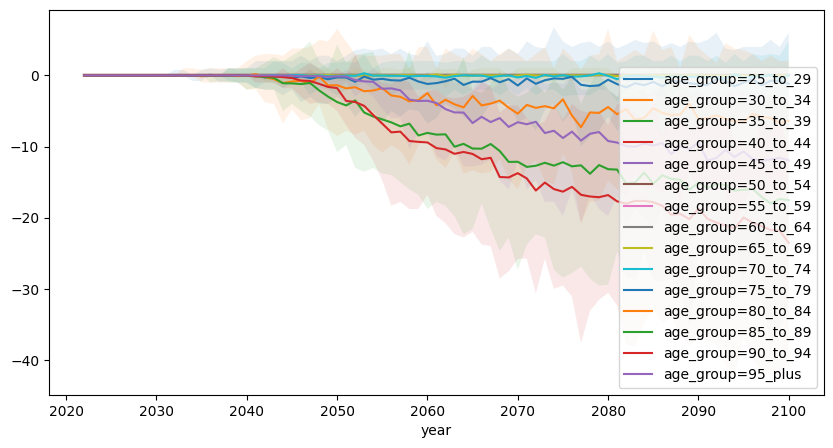

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax = plot_over_time_by_column(averted_deaths.query(
    "scenario == 'bbbm_testing_and_treatment' and entity == 'other_causes'"
    f" and location=={locations[0]!r}"
    ),
    'age_group'
)
# ax.set_xticks(ax.get_xticks()[::10])
plt.show()


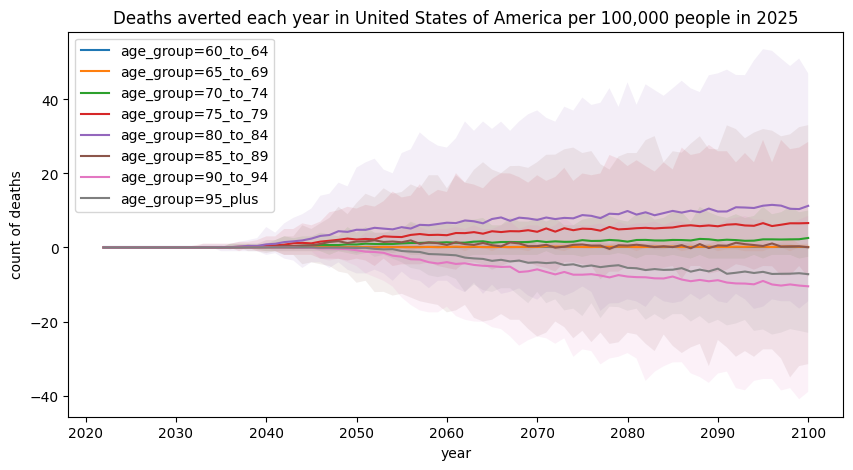

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax = plot_over_time_by_column(
    averted_deaths
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment'" #and entity == 'alzheimers_disease_state'"
        f" and location=={locations[0]!r}"
        ),
    'age_group',
    ylabel="count of deaths",
    title=f"Deaths averted each year in {locations[0]} per 100,000 people in 2025"
)
# ax.set_xticks(ax.get_xticks()[::10])
plt.show()

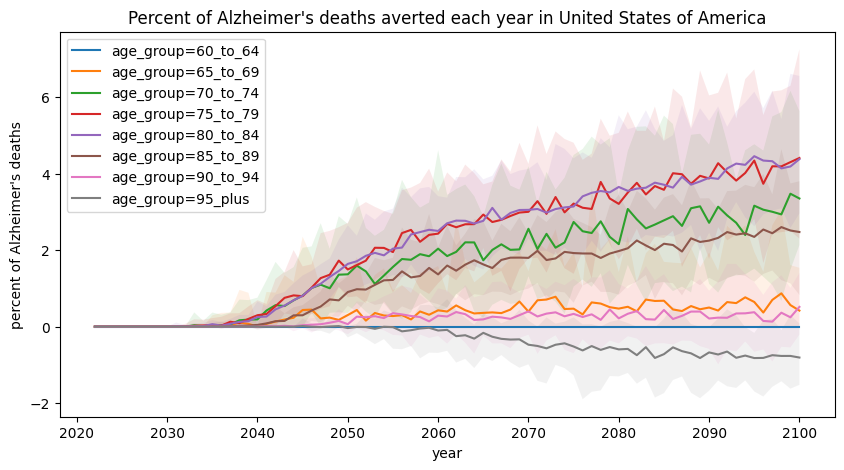

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax = plot_over_time_by_column(
    averted_deaths_pct
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'alzheimers_disease_state'"
        f" and location=={locations[0]!r}"
        ),
    'age_group',
    ylabel="percent of Alzheimer's deaths",
    title=f"Percent of Alzheimer's deaths averted each year in {locations[0]}"
)
# ax.set_xticks(ax.get_xticks()[::10])
plt.show()

In [ ]:
deaths.scenario.unique()

['baseline', 'bbbm_testing', 'bbbm_testing_and_treatment']
Categories (3, object): ['baseline' < 'bbbm_testing' < 'bbbm_testing_and_treatment']

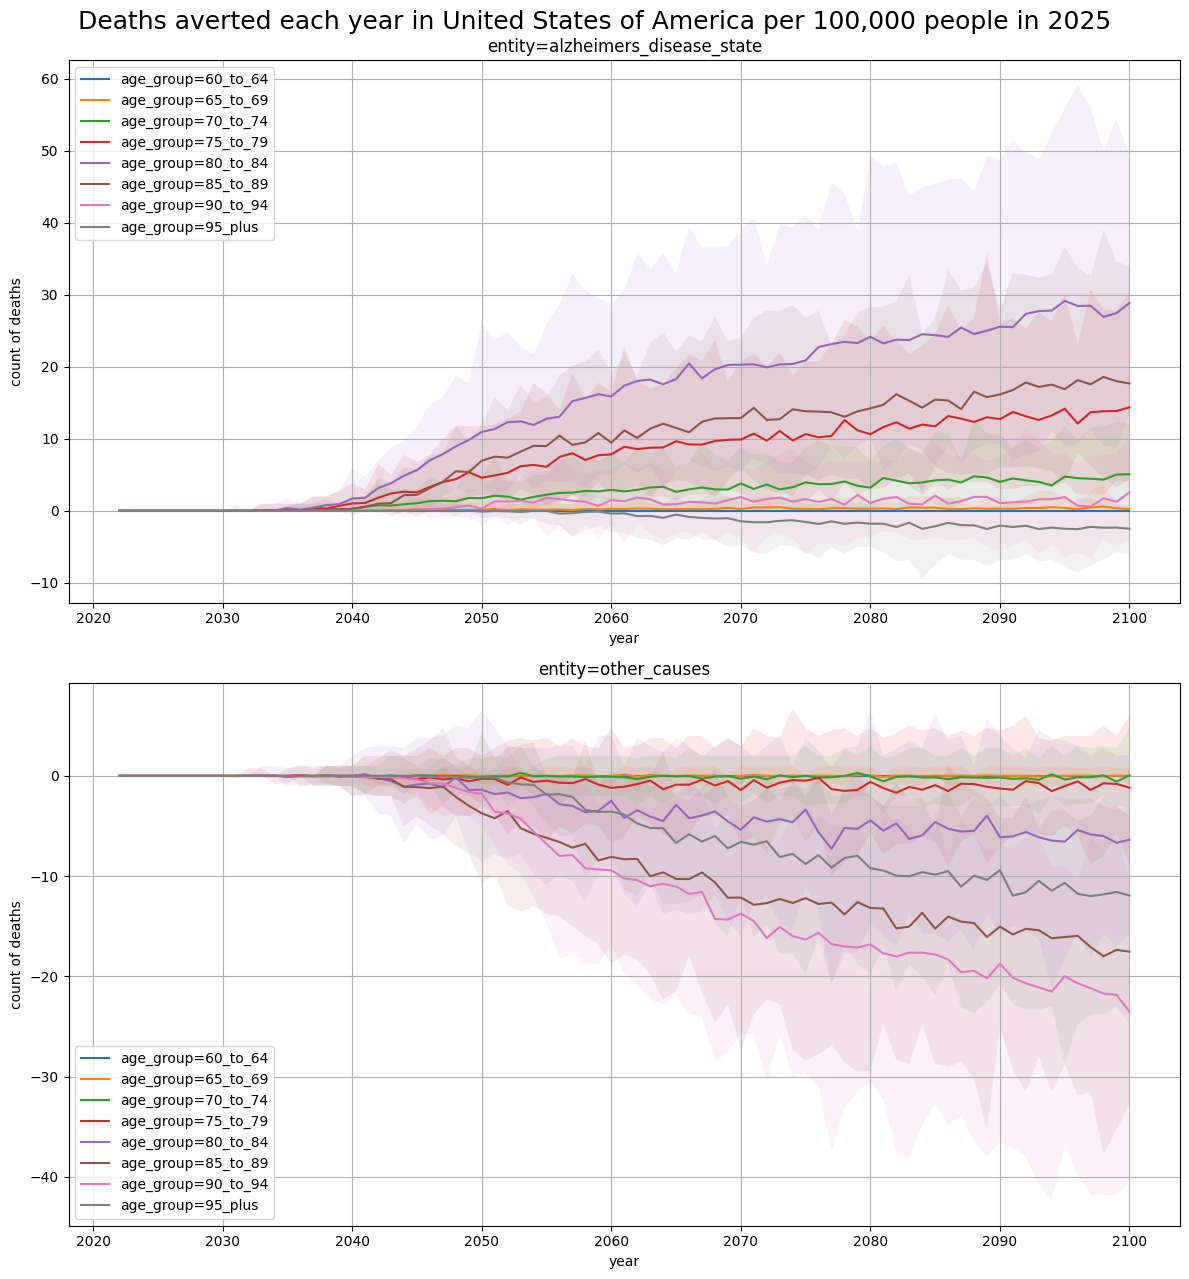

In [ ]:
location = locations[0]
fig = plot_over_time_by_column_for_row_x_1(
    averted_deaths
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and location==@location"
        ),
    'age_group',
    'entity',
    ylabel="count of deaths",
    suptitle=f"Deaths averted each year in {location} per 100,000 people in 2025"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

# Absolute reductions in AD deaths for all countries

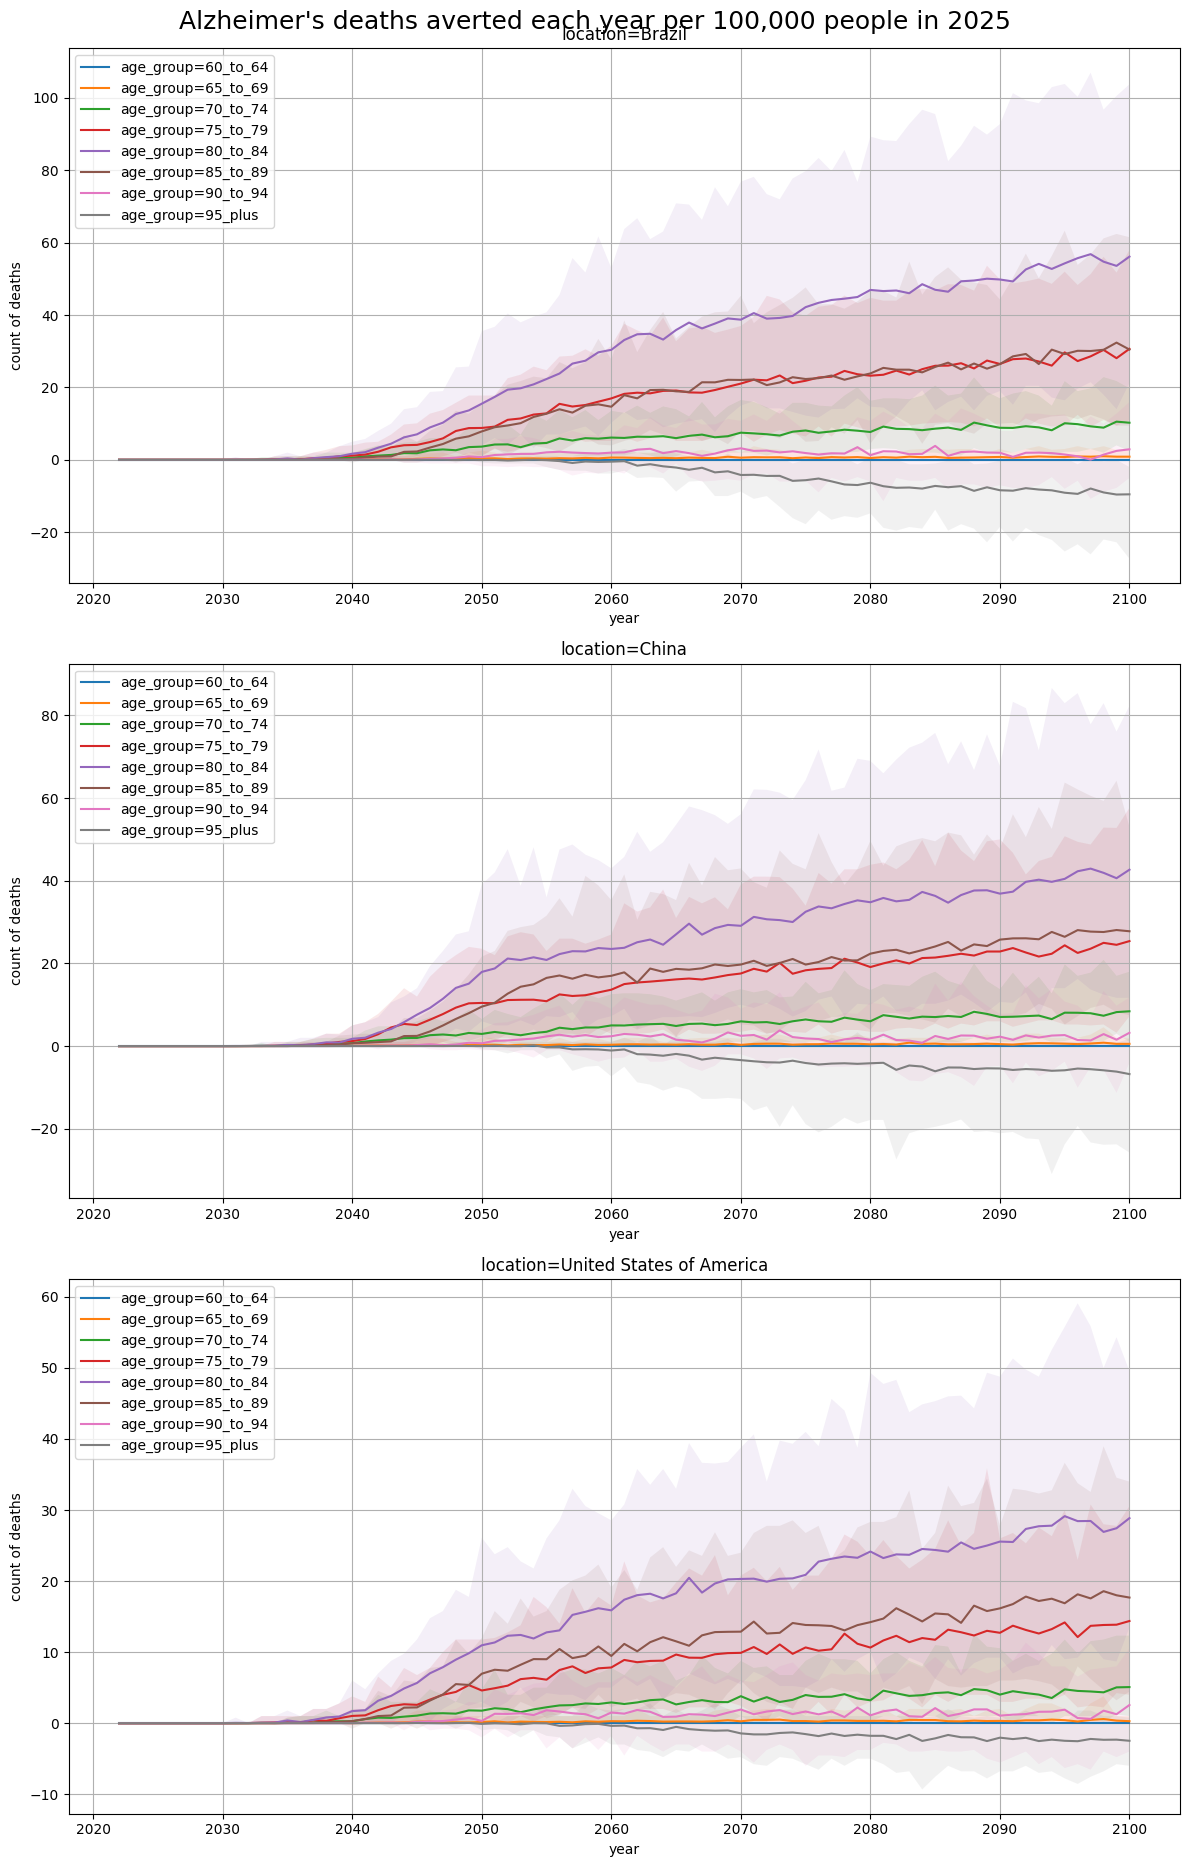

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    averted_deaths
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'alzheimers_disease_state'"
        ),
    'age_group',
    'location',
    ylabel="count of deaths",
    suptitle=f"Alzheimer's deaths averted each year per 100,000 people in 2025"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

# Percent reductions in deaths for all countries

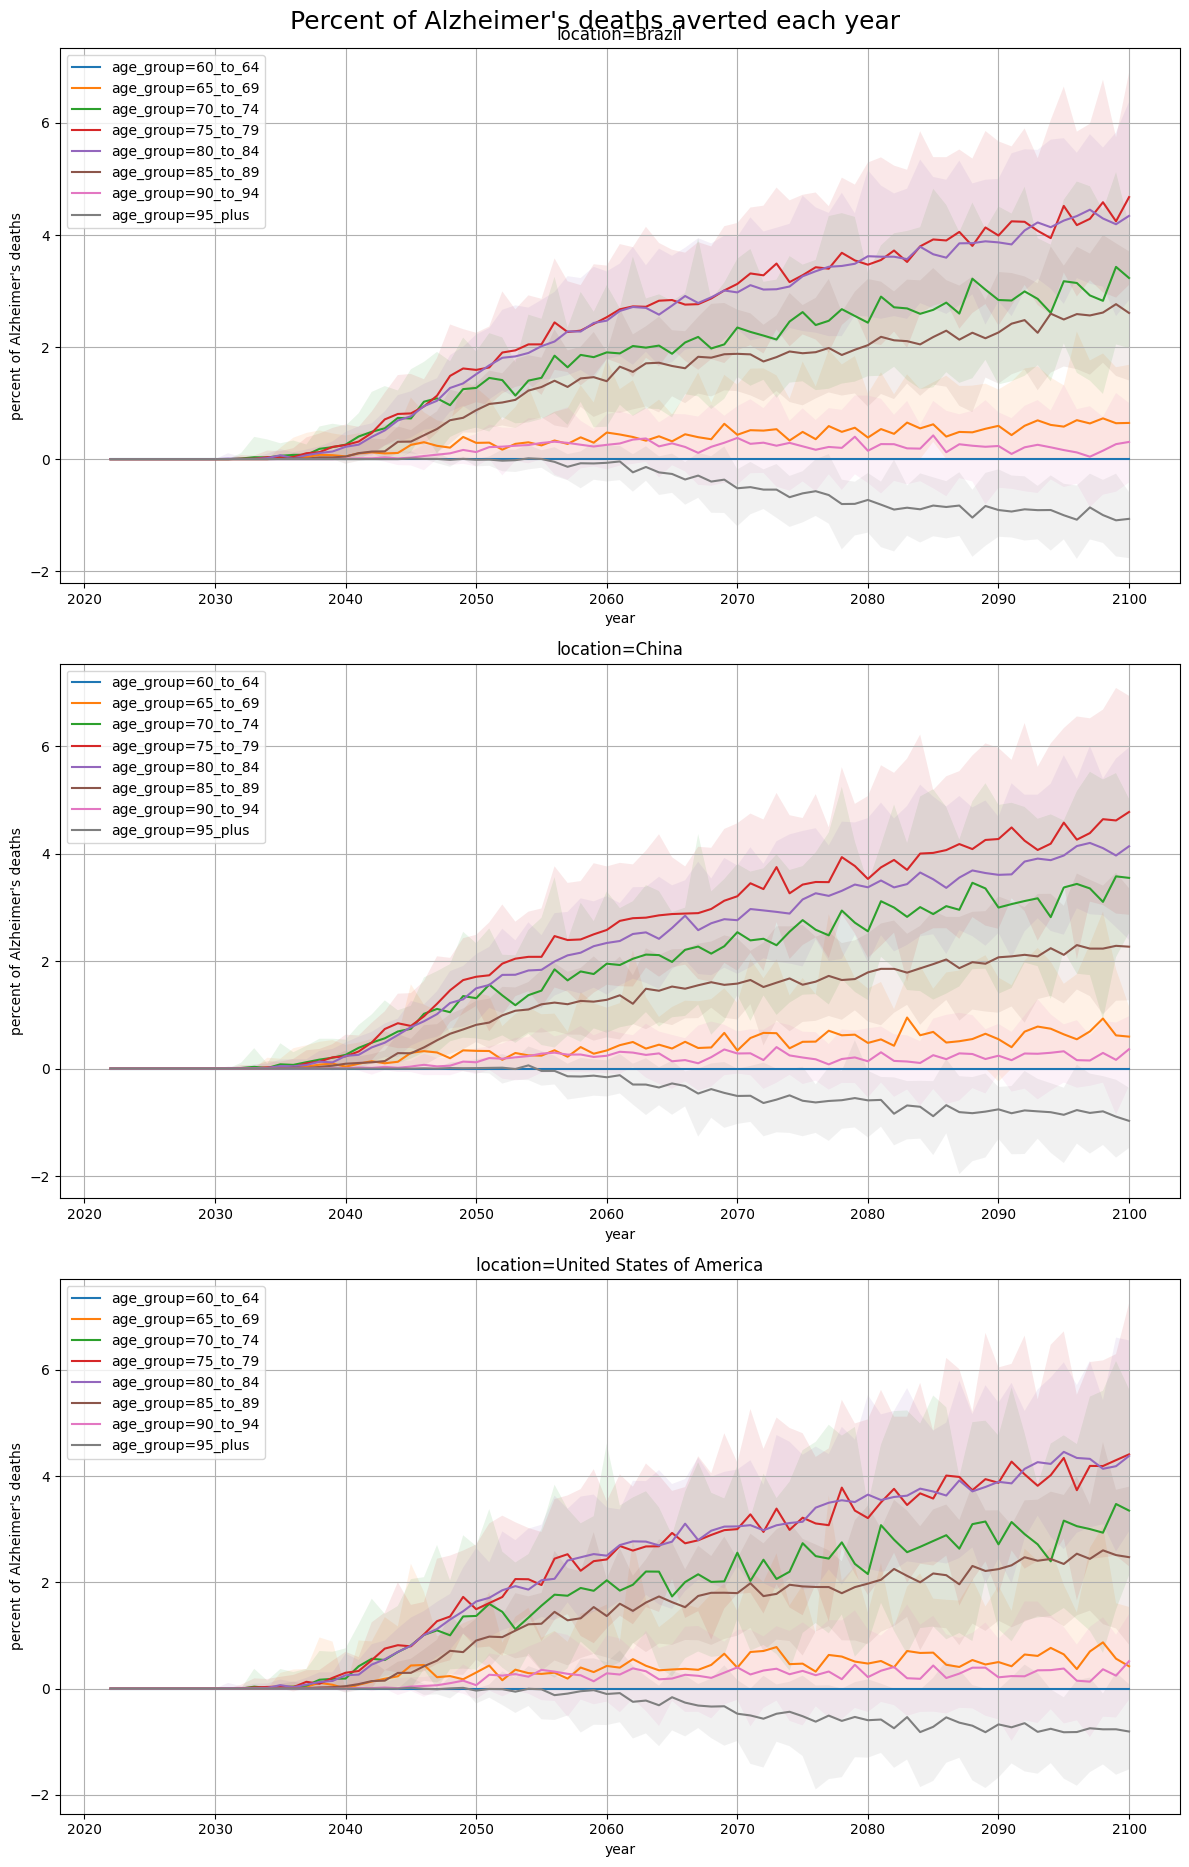

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    averted_deaths_pct
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'alzheimers_disease_state'"
        ),
    'age_group',
    'location',
    ylabel="percent of Alzheimer's deaths",
    suptitle=f"Percent of Alzheimer's deaths averted each year"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

# Load YLLs and plot averted YLLs

In [ ]:
ylls = load_sim_output('ylls')
print_memory_usage(ylls)
ylls

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
27.732708 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,ylls,baseline,Female,0.000000,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,ylls,baseline,Male,0.000000,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,ylls,bbbm_testing,Female,0.000000,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,ylls,bbbm_testing,Male,0.000000,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,alzheimers_disease_state,cause,2022,1,ylls,bbbm_testing_and_treatment,Female,0.000000,United States of America
...,...,...,...,...,...,...,...,...,...,...,...
1066495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,ylls,baseline,Male,10088.027970,Brazil
1066496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,ylls,bbbm_testing,Female,33354.885569,Brazil
1066497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,ylls,bbbm_testing,Male,10088.027970,Brazil
1066498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,other_causes,cause,2100,249,ylls,bbbm_testing_and_treatment,Female,34017.344973,Brazil


In [ ]:
averted_ylls = ops.averted(ylls, baseline_scenario='baseline')
print_memory_usage(averted_ylls)

27.732708 MB measure
12.090576 MB minuend
24.177576 MB subtrahend
6.405371 MB minuend re-indexed
12.804371 MB subtrahend re-indexed
12.804431 MB difference
18.489708 MB difference with reset index
19.201033 MB final difference
19.201033 MB


In [ ]:
averted_ylls.entity.unique()

['alzheimers_disease_state', 'other_causes']
Categories (2, object): ['alzheimers_disease_state', 'other_causes']

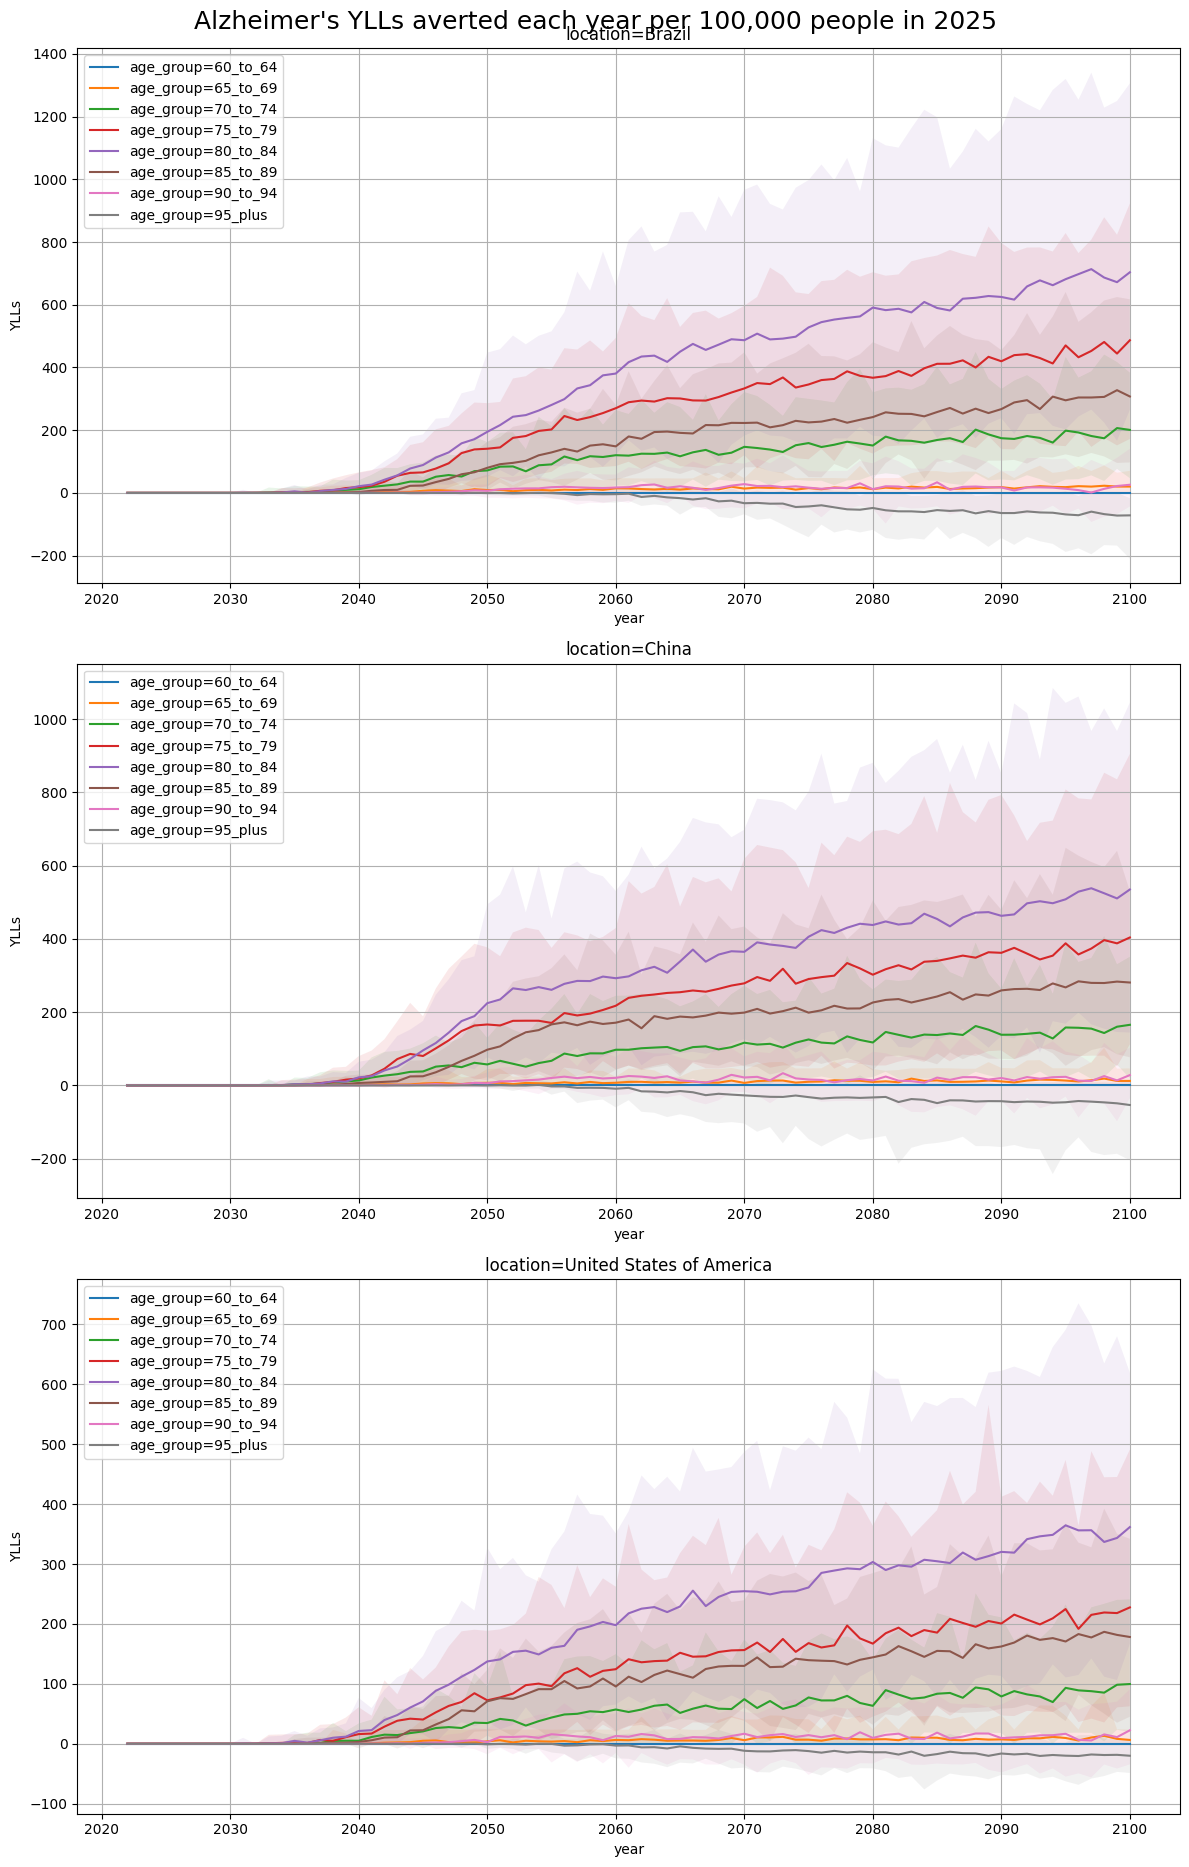

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    averted_ylls
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'alzheimers_disease_state'"
        ),
    'age_group',
    'location',
    ylabel="YLLs",
    suptitle=f"Alzheimer's YLLs averted each year per 100,000 people in 2025"
)
for ax in fig.axes:
    ax.grid(True)
plt.show()

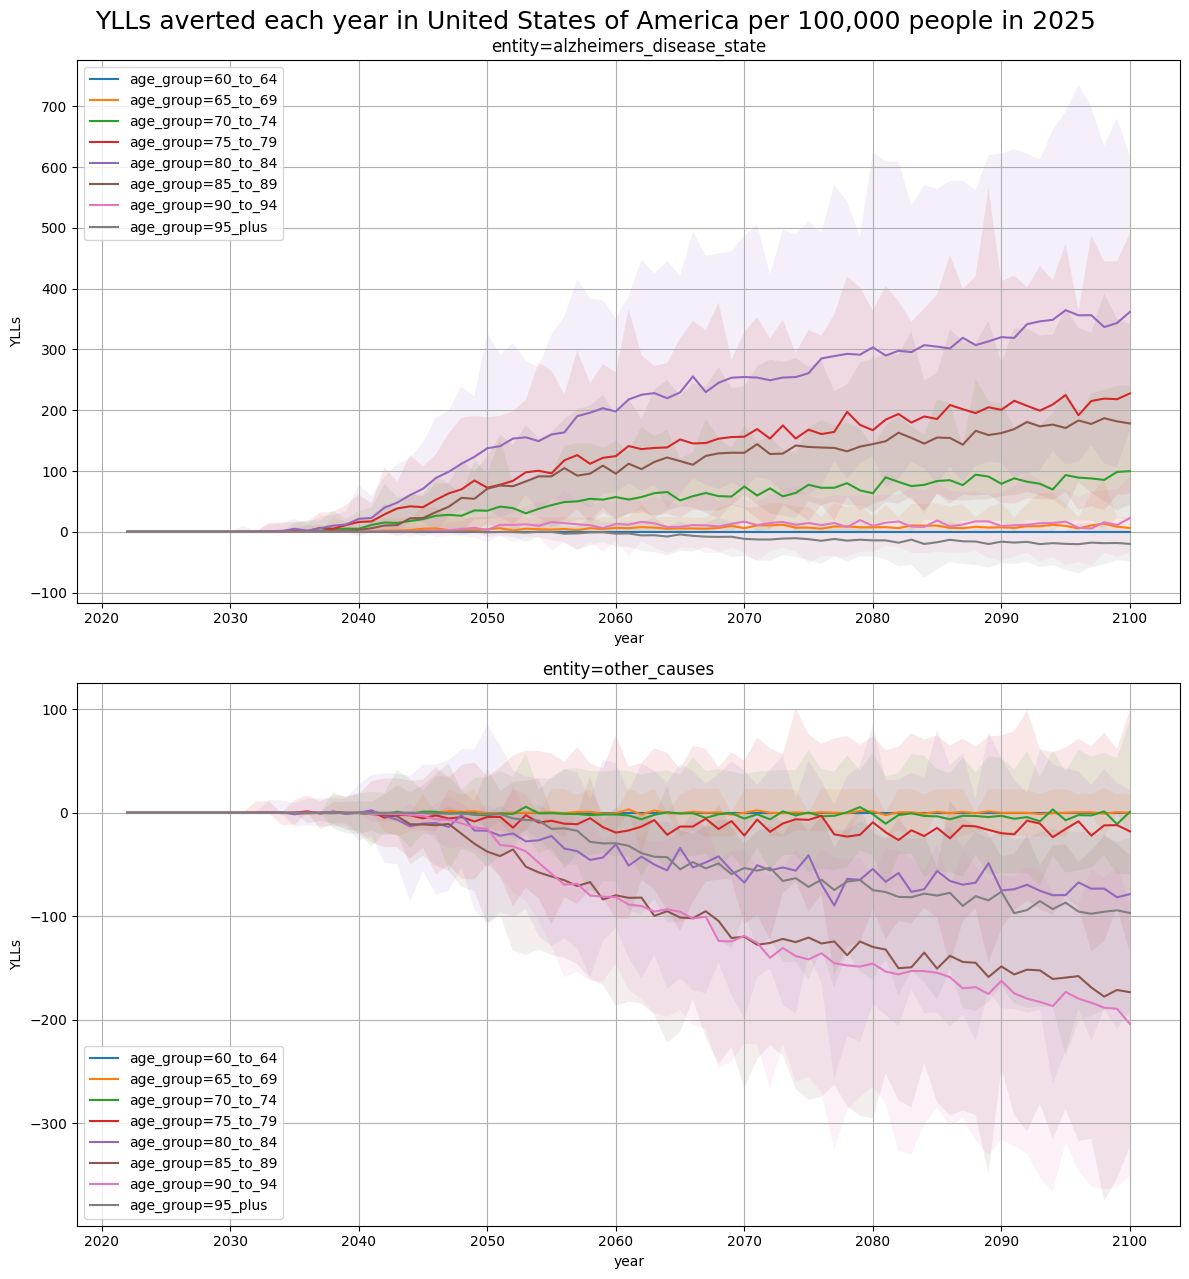

In [ ]:
location = locations[0]
fig = plot_over_time_by_column_for_row_x_1(
    averted_ylls
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and location==@location"
        ),
    'age_group',
    'entity',
    ylabel="YLLs",
    suptitle=f"YLLs averted each year in {location} per 100,000 people in 2025"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

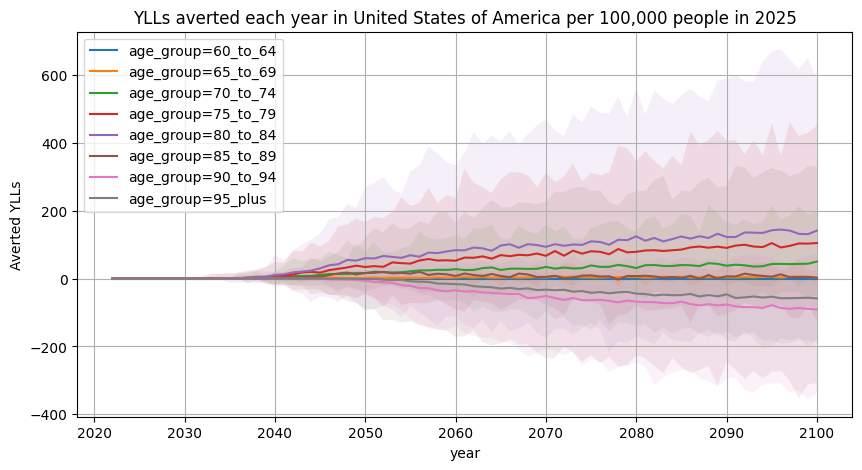

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax = plot_over_time_by_column(
    averted_ylls
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment'" #and entity == 'alzheimers_disease_state'"
        f" and location=={locations[0]!r}"
        ),
    'age_group',
    ylabel="Averted YLLs",
    title=f"YLLs averted each year in {locations[0]} per 100,000 people in 2025"
)
# ax.set_xticks(ax.get_xticks()[::10])
ax.grid(True)
plt.show()

# Load YLDs and plot averted YLDs

In [ ]:
ylds = load_sim_output('ylds')
print_memory_usage(ylds)
ylds

('artifact_path', 'in', ['/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/brazil.hdf', '/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/china.hdf'])
129.584561 MB


,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,scenario,sex,sub_entity,value,location
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,baseline,Female,all_causes,0.0,United States of America
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,baseline,Male,all_causes,0.0,United States of America
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,bbbm_testing,Female,all_causes,0.0,United States of America
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,bbbm_testing,Male,all_causes,0.0,United States of America
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,bbbm_testing_and_treatment,Female,all_causes,0.0,United States of America
...,...,...,...,...,...,...,...,...,...,...,...,...
4799245,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,bbbm_testing_and_treatment,Male,no_effect_after_treatment,0.0,Brazil
4799246,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,bbbm_testing_and_treatment,Male,no_effect_never_treated,0.0,Brazil
4799247,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,bbbm_testing_and_treatment,Male,treatment_effect,0.0,Brazil
4799248,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,bbbm_testing_and_treatment,Male,waiting_for_treatment,0.0,Brazil


In [ ]:
averted_ylds = ops.averted(ylds, baseline_scenario='baseline')
print_memory_usage(averted_ylds)
# This converts years from int64 to int16
# convert_dtypes(averted_ylds, colname_to_dtype, inplace=True)
averted_ylds = averted_ylds.astype(colname_to_dtype, copy=False)
print_memory_usage(averted_ylds)
# This would convert integer years to Categorical
# convert_to_categorical(averted_ylds, inplace=True)
# print_memory_usage(averted_ylds)

129.584561 MB measure
55.995929 MB minuend
111.987179 MB subtrahend
30.402793 MB minuend re-indexed
60.798043 MB subtrahend re-indexed
60.798103 MB difference
86.391311 MB difference with reset index
89.591136 MB final difference
89.591136 MB
89.591136 MB


In [ ]:
1086.443257 / 27.372526

39.69101196579373

In [ ]:
averted_ylds.memory_usage(deep=True)

Index                   132
age_group           3201030
artifact_path       3200078
entity              3199836
entity_type         3199670
event_year          6399000
input_draw         25596000
measure             3199669
sex                 3199732
sub_entity          3200525
location            3199814
scenario            3199825
subtracted_from     3199825
value              25596000
dtype: int64

In [ ]:
averted_ylds.dtypes

age_group          category
artifact_path      category
entity             category
entity_type        category
event_year            int16
input_draw            int64
measure            category
sex                category
sub_entity         category
location           category
scenario           category
subtracted_from    category
value               float64
dtype: object

In [ ]:
averted_ylds

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,sex,sub_entity,location,scenario,subtracted_from,value
0,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,Female,all_causes,United States of America,bbbm_testing,baseline,0.0
1,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,Male,all_causes,United States of America,bbbm_testing,baseline,0.0
2,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,Female,all_causes,United States of America,bbbm_testing_and_treatment,baseline,0.0
3,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,1,ylds,Male,all_causes,United States of America,bbbm_testing_and_treatment,baseline,0.0
4,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,all_causes,cause,2022,6,ylds,Female,all_causes,United States of America,bbbm_testing,baseline,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,no_effect_after_treatment,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,no_effect_never_treated,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,treatment_effect,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,waiting_for_treatment,Brazil,bbbm_testing_and_treatment,baseline,0.0


In [ ]:
averted_ylds.entity.unique()

['all_causes', 'alzheimers_disease_and_other_dementias', 'treatment']
Categories (3, object): ['all_causes', 'alzheimers_disease_and_other_dementias', 'treatment']

In [ ]:
# All values are 0 in this sub-dataframe
averted_ylds.query("entity=='treatment'")

,age_group,artifact_path,entity,entity_type,event_year,input_draw,measure,sex,sub_entity,location,scenario,subtracted_from,value
31600,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,ylds,Female,no_effect_after_treatment,United States of America,bbbm_testing,baseline,0.0
31601,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,ylds,Female,no_effect_never_treated,United States of America,bbbm_testing,baseline,0.0
31602,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,ylds,Female,treatment_effect,United States of America,bbbm_testing,baseline,0.0
31603,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,ylds,Female,waiting_for_treatment,United States of America,bbbm_testing,baseline,0.0
31604,25_to_29,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2022,1,ylds,Female,waning_effect,United States of America,bbbm_testing,baseline,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199495,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,no_effect_after_treatment,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199496,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,no_effect_never_treated,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199497,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,treatment_effect,Brazil,bbbm_testing_and_treatment,baseline,0.0
3199498,95_plus,/mnt/team/simulation_science/pub/models/vivari...,treatment,cause,2100,249,ylds,Male,waiting_for_treatment,Brazil,bbbm_testing_and_treatment,baseline,0.0


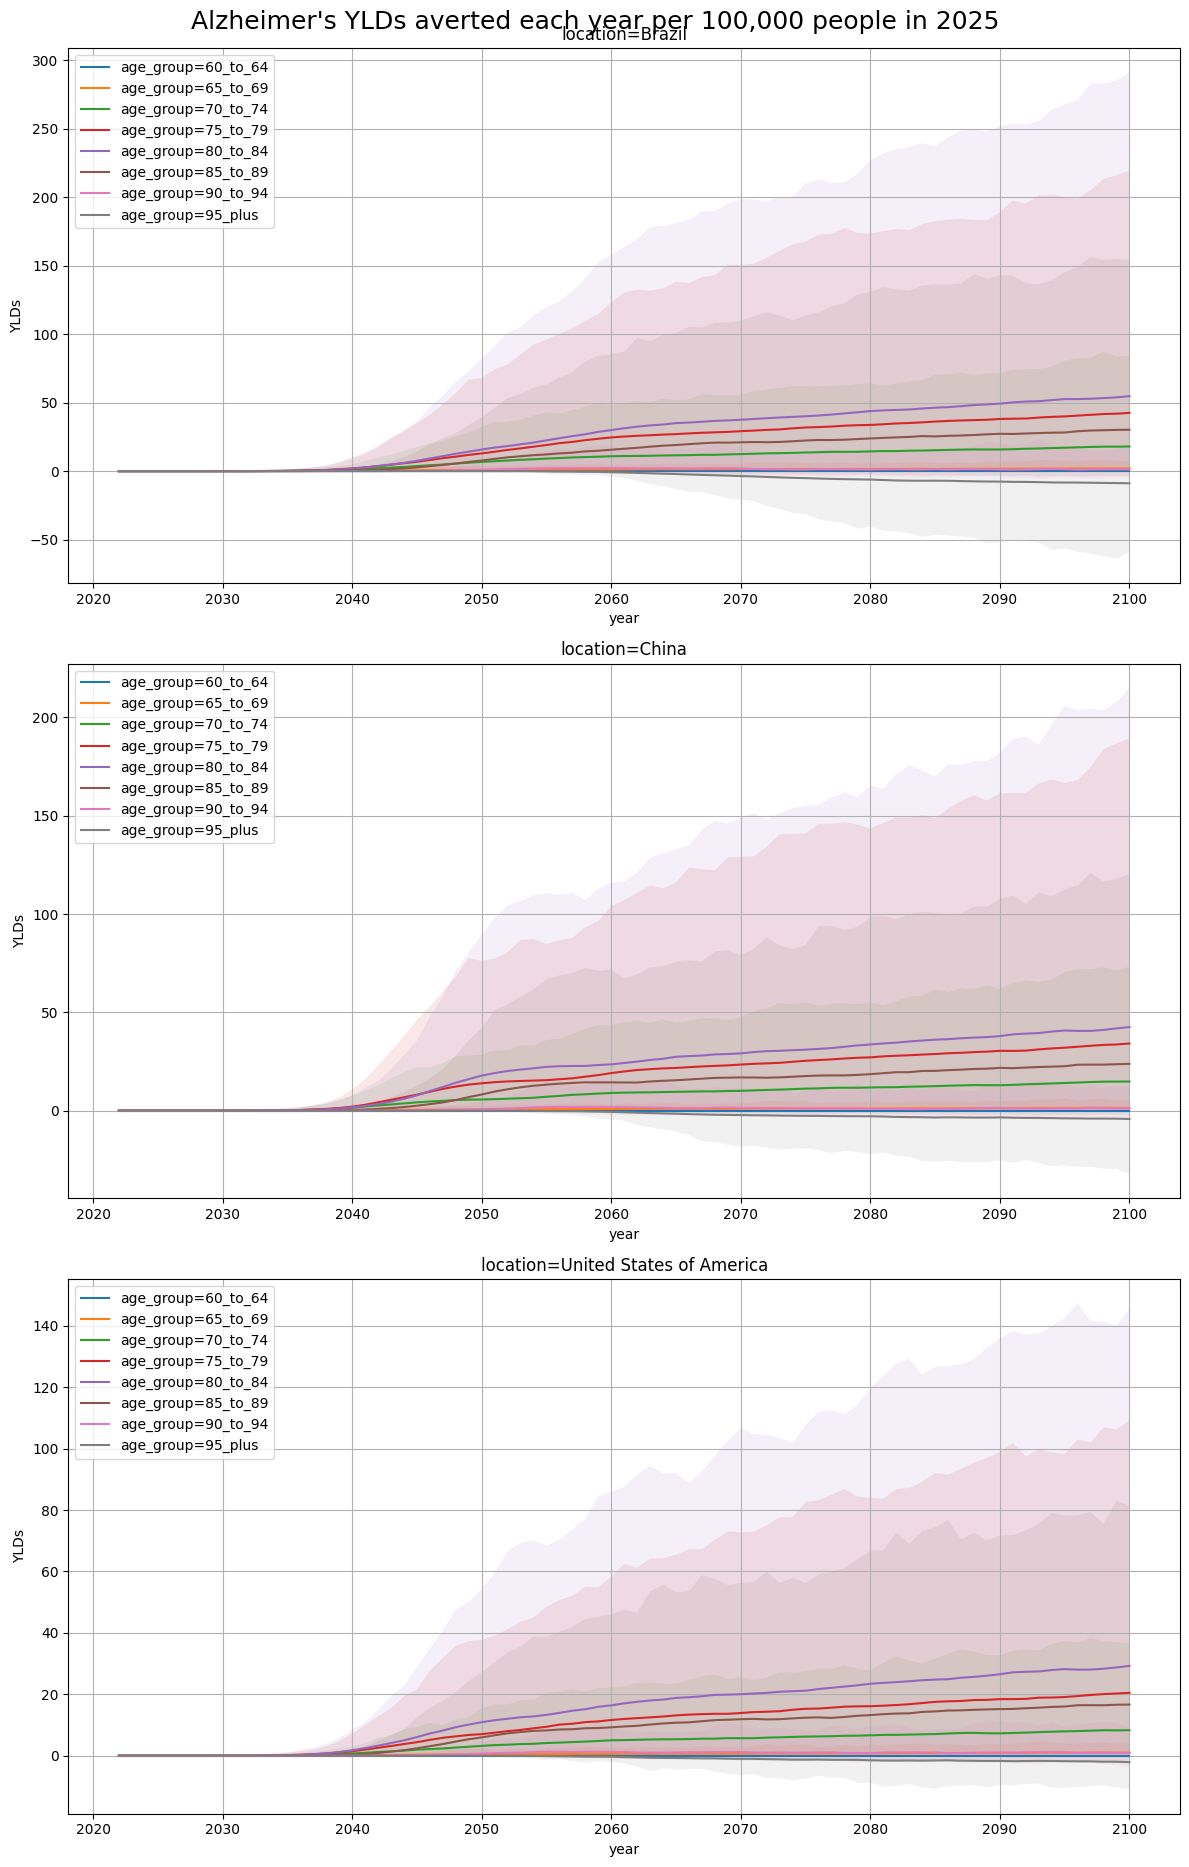

In [ ]:
fig = plot_over_time_by_column_for_row_x_1(
    averted_ylds
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'alzheimers_disease_and_other_dementias'"
        ),
    'age_group',
    'location',
    ylabel="YLDs",
    suptitle=f"Alzheimer's YLDs averted each year per 100,000 people in 2025"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

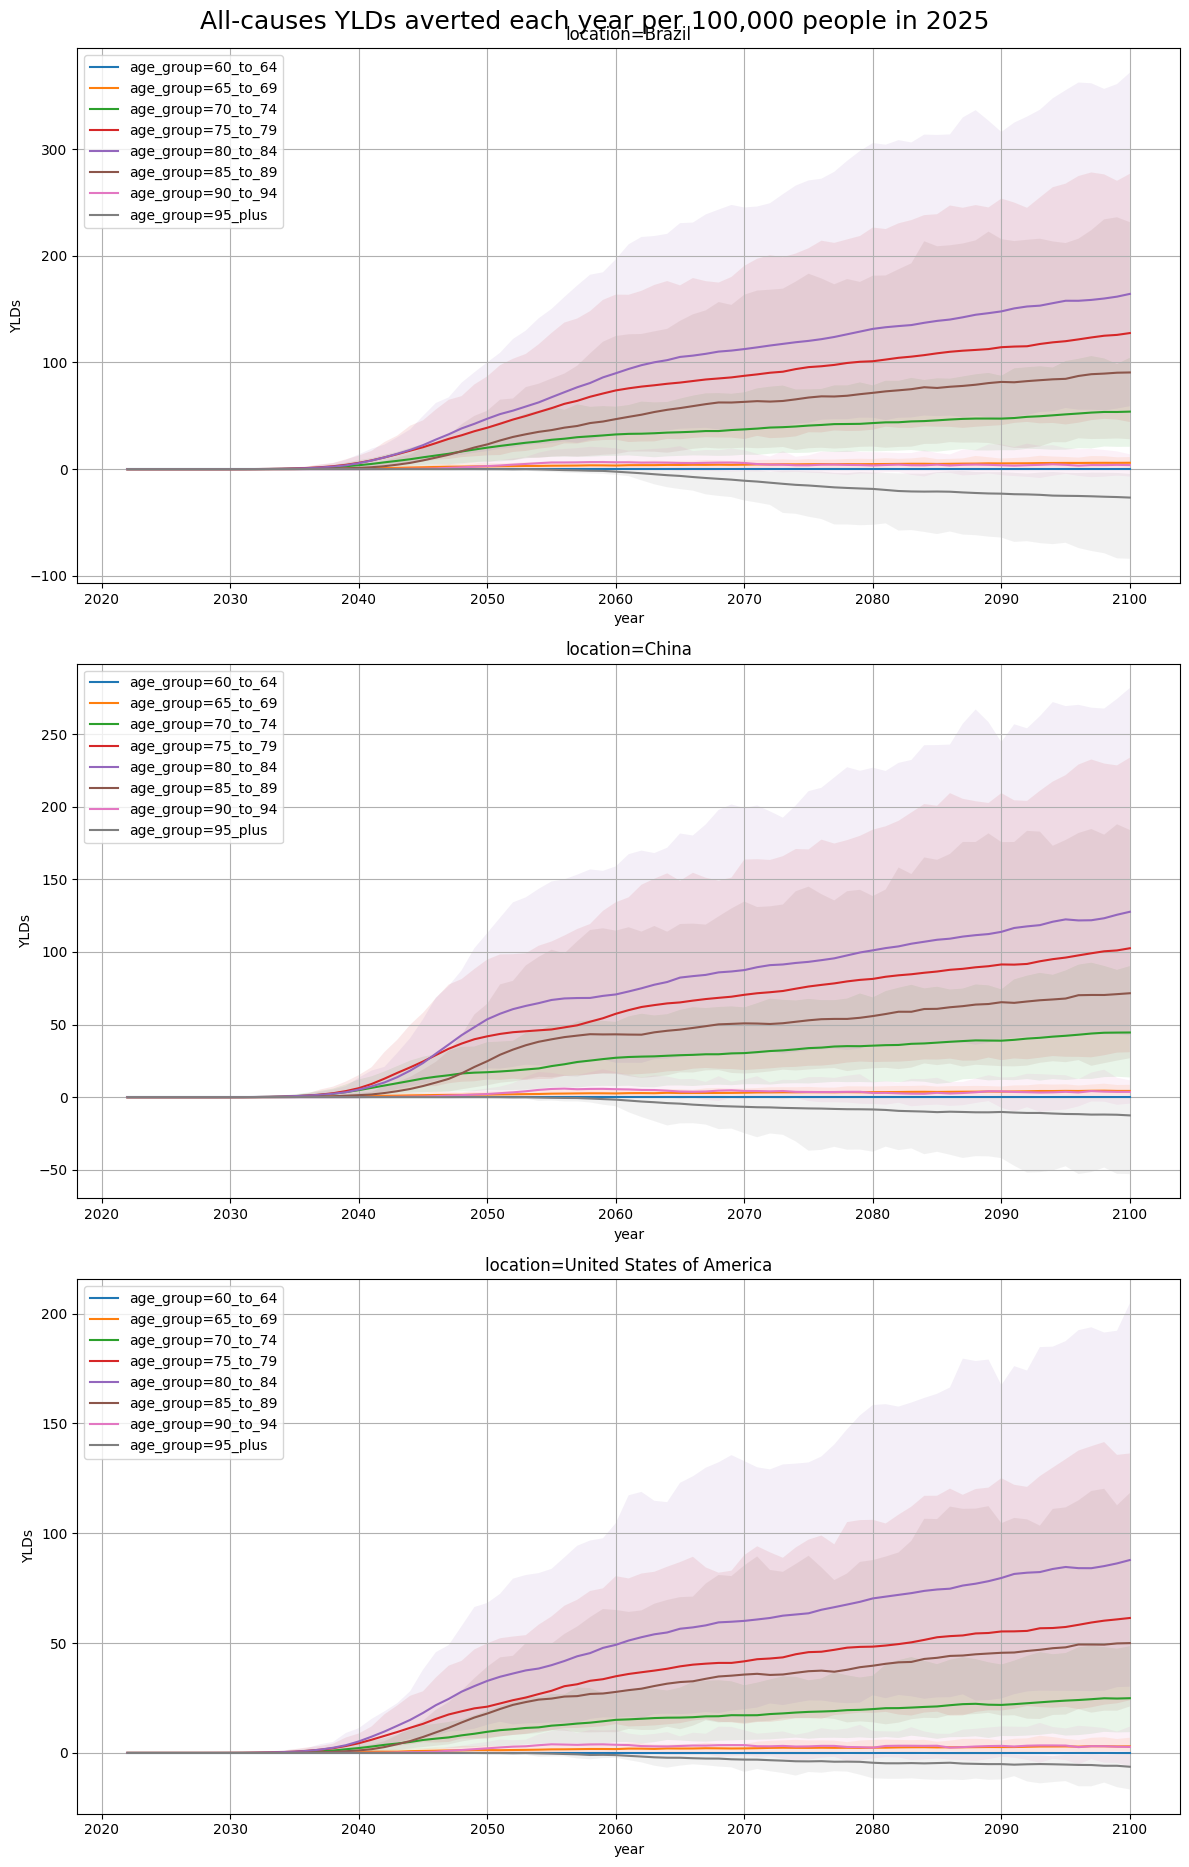

In [ ]:
# I'm not sure why total YLDs averted is greater than Alzheimer's YLDs
# averted...
fig = plot_over_time_by_column_for_row_x_1(
    averted_ylds
    .astype({"age_group": 'str'})
    .query(
        "age_group >= '60_to_64' and "
        "scenario == 'bbbm_testing_and_treatment' and entity == 'all_causes'"
        ),
    'age_group',
    'location',
    ylabel="YLDs",
    suptitle=f"All-causes YLDs averted each year per 100,000 people in 2025"
)
for ax in fig.axes:
    # ax.set_xticks(ax.get_xticks()[::10])
    ax.grid(True)
plt.show()

In [ ]:
# Print current time to easily check if notebook ran all the way through
# vs. hitting an error somewhere above
import datetime
print(datetime.datetime.now())

2026-02-05 17:42:53.318147
